# SR Reference Comparison (Standard vs GAA-Augmented vs GAA-Discovery)

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import spearmanr
import celltypist
from celltypist import models

/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


## Load SR conditions from the validated 6-way cache

In [2]:
IN_DIR = "/mnt/md0/jack-gaa/gaa/analysis/shared_6way_qc_unified/"
SR_CONDITIONS = ['SR_Std', 'SR_Aug', 'SR_Dis']

adatas = {}
for name in SR_CONDITIONS:
    adatas[name] = sc.read_h5ad(os.path.join(IN_DIR, f"{name}.h5ad"))
    print(f"Loaded {name}: {adatas[name].n_obs:,} cells x {adatas[name].n_vars:,} features")

for name in SR_CONDITIONS[1:]:
    assert all(adatas[SR_CONDITIONS[0]].obs_names == adatas[name].obs_names)
print(f"Confirmed identical, already-QC-passed barcodes: {adatas['SR_Std'].n_obs:,} cells")

qc_pass_barcodes = adatas['SR_Std'].obs_names.tolist()

adatas_raw = {name: adatas[name].copy() for name in SR_CONDITIONS}

Loaded SR_Std: 2,280 cells x 38,606 features
Loaded SR_Aug: 2,280 cells x 121,190 features
Loaded SR_Dis: 2,280 cells x 117,490 features
Confirmed identical, already-QC-passed barcodes: 2,280 cells


## Normalisation

In [3]:
for name in SR_CONDITIONS:
    adatas[name].layers['counts'] = adatas[name].X.copy()
    sc.pp.normalize_total(adatas[name], target_sum=1e4)
    sc.pp.log1p(adatas[name])
print("Normalised (normalize_total + log1p) all 3 SR conditions")

Normalised (normalize_total + log1p) all 3 SR conditions


## Clustering Std, Augmented, Discovery independently

In [4]:
def run_sr_clustering(adata, name):
    print(f"-> Processing {name}...")
    sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor='seurat')
    sc.tl.pca(adata, svd_solver='arpack', random_state=42)
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, random_state=42)
    sc.tl.umap(adata, random_state=42)
    sc.tl.leiden(adata, resolution=0.5, key_added='leiden', random_state=42)
    print(f"   Done. {name} generated {len(adata.obs['leiden'].unique())} clusters.")
    return adata

for name in SR_CONDITIONS:
    adatas[name] = run_sr_clustering(adatas[name], name)

-> Processing SR_Std...


/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Done. SR_Std generated 13 clusters.
-> Processing SR_Aug...
   Done. SR_Aug generated 12 clusters.
-> Processing SR_Dis...
   Done. SR_Dis generated 12 clusters.


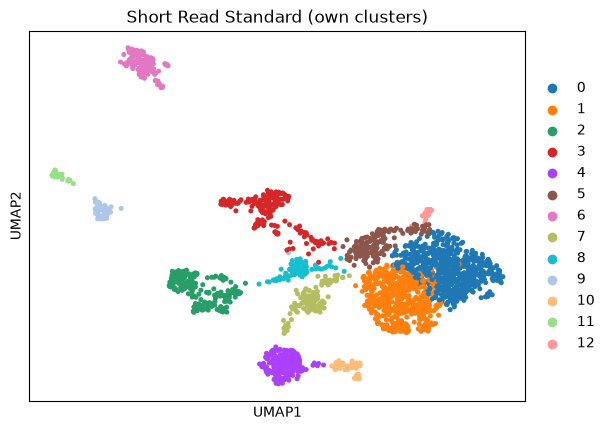

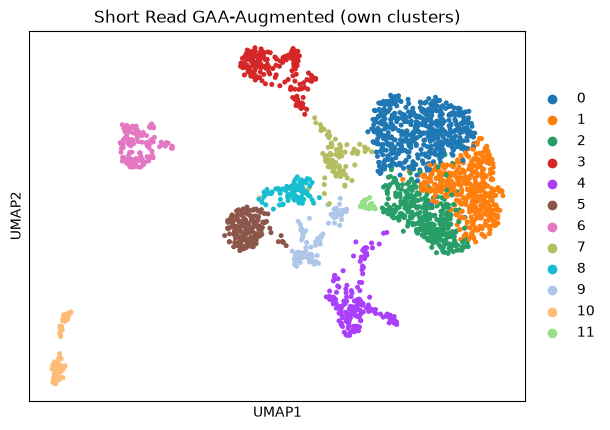

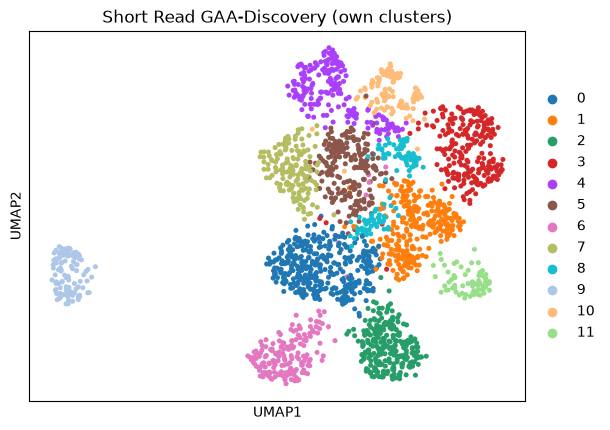

In [5]:
sc.pl.umap(adatas['SR_Std'], color='leiden', title='Short Read Standard (own clusters)')
sc.pl.umap(adatas['SR_Aug'], color='leiden', title='Short Read GAA-Augmented (own clusters)')
sc.pl.umap(adatas['SR_Dis'], color='leiden', title='Short Read GAA-Discovery (own clusters)')

## Peak-level feature isolation  Augmented vs Discovery

In [6]:
adata_sr_dis_peaks = adatas_raw['SR_Dis'][:, adatas_raw['SR_Dis'].var_names.str.contains('peak', case=False)].copy()
adata_sr_aug_peaks = adatas_raw['SR_Aug'][:, adatas_raw['SR_Aug'].var_names.str.contains('peak', case=False)].copy()

print(f"SR Discovery — full peak-level features:            {adata_sr_dis_peaks.n_vars:,}")
print(f"SR Augmented — peak-named (non-merged-class) only:  {adata_sr_aug_peaks.n_vars:,}")

SR Discovery — full peak-level features:            117,490
SR Augmented — peak-named (non-merged-class) only:  82,586


## Discovery gene-level collapse

In [7]:
COLLAPSE_CLASSES = {
    'known_exon', 'extended_exon', 'proximal_novel_exon',
    'known_transcript_intronic', 'known_gene_intronic',
}
KEEP_SEPARATE_CLASSES = {'antisense_exonic', 'antisense_intronic', 'intergenic'}


def parse_discovery_id(var_name):
    parts = var_name.split('|')
    if len(parts) < 3:
        return None, None, None
    context, classification, peak_id = parts[0], parts[1], '|'.join(parts[2:])
    return context, classification, peak_id


def build_gene_map(adata_dis):
    gene_map = {}
    for v in adata_dis.var_names:
        context, cls, peak_id = parse_discovery_id(v)
        if cls in COLLAPSE_CLASSES and context:
            gene_map[v] = context
    return gene_map


def collapse_discovery_to_gene_level(adata_dis, gene_map):
    var_names = list(adata_dis.var_names)
    targets = [gene_map.get(v, v) for v in var_names]
    target_genes = sorted(set(targets))
    gene_index = {g: i for i, g in enumerate(target_genes)}
    row_idx = [gene_index[t] for t in targets]
    col_idx = list(range(len(var_names)))
    data = np.ones(len(var_names))
    M = sp.csr_matrix((data, (row_idx, col_idx)), shape=(len(target_genes), len(var_names)))
    X_new = adata_dis.X @ M.T
    adata_gene = ad.AnnData(X=sp.csr_matrix(X_new), obs=adata_dis.obs.copy())
    adata_gene.var_names = target_genes
    return adata_gene


gene_map = build_gene_map(adatas_raw['SR_Dis'])
adata_sr_dis_genelevel = collapse_discovery_to_gene_level(adatas_raw['SR_Dis'], gene_map)
print(f"Collapsed {len(gene_map):,} peak features -> {adata_sr_dis_genelevel.n_vars:,} gene-level bins")

Collapsed 34,906 peak features -> 91,554 gene-level bins


## CellTypist annotation

📂 Storing models in /home/jack/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)
🔬 Input data has 2280 cells and 38606 genes
🔗 Matching reference genes in the model
🧬 5824 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 2280 cells and 121190 genes
🔗 Matching reference genes in the model
🧬 5824 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 2280 cells and 91554 genes
🔗 Matching reference genes in the

SR_Std: 10 cell types assigned
SR_Aug: 10 cell types assigned
SR_Dis: 4 cell types assigned


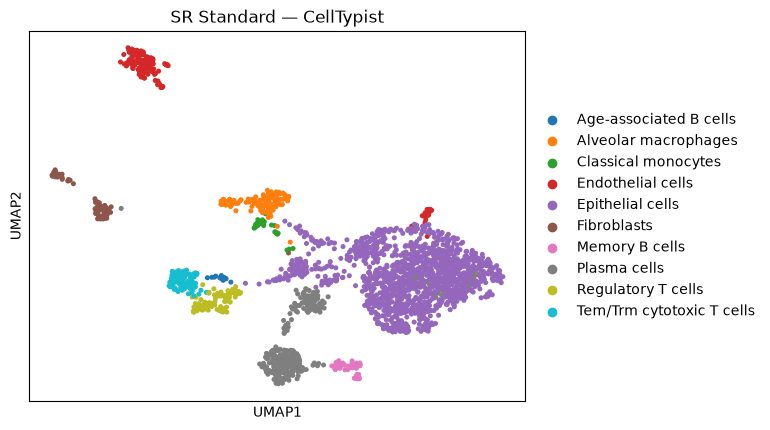

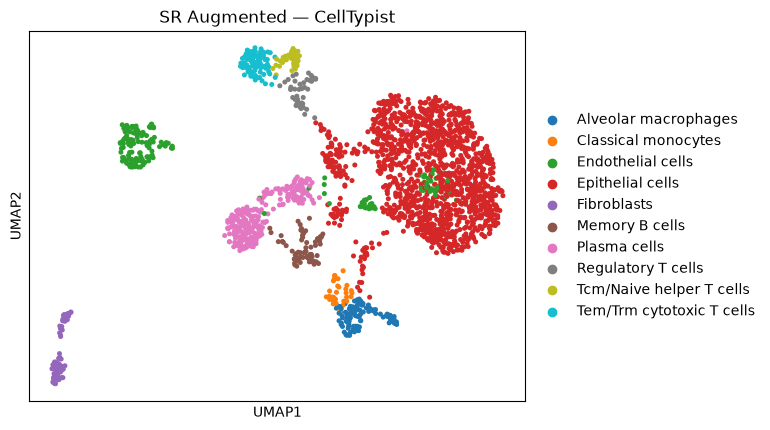

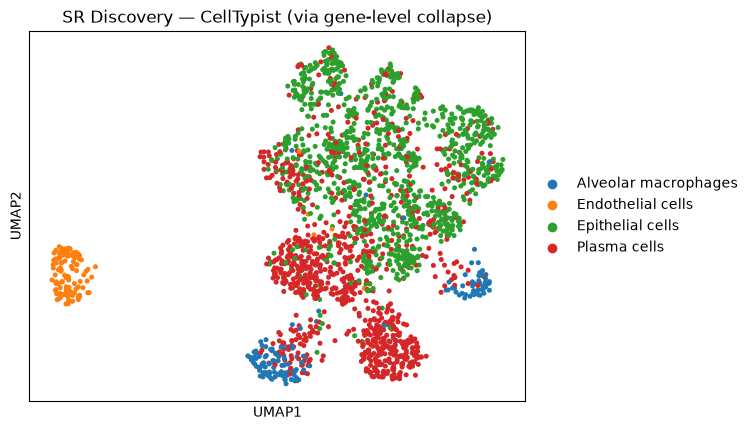

In [8]:
models.download_models(model=['Immune_All_Low.pkl'])

for name in ['SR_Std', 'SR_Aug']:
    predictions = celltypist.annotate(adatas[name], model='Immune_All_Low.pkl', majority_voting=True)
    adatas[name].obs['celltypist_label'] = predictions.predicted_labels['majority_voting'].values

adata_sr_dis_for_celltypist = adata_sr_dis_genelevel.copy()
sc.pp.normalize_total(adata_sr_dis_for_celltypist, target_sum=1e4)
sc.pp.log1p(adata_sr_dis_for_celltypist)
predictions_dis = celltypist.annotate(adata_sr_dis_for_celltypist, model='Immune_All_Low.pkl', majority_voting=True)
adatas['SR_Dis'].obs['celltypist_label'] = predictions_dis.predicted_labels['majority_voting'].values

for name in SR_CONDITIONS:
    print(f"{name}: {adatas[name].obs['celltypist_label'].nunique()} cell types assigned")

sc.pl.umap(adatas['SR_Std'], color='celltypist_label', title='SR Standard — CellTypist')
sc.pl.umap(adatas['SR_Aug'], color='celltypist_label', title='SR Augmented — CellTypist')
sc.pl.umap(adatas['SR_Dis'], color='celltypist_label', title='SR Discovery — CellTypist (via gene-level collapse)')

## Why might Discovery capture cell types less cleanly than Std/Aug

In [9]:
n_types_by_condition = {name: adatas[name].obs['celltypist_label'].nunique() for name in SR_CONDITIONS}
print("Distinct cell types called per condition:", n_types_by_condition)

# How concentrated is Discovery's calling into fewer/dominant types, compared to Std/Aug?
for name in SR_CONDITIONS:
    top_type_pct = 100 * adatas[name].obs['celltypist_label'].value_counts(normalize=True).iloc[0]
    print(f"{name}: largest single cell-type call accounts for {top_type_pct:.1f}% of cells")

Distinct cell types called per condition: {'SR_Std': 10, 'SR_Aug': 10, 'SR_Dis': 4}
SR_Std: largest single cell-type call accounts for 60.7% of cells
SR_Aug: largest single cell-type call accounts for 60.0% of cells
SR_Dis: largest single cell-type call accounts for 46.8% of cells


## Cluster agreement: Std vs Aug, Std vs Dis, Aug vs Dis

=== Cluster Agreement (ARI / NMI) ===
Std vs Aug: ARI=0.521  NMI=0.763
Std vs Dis: ARI=0.265  NMI=0.499
Aug vs Dis: ARI=0.261  NMI=0.492


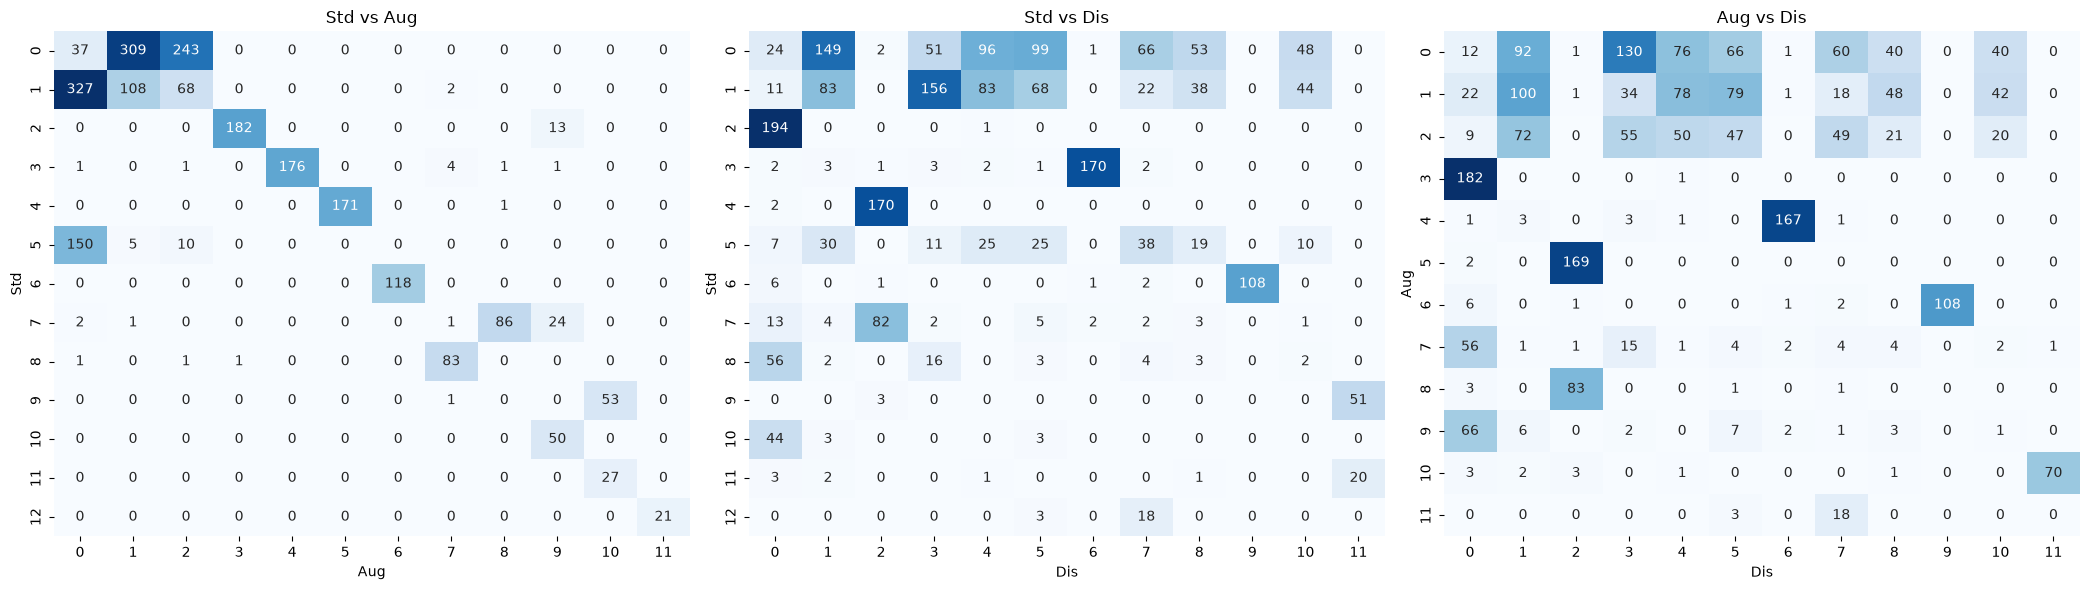


Look for any 1-to-many splits in the crosstabs above — candidates for the
cluster-split investigation function near the end of this notebook.


In [10]:
df_congruence = pd.DataFrame(index=qc_pass_barcodes)
df_congruence['Std'] = adatas['SR_Std'].obs['leiden']
df_congruence['Aug'] = adatas['SR_Aug'].obs['leiden']
df_congruence['Dis'] = adatas['SR_Dis'].obs['leiden']

pairs = [('Std', 'Aug'), ('Std', 'Dis'), ('Aug', 'Dis')]
congruence_results = {}

print("=== Cluster Agreement (ARI / NMI) ===")
for a, b in pairs:
    ari = adjusted_rand_score(df_congruence[a], df_congruence[b])
    nmi = normalized_mutual_info_score(df_congruence[a], df_congruence[b])
    congruence_results[(a, b)] = {'ari': ari, 'nmi': nmi}
    print(f"{a} vs {b}: ARI={ari:.3f}  NMI={nmi:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (a, b) in zip(axes, pairs):
    ct = pd.crosstab(df_congruence[a], df_congruence[b])
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{a} vs {b}')
    ax.set_xlabel(b)
    ax.set_ylabel(a)
plt.tight_layout()
plt.show()

print("\nLook for any 1-to-many splits in the crosstabs above — candidates for the")
print("cluster-split investigation function near the end of this notebook.")

## Std-based cluster labelling for Aug/Dis UMAPs

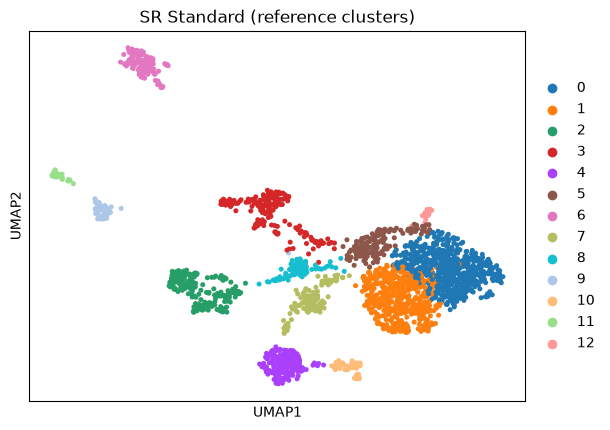

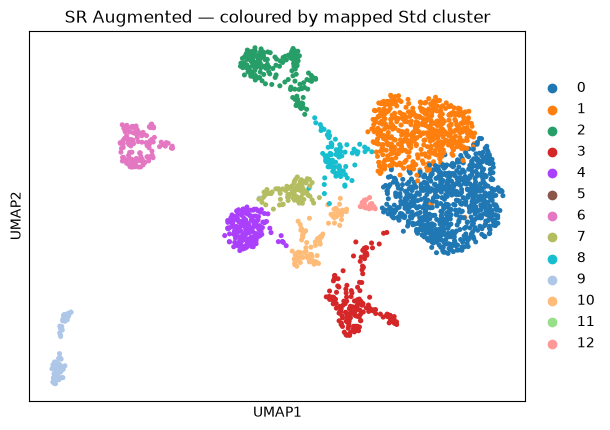

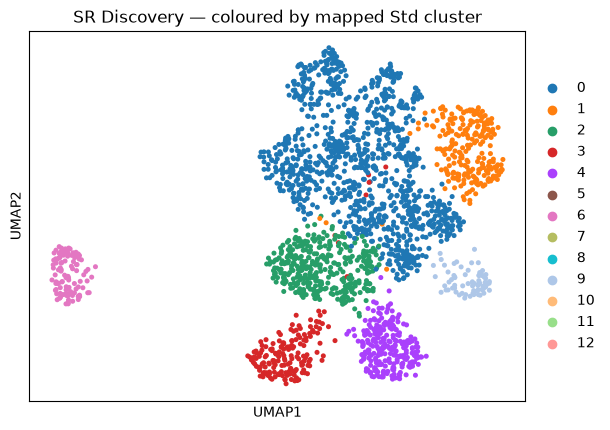

In [11]:
def transfer_labels_from_std(std_labels, other_labels):
    ct = pd.crosstab(other_labels, std_labels)
    return ct.idxmax(axis=1).to_dict()

aug_to_std_map = transfer_labels_from_std(df_congruence['Std'], df_congruence['Aug'])
dis_to_std_map = transfer_labels_from_std(df_congruence['Std'], df_congruence['Dis'])

adatas['SR_Aug'].obs['std_mapped_cluster'] = adatas['SR_Aug'].obs['leiden'].map(aug_to_std_map)
adatas['SR_Dis'].obs['std_mapped_cluster'] = adatas['SR_Dis'].obs['leiden'].map(dis_to_std_map)

shared_categories = sorted(df_congruence['Std'].astype(str).unique(), key=int)
adatas['SR_Std'].obs['leiden'] = pd.Categorical(adatas['SR_Std'].obs['leiden'].astype(str), categories=shared_categories)
adatas['SR_Aug'].obs['std_mapped_cluster'] = pd.Categorical(adatas['SR_Aug'].obs['std_mapped_cluster'].astype(str), categories=shared_categories)
adatas['SR_Dis'].obs['std_mapped_cluster'] = pd.Categorical(adatas['SR_Dis'].obs['std_mapped_cluster'].astype(str), categories=shared_categories)

sc.pl.umap(adatas['SR_Std'], color='leiden', title='SR Standard (reference clusters)')
sc.pl.umap(adatas['SR_Aug'], color='std_mapped_cluster', title='SR Augmented — coloured by mapped Std cluster')
sc.pl.umap(adatas['SR_Dis'], color='std_mapped_cluster', title='SR Discovery — coloured by mapped Std cluster')

## Sankey diagrams 


Std cluster -> dominant CellTypist label (n cells):
  0: Epithelial cells  (n=589)
  1: Epithelial cells  (n=505)
  2: Tem/Trm cytotoxic T cells  (n=195)
  3: Alveolar macrophages  (n=184)
  4: Plasma cells  (n=172)
  5: Epithelial cells  (n=165)
  6: Endothelial cells  (n=118)
  7: Plasma cells  (n=114)
  8: Epithelial cells  (n=86)
  9: Fibroblasts  (n=54)
  10: Memory B cells  (n=50)
  11: Fibroblasts  (n=27)
  12: Endothelial cells  (n=21)

Aug cluster -> dominant CellTypist label (n cells):
  0: Epithelial cells  (n=518)
  1: Epithelial cells  (n=423)
  2: Epithelial cells  (n=323)
  3: Tem/Trm cytotoxic T cells  (n=183)
  4: Alveolar macrophages  (n=176)
  5: Plasma cells  (n=171)
  6: Endothelial cells  (n=118)
  7: Epithelial cells  (n=91)
  8: Plasma cells  (n=88)
  9: Memory B cells  (n=88)
  10: Fibroblasts  (n=80)
  11: Endothelial cells  (n=21)

Dis cluster -> dominant CellTypist label (n cells):
  0: Plasma cells  (n=362)
  1: Epithelial cells  (n=276)
  2: Plasma cells  

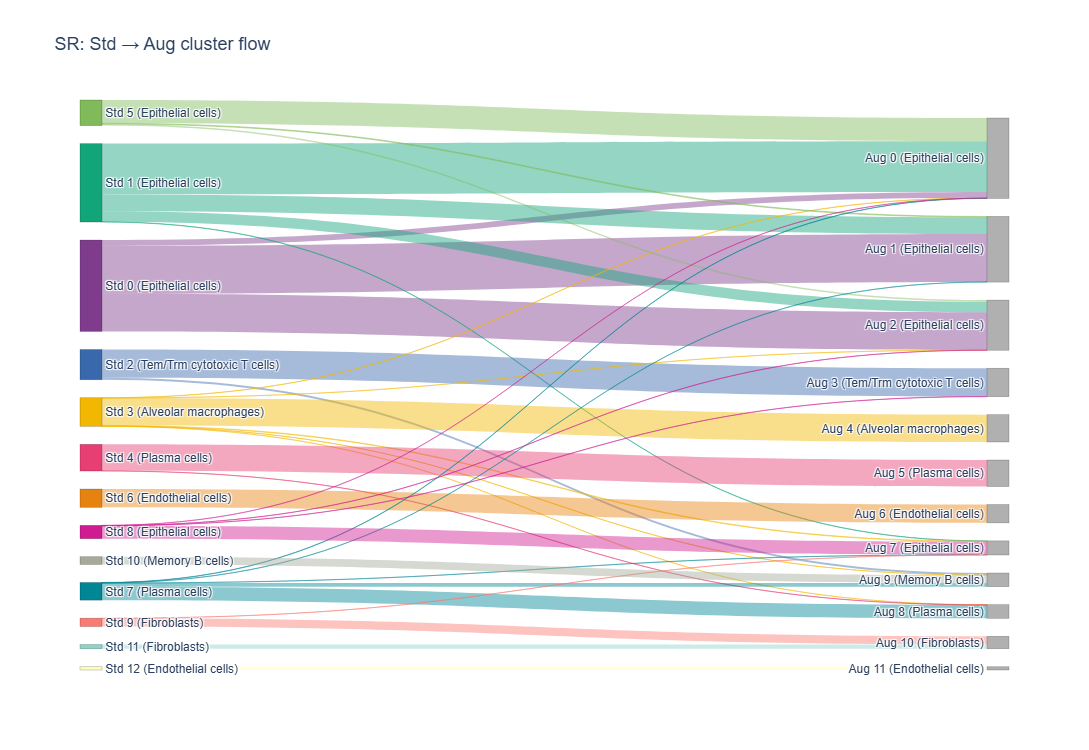

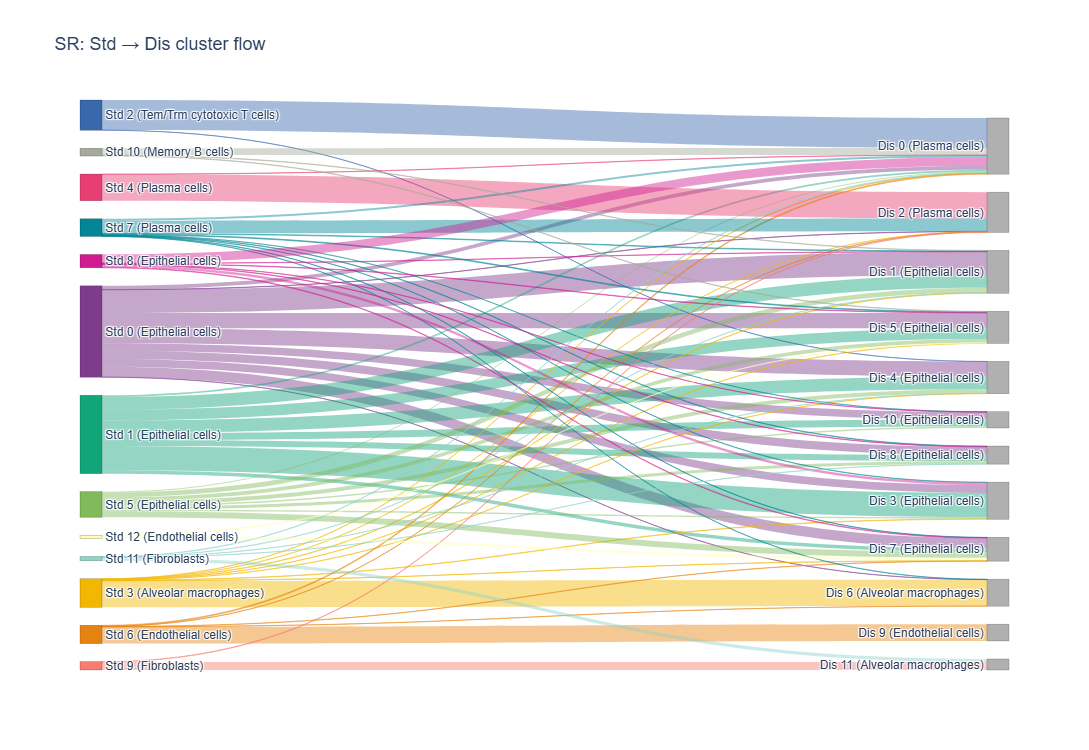

In [12]:
def dominant_celltype_per_cluster(adata, groupby='leiden'):
    return adata.obs.groupby(groupby)['celltypist_label'].agg(lambda x: x.value_counts().idxmax())

def cluster_sizes(adata, groupby='leiden'):
    return adata.obs[groupby].value_counts()

std_celltype_map = dominant_celltype_per_cluster(adatas['SR_Std']).to_dict()
aug_celltype_map = dominant_celltype_per_cluster(adatas['SR_Aug']).to_dict()
dis_celltype_map = dominant_celltype_per_cluster(adatas['SR_Dis']).to_dict()

std_sizes = cluster_sizes(adatas['SR_Std'])
aug_sizes = cluster_sizes(adatas['SR_Aug'])
dis_sizes = cluster_sizes(adatas['SR_Dis'])

print("Std cluster -> dominant CellTypist label (n cells):")
for cl, ct in std_celltype_map.items():
    print(f"  {cl}: {ct}  (n={std_sizes.get(cl, 0)})")

print("\nAug cluster -> dominant CellTypist label (n cells):")
for cl, ct in aug_celltype_map.items():
    print(f"  {cl}: {ct}  (n={aug_sizes.get(cl, 0)})")

print("\nDis cluster -> dominant CellTypist label (n cells):")
for cl, ct in dis_celltype_map.items():
    print(f"  {cl}: {ct}  (n={dis_sizes.get(cl, 0)})")


def build_sankey(labels_a, labels_b, name_a, name_b, title, celltype_map_a=None, celltype_map_b=None):
    df = pd.DataFrame({name_a: labels_a, name_b: labels_b})
    flow = df.groupby([name_a, name_b]).size().reset_index(name='count')

    a_clusters = sorted(df[name_a].unique(), key=lambda x: int(x))
    b_clusters = sorted(df[name_b].unique(), key=lambda x: int(x))

    if celltype_map_a:
        a_labels = [f"{name_a} {c} ({celltype_map_a.get(c, '?')})" for c in a_clusters]
    else:
        a_labels = [f"{name_a} {c}" for c in a_clusters]
    if celltype_map_b:
        b_labels = [f"{name_b} {c} ({celltype_map_b.get(c, '?')})" for c in b_clusters]
    else:
        b_labels = [f"{name_b} {c}" for c in b_clusters]
    all_labels = a_labels + b_labels

    a_idx = {c: i for i, c in enumerate(a_clusters)}
    b_idx = {c: i + len(a_clusters) for i, c in enumerate(b_clusters)}

    palette = px.colors.qualitative.Bold + px.colors.qualitative.Set3 + px.colors.qualitative.Pastel
    node_colors = [palette[i % len(palette)] for i in range(len(a_clusters))] + ['#B0B0B0'] * len(b_clusters)

    def hex_to_rgba(hex_color, alpha=0.45):
        h = hex_color.lstrip('#')
        if len(h) == 6:
            r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        else:
            nums = hex_color.strip('rgb()').split(',')
            r, g, b = [int(float(n)) for n in nums[:3]]
        return f'rgba({r},{g},{b},{alpha})'

    sources, targets, values, link_colors = [], [], [], []
    for _, row in flow.iterrows():
        src = a_idx[row[name_a]]
        sources.append(src)
        targets.append(b_idx[row[name_b]])
        values.append(row['count'])
        link_colors.append(hex_to_rgba(node_colors[src]))

    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(pad=18, thickness=22, line=dict(color="rgba(0,0,0,0.3)", width=0.6),
                  label=all_labels, color=node_colors),
        link=dict(source=sources, target=targets, value=values, color=link_colors),
    )])
    fig.update_layout(title=dict(text=title, font=dict(size=18)), font=dict(size=12, family="Arial"),
                       height=750, width=950, paper_bgcolor='white', plot_bgcolor='white')
    return fig


out_dir = '/mnt/md0/jack-gaa/gaa/analysis/sankeys'
os.makedirs(out_dir, exist_ok=True)

fig1 = build_sankey(df_congruence['Std'], df_congruence['Aug'], 'Std', 'Aug', 'SR: Std → Aug cluster flow',
                     celltype_map_a=std_celltype_map, celltype_map_b=aug_celltype_map)
fig1.write_html(f'{out_dir}/sr_sankey_std_vs_aug.html')
fig1.show()

fig2 = build_sankey(df_congruence['Std'], df_congruence['Dis'], 'Std', 'Dis', 'SR: Std → Dis cluster flow',
                     celltype_map_a=std_celltype_map, celltype_map_b=dis_celltype_map)
fig2.write_html(f'{out_dir}/sr_sankey_std_vs_dis.html')
fig2.show()

## Gene-level agreement: Augmented vs collapsed-Discovery

91,554 shared gene bins — Spearman ρ=0.710


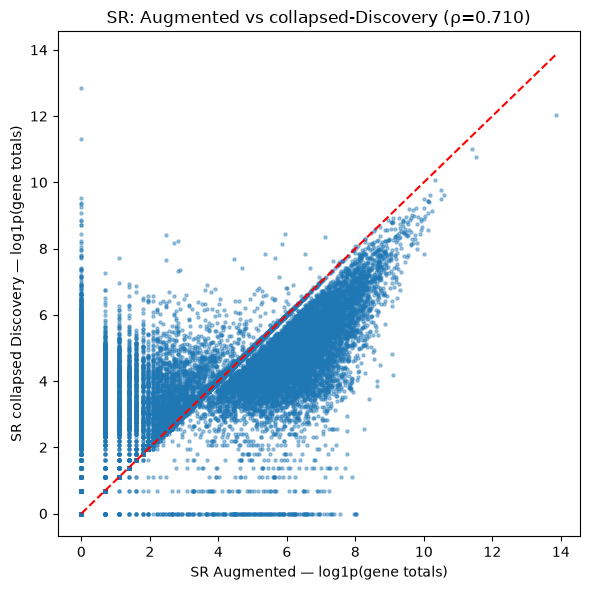

In [13]:
shared_genes = sorted(set(adatas_raw['SR_Aug'].var_names) & set(adata_sr_dis_genelevel.var_names))
aug_totals = np.asarray(adatas_raw['SR_Aug'][:, shared_genes].X.sum(axis=0)).ravel()
dis_totals = np.asarray(adata_sr_dis_genelevel[:, shared_genes].X.sum(axis=0)).ravel()

rho, _ = spearmanr(aug_totals, dis_totals)
print(f"{len(shared_genes):,} shared gene bins — Spearman ρ={rho:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(np.log1p(aug_totals), np.log1p(dis_totals), s=5, alpha=0.4)
lims = [0, max(np.log1p(aug_totals).max(), np.log1p(dis_totals).max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('SR Augmented — log1p(gene totals)')
plt.ylabel('SR collapsed Discovery — log1p(gene totals)')
plt.title(f'SR: Augmented vs collapsed-Discovery (ρ={rho:.3f})')
plt.tight_layout()
plt.show()

## Genome-wide Std vs Aug vs Dis gene correlation

std vs aug: Spearman ρ=0.998
std vs dis: Spearman ρ=0.724
aug vs dis: Spearman ρ=0.727


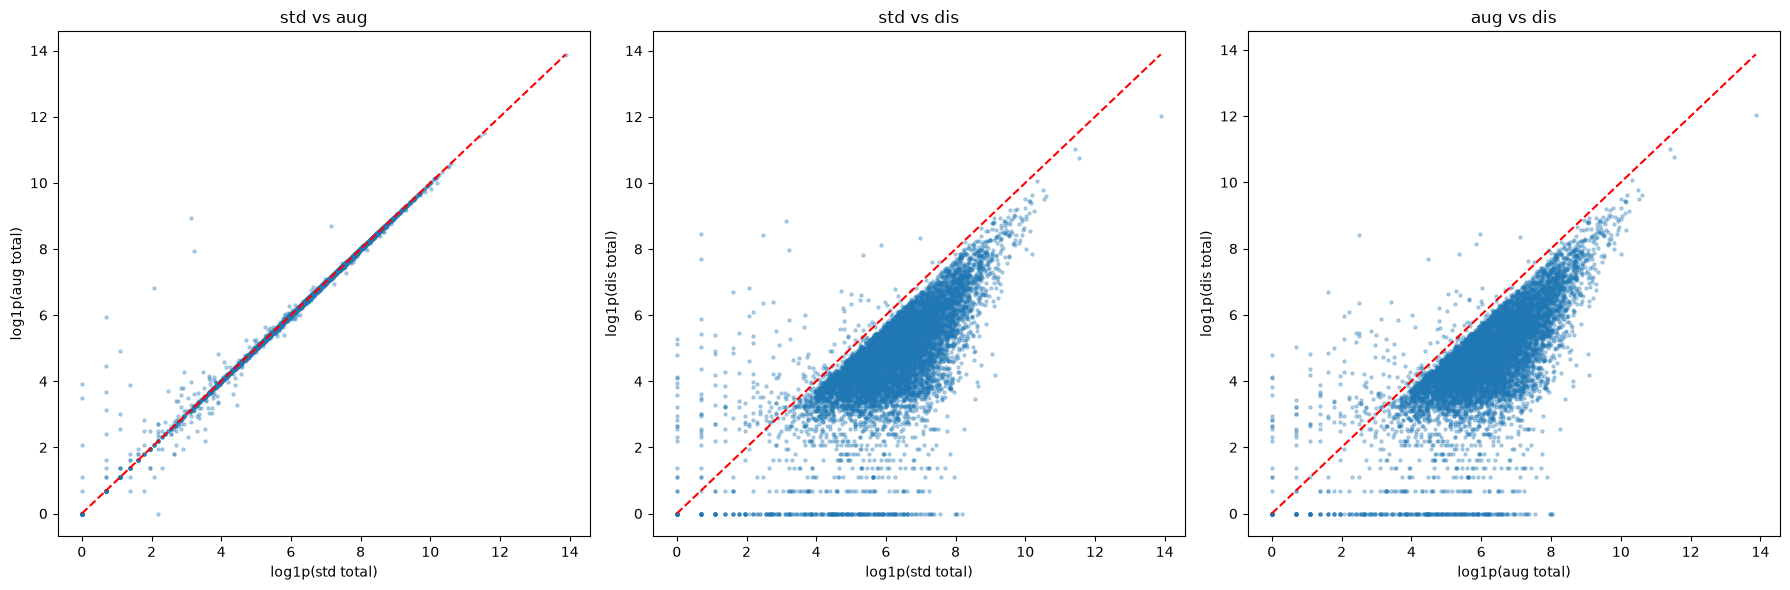

In [14]:
shared_genes_3way = sorted(set(adatas_raw['SR_Std'].var_names) & set(adata_sr_dis_genelevel.var_names) & set(adatas_raw['SR_Aug'].var_names))

std_totals_3way = np.asarray(adatas_raw['SR_Std'][:, shared_genes_3way].X.sum(axis=0)).ravel()
aug_totals_3way = np.asarray(adatas_raw['SR_Aug'][:, shared_genes_3way].X.sum(axis=0)).ravel()
dis_totals_3way = np.asarray(adata_sr_dis_genelevel[:, shared_genes_3way].X.sum(axis=0)).ravel()

three_way_df = pd.DataFrame({'gene': shared_genes_3way, 'std': std_totals_3way, 'aug': aug_totals_3way, 'dis': dis_totals_3way})

pairs_3way = [('std', 'aug'), ('std', 'dis'), ('aug', 'dis')]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (a, b) in zip(axes, pairs_3way):
    rho_3way, _ = spearmanr(three_way_df[a], three_way_df[b])
    print(f"{a} vs {b}: Spearman ρ={rho_3way:.3f}")
    ax.scatter(np.log1p(three_way_df[a]), np.log1p(three_way_df[b]), s=5, alpha=0.3)
    lims = [0, max(np.log1p(three_way_df[a]).max(), np.log1p(three_way_df[b]).max())]
    ax.plot(lims, lims, 'r--')
    ax.set_xlabel(f'log1p({a} total)')
    ax.set_ylabel(f'log1p({b} total)')
    ax.set_title(f'{a} vs {b}')
plt.tight_layout()
plt.show()

## DIS-native standalone clustering on the validated gene-level collapse

DIS-native clusters: 7
DIS-native vs Std: ARI=0.358  NMI=0.607
DIS-native vs Aug: ARI=0.460  NMI=0.669
(for reference — raw DIS-peaks-only vs Aug, from the main clustering: ARI=0.261  NMI=0.492)


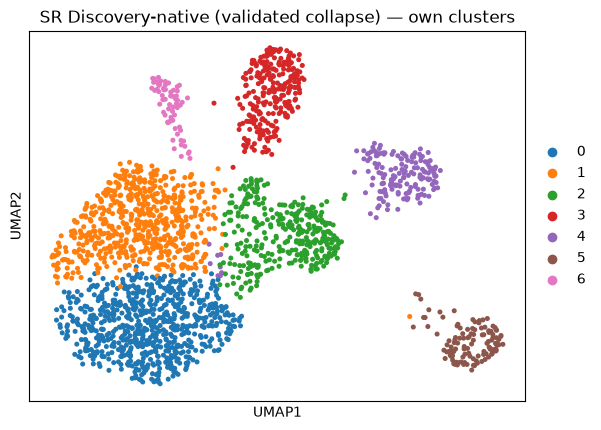

In [15]:
adata_sr_dis_native = adata_sr_dis_genelevel.copy()
adata_sr_dis_native.layers['counts'] = adata_sr_dis_native.X.copy()
sc.pp.normalize_total(adata_sr_dis_native, target_sum=1e4)
sc.pp.log1p(adata_sr_dis_native)
sc.pp.highly_variable_genes(adata_sr_dis_native, n_top_genes=3000, flavor='seurat')
sc.tl.pca(adata_sr_dis_native, svd_solver='arpack', random_state=42)
sc.pp.neighbors(adata_sr_dis_native, n_neighbors=15, n_pcs=30, random_state=42)
sc.tl.umap(adata_sr_dis_native, random_state=42)
sc.tl.leiden(adata_sr_dis_native, resolution=0.5, key_added='leiden', random_state=42)
print(f"DIS-native clusters: {adata_sr_dis_native.obs['leiden'].nunique()}")

ari_native_std = adjusted_rand_score(adata_sr_dis_native.obs['leiden'].values, df_congruence['Std'].values)
ari_native_aug = adjusted_rand_score(adata_sr_dis_native.obs['leiden'].values, df_congruence['Aug'].values)
nmi_native_std = normalized_mutual_info_score(adata_sr_dis_native.obs['leiden'].values, df_congruence['Std'].values)
nmi_native_aug = normalized_mutual_info_score(adata_sr_dis_native.obs['leiden'].values, df_congruence['Aug'].values)

print(f"DIS-native vs Std: ARI={ari_native_std:.3f}  NMI={nmi_native_std:.3f}")
print(f"DIS-native vs Aug: ARI={ari_native_aug:.3f}  NMI={nmi_native_aug:.3f}")
print(f"(for reference — raw DIS-peaks-only vs Aug, from the main clustering: "
      f"ARI={congruence_results[('Aug','Dis')]['ari']:.3f}  NMI={congruence_results[('Aug','Dis')]['nmi']:.3f})")

sc.pl.umap(adata_sr_dis_native, color='leiden', title='SR Discovery-native (validated collapse) — own clusters')

## Marker genes top 15 per cluster, with Wilcoxon scores

In [16]:
for name in SR_CONDITIONS:
    sc.tl.rank_genes_groups(adatas[name], groupby='leiden', method='wilcoxon', key_added='rank_genes_groups')
    sc.tl.rank_genes_groups(adatas[name], groupby='celltypist_label', method='wilcoxon', key_added='rank_genes_groups_celltypist')

def top_n_markers_table(adata, n=15, key='rank_genes_groups'):
    groups = list(adata.uns[key]['names'].dtype.names)
    data = {}
    for g in groups:
        names = adata.uns[key]['names'][g][:n]
        scores = adata.uns[key]['scores'][g][:n]
        data[g] = [f'{nm} ({sc_:.1f})' for nm, sc_ in zip(names, scores)]
    df = pd.DataFrame(data)
    df.index = [f'rank_{i+1}' for i in range(n)]
    return df

for name in SR_CONDITIONS:
    print(f"\n=== {name}: top 15 markers per Leiden cluster (Wilcoxon score) ===")
    display(top_n_markers_table(adatas[name], n=15, key='rank_genes_groups'))
    print(f"\n=== {name}: top 15 markers per CELL TYPE (Wilcoxon score) ===")
    display(top_n_markers_table(adatas[name], n=15, key='rank_genes_groups_celltypist'))


=== SR_Std: top 15 markers per Leiden cluster (Wilcoxon score) ===


,0,1,2,3,4,5,6,7,8,9,10,11,12
rank_1,ANK2 (19.1),AUTS2 (22.8),SKAP1 (20.5),SAT1 (20.5),ST6GAL1 (20.0),KAZN (17.3),INSR (18.3),FCRL5 (11.8),PRKCH (11.3),DLC1 (12.5),ARHGAP24 (11.9),ZFPM2 (8.4),BRINP3 (7.9)
rank_2,NIHCOLE (18.8),TENM3 (21.9),PRKCH (20.5),ZEB2 (19.5),FBXW7 (19.9),CNTN1 (16.0),FLT1 (18.1),ST6GAL1 (9.8),TOX (9.7),CCDC102B (12.5),RALGPS2 (11.3),RUNX1T1 (8.2),PCDH9 (7.8)
rank_3,C4orf47 (18.4),KCNIP4 (21.6),FYN (20.5),SRGN (18.8),ANKRD36BP2 (19.7),ENSG00000231606 (16.0),LDB2 (17.9),FUT8 (9.6),FYN (9.5),LHFPL6 (12.5),AFF3 (10.8),COL1A2 (8.2),LINC02045 (7.6)
rank_4,ENSG00000287360 (18.3),MTCP1 (21.5),PTPRC (20.4),DOCK4 (18.6),IGKC (19.5),KAZN-AS1 (15.2),SPRY1 (17.8),RALGPS2 (9.5),SKAP1 (9.5),COL4A2 (12.4),ADAM28 (10.4),BNC2 (8.1),LRFN5 (7.6)
rank_5,ENSG00000253553 (18.3),RMST (21.2),ARHGAP15 (18.9),SLC8A1 (18.3),IGHG1 (19.5),ROBO2 (15.0),FBXL7 (17.8),ANKRD36BP2 (9.5),LINC01934 (9.3),HTR1F (12.3),RIPOR2 (10.4),LAMA2 (7.9),ENSG00000285798 (7.5)
rank_6,ENSG00000253496 (18.1),COL23A1 (21.1),B2M (18.1),DMXL2 (17.9),FNDC3A (19.1),LINC02476 (15.0),GRB10 (17.5),IFNG-AS1 (9.4),PTPRC (8.8),PRKG1 (12.1),PRKCB (9.8),IGFBP7 (7.9),ENSG00000254202 (7.5)
rank_7,NEBL (18.0),SORBS1 (20.9),CELF2 (17.7),QKI (17.8),IFNG-AS1 (18.7),PTH2R (14.0),TCF4 (17.4),FBXW7 (9.3),SLFN12L (8.6),PDGFRB (12.0),ARHGAP15 (9.8),DLC1 (7.8),UNC13C (7.3)
rank_8,ENSG00000251600 (17.7),SEMA3E (20.7),MBNL1 (17.4),CTSB (17.7),IGHG3 (18.7),PRKG1 (14.0),ADGRL4 (17.4),SEL1L3 (9.2),RIPOR2 (8.4),MYO1B (12.0),WDFY4 (9.5),TSHZ2 (7.7),COL6A6 (7.1)
rank_9,RUFY3 (17.4),SLC4A4 (20.6),TOX (17.2),FRMD4B (17.7),ELL2 (18.5),NALCN (13.1),EGFL7 (17.4),IGHG3 (9.1),CD96 (8.4),EBF1 (12.0),MARCHF1 (9.5),CACNA1C (7.5),ARPP21 (7.1)
rank_10,LINC00355 (17.4),CDH10 (20.5),ANKRD44 (16.4),AOAH (17.6),ERN1 (17.7),LINC03077 (12.9),SPARCL1 (17.3),XBP1 (8.9),THEMIS (8.3),CALD1 (11.9),ANKRD44 (9.3),CDH11 (7.2),PRKG1 (6.9)



=== SR_Std: top 15 markers per CELL TYPE (Wilcoxon score) ===


,Age-associated B cells,Alveolar macrophages,Classical monocytes,Endothelial cells,Epithelial cells,Fibroblasts,Memory B cells,Plasma cells,Regulatory T cells,Tem/Trm cytotoxic T cells
rank_1,IKZF3 (5.4),SAT1 (17.7),ETV6 (8.0),PLPP1 (16.7),KCNIP4 (35.0),DLC1 (14.8),ARHGAP24 (11.9),ANKRD36BP2 (22.4),PTPRC (13.5),PRKCH (15.5)
rank_2,ANKRD44 (5.3),ZEB2 (16.7),SRGN (7.7),ARL15 (16.6),TENM3 (34.3),IGFBP7 (14.3),RALGPS2 (11.3),FBXW7 (21.8),SKAP1 (13.3),TOX (15.0)
rank_3,PPP1R16B (5.3),DOCK4 (16.6),DOCK10 (7.3),FLT1 (16.5),PCSK6 (34.2),LHFPL6 (14.0),AFF3 (10.8),ST6GAL1 (21.6),FYN (13.2),FYN (14.3)
rank_4,SP110 (5.3),FMNL2 (16.4),DOCK2 (7.2),PLPP3 (16.5),LRRC7 (34.1),CACNA1C (13.8),ADAM28 (10.4),IGHG1 (21.1),ARHGAP15 (13.0),SKAP1 (13.9)
rank_5,ARHGAP24 (5.3),DMXL2 (16.3),AKAP13 (7.0),INSR (16.4),ENSG00000229618 (34.1),CALD1 (13.6),RIPOR2 (10.4),IFNG-AS1 (21.0),MBNL1 (12.7),PTPRC (13.8)
rank_6,SKAP1 (5.3),FRMD4B (16.3),HLA-DRA (6.8),SPRY1 (16.4),NLGN1 (33.9),COL4A1 (13.4),PRKCB (9.8),IGHG3 (20.4),B2M (12.3),DOCK8 (12.8)
rank_7,ARHGAP15 (5.2),PSAP (15.6),LYN (6.8),LDB2 (16.4),DNAH11 (33.8),COL4A2 (13.1),ARHGAP15 (9.8),FNDC3A (20.2),PRKCH (12.0),HLA-B (12.4)
rank_8,CELF2 (5.1),QKI (15.6),LDLRAD4 (6.8),ADAMTS9 (16.3),ENSG00000284418 (33.8),ZFPM2 (13.1),WDFY4 (9.5),IGKC (20.1),FYB1 (12.0),CELF2 (12.3)
rank_9,IKZF1 (5.1),ATG7 (15.4),GNAQ (6.7),MAGI1 (16.3),NIHCOLE (33.7),COL5A2 (13.0),MARCHF1 (9.5),FCRL5 (20.0),RIPOR2 (12.0),CBLB (12.2)
rank_10,AFF3 (5.0),TFEC (15.4),CD74 (6.5),CALCRL (16.2),MIR548XHG (33.5),EBF1 (12.8),ANKRD44 (9.3),XBP1 (19.9),ANKRD44 (11.3),CD96 (12.2)



=== SR_Aug: top 15 markers per Leiden cluster (Wilcoxon score) ===


...

,Alveolar macrophages,Classical monocytes,Endothelial cells,Epithelial cells,Fibroblasts,Memory B cells,Plasma cells,Regulatory T cells,Tcm/Naive helper T cells,Tem/Trm cytotoxic T cells
rank_1,SAT1 (17.0),SRGN (9.0),PLPP3 (15.9),KCNIP4 (34.7),DLC1 (14.7),ARHGAP24 (14.0),ANKRD36BP2 (23.0),PTPRC (10.2),MBNL1 (9.5),PRKCH (15.2)
rank_2,ZEB2 (16.1),HLA-DRA (8.8),MAGI1 (15.5),TENM3 (33.8),IGFBP7 (14.3),RALGPS2 (13.0),ST6GAL1 (22.4),FYN (10.1),SKAP1 (9.4),TOX (15.2)
rank_3,DOCK4 (15.8),CD74 (8.7),LDB2 (15.1),ENSG00000229618 (33.6),LHFPL6 (13.9),AFF3 (13.0),FBXW7 (22.0),B2M (9.8),THEMIS (9.3),FYN (14.0)
rank_4,DMXL2 (15.8),ETV6 (8.6),ARHGAP29 (15.1),LRRC7 (33.4),CACNA1C (13.7),RIPOR2 (12.5),IGHG1 (21.7),SKAP1 (9.8),PTPRC (9.3),SKAP1 (13.7)
rank_5,FRMD4B (15.7),SLC8A1 (8.4),INSR (14.9),VEGFA (33.3),CALD1 (13.4),ARHGAP15 (11.9),IFNG-AS1 (21.6),PHACTR2 (9.7),PRKCH (9.1),PTPRC (13.2)
rank_6,FMNL2 (15.6),LYN (8.3),PTPRK (14.9),NIHCOLE (33.2),COL4A1 (13.3),ADAM28 (11.7),IGHG3 (20.9),ARHGAP15 (9.4),ARHGAP15 (9.1),DOCK8 (12.9)
rank_7,ATG7 (14.9),RAB31 (8.2),ADAMTS9 (14.9),PCSK6 (33.2),COL4A2 (13.1),ANKRD44 (11.7),XBP1 (20.9),MAP3K5 (9.3),FYN (9.0),HLA-B (12.8)
rank_8,PSAP (14.7),DOCK10 (8.2),ADGRL4 (14.8),SLIT2 (33.2),ZFPM2 (13.0),PRKCB (11.4),FNDC3A (20.8),MBNL1 (8.9),ETS1 (8.8),CBLB (12.4)
rank_9,QKI (14.7),SAT1 (8.2),PLPP1 (14.6),NLGN1 (33.0),COL5A2 (12.9),WDFY4 (11.1),IGKC (20.8),RIPOR2 (8.9),RIPOR2 (8.6),CELF2 (12.1)
rank_10,SRGN (14.5),DOCK2 (8.0),TANC1 (14.6),MTCP1 (32.9),EBF1 (12.8),TCF4 (11.0),ELL2 (20.5),CELF2 (8.7),FYB1 (8.4),ARHGAP15 (11.8)



=== SR_Dis: top 15 markers per Leiden cluster (Wilcoxon score) ===


,0,1,2,3,4,5,6,7,8,9,10,11
rank_1,IGKC|known_exon|peak_87935 (17.5),NDRG1|known_transcript_intronic|peak_113762 (8.0),IGKC|known_exon|peak_87935 (21.0),near:ENSG00000289447:8952bp|intergenic|peak_10...,VEGFA|known_exon|peak_46612 (8.6),RHEX|known_transcript_intronic|peak_4573 (20.9),SAT1|known_exon|peak_56714 (19.8),MYOCOS|known_transcript_intronic|peak_3862 (20.1),IGLC3|known_exon|peak_33964 (8.8),EGFL7|known_exon|peak_56350 (16.4),IGLL5|known_exon|peak_33962 (6.6),PDGFRB|known_exon|peak_104856 (11.3)
rank_2,B2M|known_exon|peak_18048 (16.6),NEAT1|known_exon|peak_9909 (7.8),IGHG3|known_exon|peak_76672 (20.6),near:ENSG00000289447:5416bp|intergenic|peak_46...,NEAT1|known_exon|peak_9923 (7.1),ENSG00000287733|known_exon|peak_50850 (8.0),SAT1|antisense_exonic|peak_115968 (16.5),MYOCOS|known_transcript_intronic|peak_3863 (19.3),VEGFA|known_exon|peak_46612 (6.8),SPRY1|known_exon|peak_40971 (16.0),HMGN3|known_exon|peak_106353 (5.4),VMP1|antisense_exonic|peak_82320 (10.3)
rank_3,IGLC3|known_exon|peak_33964 (14.0),ENSG00000287733|known_exon|peak_50850 (7.3),IGHG4|known_exon|peak_76658 (19.0),near:ENSG00000229370:5472bp|intergenic|peak_86...,NEAT1|known_exon|peak_9901 (7.0),HILPDA|known_exon|peak_50518 (7.6),SAT1|known_exon|peak_56716 (16.5),UBE2D2|known_transcript_intronic|peak_44947 (1...,NDRG1|antisense_intronic|peak_54330 (5.9),MCPH1|antisense_intronic|peak_111118 (13.4),BACE2|known_transcript_intronic|peak_33503 (5.1),GEM|known_transcript_intronic|peak_112519 (7.3)
rank_4,HLA-B|known_exon|peak_105813 (13.9),NEAT1|known_exon|peak_9920 (7.0),XBP1|known_exon|peak_93592 (16.9),near:ENSG00000229370:5901bp|intergenic|peak_86...,NEAT1|known_exon|peak_9920 (7.0),UBE2D2|known_transcript_intronic|peak_44947 (7.3),FTL|known_exon|peak_26478 (12.9),near:ENSG00000285923:10502bp|intergenic|peak_2...,NDRG1|known_transcript_intronic|peak_113773 (5.2),ESM1|known_transcript_intronic|peak_102338 (13.2),intergenic|intergenic|peak_58386 (4.9),NR4A1AS|antisense_exonic|peak_12297 (6.2)
rank_5,ENSG00000269968|antisense_exonic|peak_11422 (1...,NDRG1|antisense_intronic|peak_54330 (6.9),PIM2|known_exon|peak_116181 (16.4),near:ENSG00000229370:6136bp|intergenic|peak_86...,NEAT1|known_exon|peak_9922 (6.6),HMGN3|known_exon|peak_106353 (7.2),MS4A6A|known_exon|peak_68477 (12.6),ENSG00000287733|known_exon|peak_50850 (8.9),ENSG00000287733|known_exon|peak_50850 (5.2),INSR|known_exon|peak_84712 (12.8),VEGFA|known_exon|peak_46612 (4.9),RNF152|known_transcript_intronic|peak_84103 (6.0)
rank_6,IGLC2|known_exon|peak_33963 (12.8),HMGN3|known_exon|peak_106353 (6.8),ST6GAL1|known_transcript_intronic|peak_38044 (...,VEGFA|known_exon|peak_46612 (9.8),NEAT1|antisense_exonic|peak_68673 (6.5),near:ENSG00000229370:8052bp|intergenic|peak_86...,CD74|known_exon|peak_104858 (12.3),UBE2D2|known_transcript_intronic|peak_44949 (8.9),PCSK6|known_transcript_intronic|peak_78748 (5.2),FLT1|known_transcript_intronic|peak_73175 (12.7),NDRG1|antisense_intronic|peak_54330 (4.8),GEM|known_transcript_intronic|peak_112518 (5.9)
rank_7,HLA-A|known_exon|peak_46276 (12.7),VEGFA|known_exon|peak_46612 (6.7),IGKJ5|extended_exon|peak_87942 (14.0),ENSG00000287733|known_exon|peak_50850 (9.3),HMGN3|known_exon|peak_106353 (6.5),NEAT1|known_exon|peak_9923 (6.7),BEST1|antisense_exonic|peak_68510 (11.5),UBE2D2|known_transcript_intronic|peak_44950 (8.6),C4orf47|known_transcript_intronic|peak_42040 (...,SPARCL1|known_transcript_intronic|peak_99890 (...,KCNIP4|known_transcript_intronic|peak_98692 (4.5),COL4A1|known_transcript_intronic|peak_74419 (5.9)
rank_8,IGLL5|known_exon|peak_33962 (12.6),NEAT1|known_exon|peak_9922 (6.6),H1-10|known_exon|peak_96044 (13.6),near:ENSG00000229370:18018bp|intergenic|peak_8...,near:ENSG00000229370:5472bp|intergenic|peak_86...,near:POU5F1:4504bp|intergenic|peak_105804 (6.7),MT-CO1|known_exon|peak_56399 (11.1),PDK4-AS1|antisense_intronic|peak_109494 (8.4),LINC02268|antisense_intronic|peak_41788 (4.8),STC1|known_exon|peak_111391 (11.9),NDRG1|known_transcript_intronic|peak_113773 (4.4),IGF


=== SR_Dis: top 15 markers per CELL TYPE (Wilcoxon score) ===


,Alveolar macrophages,Endothelial cells,Epithelial cells,Plasma cells
rank_1,VMP1|antisense_exonic|peak_82320 (12.3),EGFL7|known_exon|peak_56350 (16.7),VEGFA|known_exon|peak_46612 (21.0),IGKC|known_exon|peak_87935 (21.6)
rank_2,SAT1|known_exon|peak_56714 (12.0),SPRY1|known_exon|peak_40971 (16.3),ENSG00000287733|known_exon|peak_50850 (19.9),IGHG3|known_exon|peak_76672 (17.6)
rank_3,FTL|known_exon|peak_26478 (10.5),MCPH1|antisense_intronic|peak_111118 (13.4),HMGN3|known_exon|peak_106353 (18.8),B2M|known_exon|peak_18048 (13.7)
rank_4,SAT1|known_exon|peak_56716 (10.5),ESM1|known_transcript_intronic|peak_102338 (13.3),near:ENSG00000229370:5472bp|intergenic|peak_86...,IGHG4|known_exon|peak_76658 (13.5)
rank_5,SAT1|antisense_exonic|peak_115968 (10.2),INSR|known_exon|peak_84712 (13.0),HIF1A-AS3|proximal_novel_exon|peak_75624 (16.6),IGLC2|known_exon|peak_33963 (13.1)
rank_6,IGKC|known_exon|peak_87935 (8.3),FLT1|known_transcript_intronic|peak_73175 (12.8),near:ENSG00000229370:5901bp|intergenic|peak_86...,IGLL5|known_exon|peak_33962 (12.6)
rank_7,B2M|known_exon|peak_18048 (8.3),SPRY1|known_exon|peak_40970 (12.2),NDRG1|known_transcript_intronic|peak_113762 (1...,IGLC3|known_exon|peak_33964 (12.4)
rank_8,CD74|known_exon|peak_104858 (8.1),SPARCL1|known_transcript_intronic|peak_99890 (...,HILPDA|known_exon|peak_50518 (16.0),ENSG00000269968|antisense_exonic|peak_11422 (1...
rank_9,BEST1|antisense_exonic|peak_68510 (7.9),STC1|known_exon|peak_111391 (11.9),KCNIP4|antisense_intronic|peak_39258 (15.9),TMSB4X|known_exon|peak_56550 (10.4)
rank_10,MT-CO2|known_exon|peak_56401 (7.8),CALCRL-AS1|antisense_intronic|peak_89804 (11.6),NDRG1|antisense_intronic|peak_54330 (15.8),HLA-B|known_exon|peak_105813 (10.2)


## Top 15 novel-peak markers per cluster

In [17]:
def top_n_peak_markers_table(adata, n=15, key='rank_genes_groups'):
    groups = list(adata.uns[key]['names'].dtype.names)
    data = {}
    for g in groups:
        all_names = adata.uns[key]['names'][g]
        all_scores = adata.uns[key]['scores'][g]
        pairs = [(nm, sc_) for nm, sc_ in zip(all_names, all_scores) if '|' in nm][:n]
        entries = [f'{nm} ({sc_:.1f})' for nm, sc_ in pairs]
        entries += [None] * (n - len(entries))
        data[g] = entries
    df = pd.DataFrame(data)
    df.index = [f'rank_{i+1}' for i in range(n)]
    return df

for name in ['SR_Aug', 'SR_Dis']:
    print(f"\n=== {name}: top 15 novel-peak markers per Leiden cluster (Wilcoxon score) ===")
    display(top_n_peak_markers_table(adatas[name], n=15, key='rank_genes_groups'))
    print(f"\n=== {name}: top 15 novel-peak markers per CELL TYPE (Wilcoxon score) ===")
    display(top_n_peak_markers_table(adatas[name], n=15, key='rank_genes_groups_celltypist'))


=== SR_Aug: top 15 novel-peak markers per Leiden cluster (Wilcoxon score) ===


,0,1,2,3,4,5,6,7,8,9,10,11
rank_1,intergenic|intergenic|peak_58386 (18.2),NDRG1|antisense_intronic|peak_54330 (9.9),near:HILPDA:5631bp|intergenic|peak_50533 (7.5),near:MT-ND1:222bp|intergenic|peak_56393 (4.7),SAT1|antisense_exonic|peak_115968 (14.9),near:IGKC:1004bp|intergenic|peak_87938 (10.2),GRB10|antisense_intronic|peak_48986 (10.8),near:ENSG00000229370:6136bp|intergenic|peak_86...,near:IGKC:1004bp|intergenic|peak_87938 (7.0),near:MT-ND1:222bp|intergenic|peak_56393 (4.2),JAG1|antisense_intronic|peak_31993 (5.7),intergenic|intergenic|peak_58377 (6.3)
rank_2,near:ENSG00000229370:5472bp|intergenic|peak_86...,NDRG1|antisense_intronic|peak_54360 (7.8),LINC00504|antisense_intronic|peak_38773 (6.6),near:MT-ND1:1000bp|intergenic|peak_56392 (4.6),CTSB|antisense_intronic|peak_51687 (8.7),near:IGKJ5:1296bp|intergenic|peak_28849 (6.5),YWHAH|antisense_exonic|peak_93716 (10.8),near:ENSG00000229370:5472bp|intergenic|peak_86...,near:IGKJ5:427bp|intergenic|peak_87941 (4.8),FCRL5|antisense_intronic|peak_3642 (3.0),VMP1|antisense_exonic|peak_82320 (5.3),near:NSUN4:8998bp|intergenic|peak_59994 (5.5)
rank_3,intergenic|intergenic|peak_58383 (17.2),KCNIP4|antisense_intronic|peak_39258 (7.3),GPAT4|antisense_intronic|peak_111656 (6.4),AKNA|antisense_intronic|peak_56013 (3.7),PFKFB3|antisense_intronic|peak_64075 (7.0),near:IGKJ5:427bp|intergenic|peak_87941 (6.4),SHANK3|antisense_intronic|peak_94286 (9.4),NDRG1|antisense_intronic|peak_54330 (3.5),FNDC3B|antisense_intronic|peak_96868 (4.5),intergenic|intergenic|peak_55614 (3.0),near:ENSG00000264705:18386bp|intergenic|peak_2...,intergenic|intergenic|peak_58383 (5.5)
rank_4,near:ENSG00000229370:5901bp|intergenic|peak_86...,near:ENSG00000229370:5901bp|intergenic|peak_86...,near:POU5F1:4504bp|intergenic|peak_105804 (6.1),near:TRBC2:1237bp|intergenic|peak_51083 (3.6),near:MT-ND1:222bp|intergenic|peak_56393 (6.8),FCRL5|antisense_intronic|peak_3642 (5.8),SAT1|antisense_exonic|peak_115968 (8.8),near:HILPDA:5631bp|intergenic|peak_50533 (3.4),FCRL5|antisense_intronic|peak_3642 (4.3),ARHGAP24|antisense_intronic|peak_99781 (2.6),ZEB2|antisense_intronic|peak_29718 (3.8),near:ENSG00000285923:10502bp|intergenic|peak_2...
rank_5,intergenic|intergenic|peak_58375 (15.4),near:ENSG00000229370:5472bp|intergenic|peak_86...,NDRG1|antisense_intronic|peak_54330 (6.1),SLFN12L|antisense_intronic|peak_22412 (3.2),RAB31|antisense_intronic|peak_83360 (6.7),TXNDC5|antisense_intronic|peak_46051 (5.0),FLT1|antisense_intronic|peak_14342 (7.6),SLIT2|antisense_intronic|peak_98379 (3.3),near:MT-ND1:1892bp|intergenic|peak_56389 (3.8),PLEKHF2|antisense_intronic|peak_112565 (2.4),CALD1|antisense_intronic|peak_110490 (3.7),intergenic|intergenic|peak_58375 (5.2)
rank_6,intergenic|intergenic|peak_58377 (13.5),near:ENSG00000287733:544bp|intergenic|peak_508...,intergenic|intergenic|peak_213 (6.0),CELF2|antisense_intronic|peak_64313 (2.9),near:MT-ND1:2265bp|intergenic|peak_56388 (6.6),ANKRD36BP2|antisense_intronic|peak_87932 (4.5),SEC14L1|antisense_intronic|peak_82821 (7.4),LINC02268|antisense_intronic|peak_41788 (3.3),near:MT-ND1:1000bp|intergenic|peak_56392 (3.8),intergenic|intergenic|peak_55624 (2.3),IGFBP7|antisense_intronic|peak_39947 (3.2),intergenic|intergenic|peak_58386 (4.8)
rank_7,near:ENSG00000229370:8052bp|intergenic|peak_86...,near:ENSG00000229370:6136bp|intergenic|peak_86...,near:ENSG00000287733:544bp|intergenic|peak_508...,near:TRAJ43:308bp|intergenic|peak_15826 (2.5),CTSB|antisense_intronic|peak_51688 (6.6),near:IGLV3-4:4231bp|intergenic|peak_93426 (4.0),WWTR1|antisense_intronic|peak_37131 (7.2),near:ENSG00000229370:5901bp|intergenic|peak_86...,TXNDC5|antisense_intronic|peak_46051 (3.6),intergenic|intergenic|peak_55618 (2.3),PDGFRB|antisense_intronic|peak_45312 (3.2),near:C4orf54:70458bp|intergenic|peak_100165 (4.8)
rank_8,near:ENSG00000229370:6136bp|intergenic|peak_86...,near:POU5F1:4504bp|intergenic|peak_105804 (5.8),KCNIP4|antisense_intronic|peak_39258 (5.9),near:TRAJ31:275bp|intergenic|peak_15832 (2.4),CTSB|antisense_intronic


=== SR_Aug: top 15 novel-peak markers per CELL TYPE (Wilcoxon score) ===


,Alveolar macrophages,Classical monocytes,Endothelial cells,Epithelial cells,Fibroblasts,Memory B cells,Plasma cells,Regulatory T cells,Tcm/Naive helper T cells,Tem/Trm cytotoxic T cells
rank_1,SAT1|antisense_exonic|peak_115968 (11.9),SAT1|antisense_exonic|peak_115968 (7.2),GRB10|antisense_intronic|peak_48986 (8.9),near:ENSG00000229370:5472bp|intergenic|peak_86...,JAG1|antisense_intronic|peak_31993 (5.6),near:MT-ND1:222bp|intergenic|peak_56393 (5.0),near:IGKC:1004bp|intergenic|peak_87938 (12.3),near:MT-ND1:222bp|intergenic|peak_56393 (3.3),near:MT-ND1:1000bp|intergenic|peak_56392 (2.4),near:MT-ND1:1000bp|intergenic|peak_56392 (3.0)
rank_2,CTSB|antisense_intronic|peak_51687 (7.3),SRGN|antisense_intronic|peak_65607 (5.2),YWHAH|antisense_exonic|peak_93716 (8.6),near:ENSG00000229370:5901bp|intergenic|peak_86...,VMP1|antisense_exonic|peak_82320 (5.3),near:MT-ND1:1000bp|intergenic|peak_56392 (2.9),near:IGKJ5:427bp|intergenic|peak_87941 (7.9),AKNA|antisense_intronic|peak_56013 (2.7),CD6|antisense_intronic|peak_68482 (2.3),near:MT-ND1:222bp|intergenic|peak_56393 (3.0)
rank_3,near:MT-ND1:222bp|intergenic|peak_56393 (6.1),RAB31|antisense_intronic|peak_83360 (4.9),SHANK3|antisense_intronic|peak_94286 (7.5),NDRG1|antisense_intronic|peak_54330 (23.3),near:ENSG00000264705:18386bp|intergenic|peak_2...,FCRL5|antisense_intronic|peak_3642 (2.9),FCRL5|antisense_intronic|peak_3642 (7.3),near:MT-ND1:1000bp|intergenic|peak_56392 (2.2),ARHGAP15|antisense_intronic|peak_88851 (1.9),CELF2|antisense_intronic|peak_64313 (2.8)
rank_4,near:MT-ND1:2265bp|intergenic|peak_56388 (5.8),PTPN1|antisense_intronic|peak_92116 (4.1),SAT1|antisense_exonic|peak_115968 (7.4),near:POU5F1:4504bp|intergenic|peak_105804 (20.6),ZEB2|antisense_intronic|peak_29718 (3.9),intergenic|intergenic|peak_55614 (2.5),near:IGKJ5:1296bp|intergenic|peak_28849 (7.2),near:TRBC2:1237bp|intergenic|peak_51083 (2.0),EMB|antisense_intronic|peak_42729 (1.7),near:TRBC2:1237bp|intergenic|peak_51083 (2.6)
rank_5,CTSB|antisense_intronic|peak_51682 (5.4),near:MT-ND1:222bp|intergenic|peak_56393 (3.3),WWTR1|antisense_intronic|peak_37131 (6.1),near:ENSG00000287733:544bp|intergenic|peak_508...,CALD1|antisense_intronic|peak_110490 (3.8),PLEKHF2|antisense_intronic|peak_112565 (2.5),TXNDC5|antisense_intronic|peak_46051 (6.3),EMB|antisense_intronic|peak_42730 (1.8),MBNL1|antisense_intronic|peak_96551 (1.7),near:TRAJ31:275bp|intergenic|peak_15832 (2.3)
rank_6,PFKFB3|antisense_intronic|peak_64075 (5.2),CTSB|antisense_intronic|peak_51687 (3.3),FLT1|antisense_intronic|peak_14342 (6.1),KCNIP4|antisense_intronic|peak_39258 (20.4),near:ENSG00000264705:51093bp|intergenic|peak_2...,RHOH|antisense_intronic|peak_99031 (2.2),ANKRD36BP2|antisense_intronic|peak_87932 (5.5),near:TRAJ43:308bp|intergenic|peak_15826 (1.8),FYB1|antisense_intronic|peak_42631 (1.7),AKNA|antisense_intronic|peak_56013 (2.3)
rank_7,PFKFB3|antisense_intronic|peak_64079 (5.0),CTSB|antisense_intronic|peak_51688 (3.2),SEC14L1|antisense_intronic|peak_82821 (5.9),near:ENSG00000229370:6136bp|intergenic|peak_86...,DLC1|antisense_intronic|peak_51727 (3.1),CELF2|antisense_intronic|peak_64313 (2.0),near:IGLV3-4:4231bp|intergenic|peak_93426 (5.4),SPOCK2|antisense_intronic|peak_7102 (1.7),near:MT-ND1:222bp|intergenic|peak_56393 (1.6),SLFN12L|antisense_intronic|peak_22412 (2.3)
rank_8,DOCK4|antisense_intronic|peak_50262 (5.0),DOCK4|antisense_intronic|peak_50262 (3.1),FLT1|antisense_intronic|peak_14353 (5.7),intergenic|intergenic|peak_58386 (20.1),IGFBP7|antisense_intronic|peak_39947 (3.1),intergenic|intergenic|peak_114935 (2.0),HERPUD1|antisense_exonic|peak_80157 (4.8),CYTIP|antisense_intronic|peak_29855 (1.6),SLFN12L|antisense_intronic|peak_22412 (1.5),near:ADGRG1:4651bp|intergenic|peak_80194 (2.2)
rank_9,ZEB2|antisense_intronic|peak_29718 (4.9),GNA13|antisense_intronic|peak_23411 (3.0),FOLH1|antisense_intronic|peak_9642 (4.9),near:ENSG00000229370:18018bp|intergenic|peak_8...,near:CCDC102B:22099bp|intergenic|peak_24944 (3.1),intergenic|intergenic|peak_55617 (1.9


=== SR_Dis: top 15 novel-peak markers per Leiden cluster (Wilcoxon score) ===


,0,1,2,3,4,5,6,7,8,9,10,11
rank_1,IGKC|known_exon|peak_87935 (17.5),NDRG1|known_transcript_intronic|peak_113762 (8.0),IGKC|known_exon|peak_87935 (21.0),near:ENSG00000289447:8952bp|intergenic|peak_10...,VEGFA|known_exon|peak_46612 (8.6),RHEX|known_transcript_intronic|peak_4573 (20.9),SAT1|known_exon|peak_56714 (19.8),MYOCOS|known_transcript_intronic|peak_3862 (20.1),IGLC3|known_exon|peak_33964 (8.8),EGFL7|known_exon|peak_56350 (16.4),IGLL5|known_exon|peak_33962 (6.6),PDGFRB|known_exon|peak_104856 (11.3)
rank_2,B2M|known_exon|peak_18048 (16.6),NEAT1|known_exon|peak_9909 (7.8),IGHG3|known_exon|peak_76672 (20.6),near:ENSG00000289447:5416bp|intergenic|peak_46...,NEAT1|known_exon|peak_9923 (7.1),ENSG00000287733|known_exon|peak_50850 (8.0),SAT1|antisense_exonic|peak_115968 (16.5),MYOCOS|known_transcript_intronic|peak_3863 (19.3),VEGFA|known_exon|peak_46612 (6.8),SPRY1|known_exon|peak_40971 (16.0),HMGN3|known_exon|peak_106353 (5.4),VMP1|antisense_exonic|peak_82320 (10.3)
rank_3,IGLC3|known_exon|peak_33964 (14.0),ENSG00000287733|known_exon|peak_50850 (7.3),IGHG4|known_exon|peak_76658 (19.0),near:ENSG00000229370:5472bp|intergenic|peak_86...,NEAT1|known_exon|peak_9901 (7.0),HILPDA|known_exon|peak_50518 (7.6),SAT1|known_exon|peak_56716 (16.5),UBE2D2|known_transcript_intronic|peak_44947 (1...,NDRG1|antisense_intronic|peak_54330 (5.9),MCPH1|antisense_intronic|peak_111118 (13.4),BACE2|known_transcript_intronic|peak_33503 (5.1),GEM|known_transcript_intronic|peak_112519 (7.3)
rank_4,HLA-B|known_exon|peak_105813 (13.9),NEAT1|known_exon|peak_9920 (7.0),XBP1|known_exon|peak_93592 (16.9),near:ENSG00000229370:5901bp|intergenic|peak_86...,NEAT1|known_exon|peak_9920 (7.0),UBE2D2|known_transcript_intronic|peak_44947 (7.3),FTL|known_exon|peak_26478 (12.9),near:ENSG00000285923:10502bp|intergenic|peak_2...,NDRG1|known_transcript_intronic|peak_113773 (5.2),ESM1|known_transcript_intronic|peak_102338 (13.2),intergenic|intergenic|peak_58386 (4.9),NR4A1AS|antisense_exonic|peak_12297 (6.2)
rank_5,ENSG00000269968|antisense_exonic|peak_11422 (1...,NDRG1|antisense_intronic|peak_54330 (6.9),PIM2|known_exon|peak_116181 (16.4),near:ENSG00000229370:6136bp|intergenic|peak_86...,NEAT1|known_exon|peak_9922 (6.6),HMGN3|known_exon|peak_106353 (7.2),MS4A6A|known_exon|peak_68477 (12.6),ENSG00000287733|known_exon|peak_50850 (8.9),ENSG00000287733|known_exon|peak_50850 (5.2),INSR|known_exon|peak_84712 (12.8),VEGFA|known_exon|peak_46612 (4.9),RNF152|known_transcript_intronic|peak_84103 (6.0)
rank_6,IGLC2|known_exon|peak_33963 (12.8),HMGN3|known_exon|peak_106353 (6.8),ST6GAL1|known_transcript_intronic|peak_38044 (...,VEGFA|known_exon|peak_46612 (9.8),NEAT1|antisense_exonic|peak_68673 (6.5),near:ENSG00000229370:8052bp|intergenic|peak_86...,CD74|known_exon|peak_104858 (12.3),UBE2D2|known_transcript_intronic|peak_44949 (8.9),PCSK6|known_transcript_intronic|peak_78748 (5.2),FLT1|known_transcript_intronic|peak_73175 (12.7),NDRG1|antisense_intronic|peak_54330 (4.8),GEM|known_transcript_intronic|peak_112518 (5.9)
rank_7,HLA-A|known_exon|peak_46276 (12.7),VEGFA|known_exon|peak_46612 (6.7),IGKJ5|extended_exon|peak_87942 (14.0),ENSG00000287733|known_exon|peak_50850 (9.3),HMGN3|known_exon|peak_106353 (6.5),NEAT1|known_exon|peak_9923 (6.7),BEST1|antisense_exonic|peak_68510 (11.5),UBE2D2|known_transcript_intronic|peak_44950 (8.6),C4orf47|known_transcript_intronic|peak_42040 (...,SPARCL1|known_transcript_intronic|peak_99890 (...,KCNIP4|known_transcript_intronic|peak_98692 (4.5),COL4A1|known_transcript_intronic|peak_74419 (5.9)
rank_8,IGLL5|known_exon|peak_33962 (12.6),NEAT1|known_exon|peak_9922 (6.6),H1-10|known_exon|peak_96044 (13.6),near:ENSG00000229370:18018bp|intergenic|peak_8...,near:ENSG00000229370:5472bp|intergenic|peak_86...,near:POU5F1:4504bp|intergenic|peak_105804 (6.7),MT-CO1|known_exon|peak_56399 (11.1),PDK4-AS1|antisense_intronic|peak_109494 (8.4),LINC02268|antisense_intronic|peak_41788 (4.8),STC1|known_exon|peak_111391 (11.9),NDRG1|known_transcript_intronic|peak_113773 (4.4),IGF


=== SR_Dis: top 15 novel-peak markers per CELL TYPE (Wilcoxon score) ===


,Alveolar macrophages,Endothelial cells,Epithelial cells,Plasma cells
rank_1,VMP1|antisense_exonic|peak_82320 (12.3),EGFL7|known_exon|peak_56350 (16.7),VEGFA|known_exon|peak_46612 (21.0),IGKC|known_exon|peak_87935 (21.6)
rank_2,SAT1|known_exon|peak_56714 (12.0),SPRY1|known_exon|peak_40971 (16.3),ENSG00000287733|known_exon|peak_50850 (19.9),IGHG3|known_exon|peak_76672 (17.6)
rank_3,FTL|known_exon|peak_26478 (10.5),MCPH1|antisense_intronic|peak_111118 (13.4),HMGN3|known_exon|peak_106353 (18.8),B2M|known_exon|peak_18048 (13.7)
rank_4,SAT1|known_exon|peak_56716 (10.5),ESM1|known_transcript_intronic|peak_102338 (13.3),near:ENSG00000229370:5472bp|intergenic|peak_86...,IGHG4|known_exon|peak_76658 (13.5)
rank_5,SAT1|antisense_exonic|peak_115968 (10.2),INSR|known_exon|peak_84712 (13.0),HIF1A-AS3|proximal_novel_exon|peak_75624 (16.6),IGLC2|known_exon|peak_33963 (13.1)
rank_6,IGKC|known_exon|peak_87935 (8.3),FLT1|known_transcript_intronic|peak_73175 (12.8),near:ENSG00000229370:5901bp|intergenic|peak_86...,IGLL5|known_exon|peak_33962 (12.6)
rank_7,B2M|known_exon|peak_18048 (8.3),SPRY1|known_exon|peak_40970 (12.2),NDRG1|known_transcript_intronic|peak_113762 (1...,IGLC3|known_exon|peak_33964 (12.4)
rank_8,CD74|known_exon|peak_104858 (8.1),SPARCL1|known_transcript_intronic|peak_99890 (...,HILPDA|known_exon|peak_50518 (16.0),ENSG00000269968|antisense_exonic|peak_11422 (1...
rank_9,BEST1|antisense_exonic|peak_68510 (7.9),STC1|known_exon|peak_111391 (11.9),KCNIP4|antisense_intronic|peak_39258 (15.9),TMSB4X|known_exon|peak_56550 (10.4)
rank_10,MT-CO2|known_exon|peak_56401 (7.8),CALCRL-AS1|antisense_intronic|peak_89804 (11.6),NDRG1|antisense_intronic|peak_54330 (15.8),HLA-B|known_exon|peak_105813 (10.2)


## Flattened peak-marker ranking table

In [18]:
def build_peak_marker_ranking_table(adata, name, top_n_per_cluster=15, key='rank_genes_groups'):
    groups = list(adata.uns[key]['names'].dtype.names)
    rows = []
    for g in groups:
        names = adata.uns[key]['names'][g]
        scores = adata.uns[key]['scores'][g]
        lfcs = adata.uns[key]['logfoldchanges'][g]
        padjs = adata.uns[key]['pvals_adj'][g]
        all_entries = list(zip(names, scores, lfcs, padjs))[:top_n_per_cluster]
        for nm, sc_, lfc, padj in all_entries:
            if '|' in nm:
                context, classification, peak_id = parse_discovery_id(nm)
            else:
                context, classification, peak_id = nm, 'reference_gene', None
            rows.append({
                'condition': name, 'group': g, 'feature': nm,
                'gene_context': context, 'classification': classification, 'peak_id': peak_id,
                'score': sc_, 'log2FC': lfc, 'padj': padj,
            })
    return pd.DataFrame(rows).sort_values('score', ascending=False).reset_index(drop=True)


sr_aug_peak_ranking = build_peak_marker_ranking_table(adatas['SR_Aug'], 'SR_Aug')
sr_dis_peak_ranking = build_peak_marker_ranking_table(adatas['SR_Dis'], 'SR_Dis')

print("=== SR_Aug: flattened peak-marker ranking table (now includes reference genes, not peaks-only) ===")
display(sr_aug_peak_ranking.head(30))

print("\n=== SR_Dis: flattened peak-marker ranking table (now includes reference genes, not peaks-only) ===")
display(sr_dis_peak_ranking.head(30))

=== SR_Aug: flattened peak-marker ranking table (now includes reference genes, not peaks-only) ===


,condition,group,feature,gene_context,classification,peak_id,score,log2FC,padj
0,SR_Aug,0,ROBO2,ROBO2,reference_gene,None,31.850513,6.039712,1.569315e-217
1,SR_Aug,2,PAPPA2,PAPPA2,reference_gene,None,21.916683,3.950372,2.182805e-101
2,SR_Aug,4,SAT1,SAT1,reference_gene,None,20.518564,5.138679,1.781354e-88
3,SR_Aug,0,SLIT2,SLIT2,reference_gene,None,20.363409,2.258050,2.139810e-87
4,SR_Aug,0,LRRC7,LRRC7,reference_gene,None,20.291170,2.340940,6.216472e-87
5,SR_Aug,0,SLC4A4,SLC4A4,reference_gene,None,20.023930,2.330909,1.032393e-84
6,SR_Aug,3,PRKCH,PRKCH,reference_gene,None,20.007984,5.530305,5.686685e-84
7,SR_Aug,5,ST6GAL1,ST6GAL1,reference_gene,None,19.977280,4.327445,1.052288e-83
8,SR_Aug,3,FYN,FYN,reference_gene,None,19.954828,4.846062,8.246391e-84
9,SR_Aug,3,SKAP1,SKAP1,reference_gene,None,19.746065,4.933838,3.503117e-82



=== SR_Dis: flattened peak-marker ranking table (now includes reference genes, not peaks-only) ===


,condition,group,feature,gene_context,classification,peak_id,score,log2FC,padj
0,SR_Dis,3,near:ENSG00000289447:8952bp|intergenic|peak_10...,near:ENSG00000289447:8952bp,intergenic,peak_105710,25.038345,7.824768,2.747659e-133
1,SR_Dis,2,IGKC|known_exon|peak_87935,IGKC,known_exon,peak_87935,20.956570,3.494503,1.920404e-92
2,SR_Dis,5,RHEX|known_transcript_intronic|peak_4573,RHEX,known_transcript_intronic,peak_4573,20.866613,4.399992,1.265346e-91
3,SR_Dis,2,IGHG3|known_exon|peak_76672,IGHG3,known_exon,peak_76672,20.569044,3.940583,3.053644e-89
4,SR_Dis,7,MYOCOS|known_transcript_intronic|peak_3862,MYOCOS,known_transcript_intronic,peak_3862,20.073444,6.353810,1.479982e-84
5,SR_Dis,6,SAT1|known_exon|peak_56714,SAT1,known_exon,peak_56714,19.845133,5.853268,1.426432e-82
6,SR_Dis,7,MYOCOS|known_transcript_intronic|peak_3863,MYOCOS,known_transcript_intronic,peak_3863,19.338863,6.631834,1.486197e-78
7,SR_Dis,2,IGHG4|known_exon|peak_76658,IGHG4,known_exon,peak_76658,18.970568,4.105936,1.169654e-75
8,SR_Dis,0,IGKC|known_exon|peak_87935,IGKC,known_exon,peak_87935,17.485823,2.051152,2.158750e-63
9,SR_Dis,2,XBP1|known_exon|peak_93592,XBP1,known_exon,peak_93592,16.871733,5.315355,2.133422e-59


In [19]:
RANKING_OUT_DIR = "/mnt/md0/jack-gaa/gaa/analysis/peak_rankings/"
os.makedirs(RANKING_OUT_DIR, exist_ok=True)

sr_aug_peak_ranking.to_csv(os.path.join(RANKING_OUT_DIR, "sr_aug_peak_ranking.csv"), index=False)
sr_dis_peak_ranking.to_csv(os.path.join(RANKING_OUT_DIR, "sr_dis_peak_ranking.csv"), index=False)
print(f"Saved SR ranking tables to {RANKING_OUT_DIR}")

Saved SR ranking tables to /mnt/md0/jack-gaa/gaa/analysis/peak_rankings/


In [20]:
sr_aug_peak_ranking_extended = build_peak_marker_ranking_table(adatas['SR_Aug'], 'SR_Aug', top_n_per_cluster=100)
sr_dis_peak_ranking_extended = build_peak_marker_ranking_table(adatas['SR_Dis'], 'SR_Dis', top_n_per_cluster=100)
sr_aug_peak_ranking_extended.to_csv(os.path.join(RANKING_OUT_DIR, "sr_aug_peak_ranking_extended.csv"), index=False)
sr_dis_peak_ranking_extended.to_csv(os.path.join(RANKING_OUT_DIR, "sr_dis_peak_ranking_extended.csv"), index=False)

adatas['SR_Aug'].obs[['leiden']].to_csv(os.path.join(RANKING_OUT_DIR, "sr_aug_clusters.csv"))
adatas['SR_Dis'].obs[['leiden']].to_csv(os.path.join(RANKING_OUT_DIR, "sr_dis_clusters.csv"))
print("Saved extended rankings and cluster labels for module-score analysis")

Saved extended rankings and cluster labels for module-score analysis


## Systematic antisense-suppression check

Shared antisense peaks between Aug and Dis: 67,654
Genes with antisense peaks ~fully suppressed in Aug (ratio > 0.95): 2,388 / 10,980
Correlation: STD gene expression vs suppression ratio: -0.017

Top 15 most-suppressed genes (by ratio):


,gene_context,aug_count,dis_count,suppression_ratio,std_expr
7,AAMDC,0.0,14.0,1.0,336.0
10940,ZNF891,0.0,35.0,1.0,217.0
2,A2ML1-AS1,0.0,19.0,1.0,98.0
10924,ZNF805,0.0,9.0,1.0,78.0
51,ABLIM3,0.0,33.0,1.0,867.0
54,ABRAXAS1,0.0,33.0,1.0,214.0
41,ABHD5,0.0,38.0,1.0,219.0
43,ABHD8,0.0,193.0,1.0,231.0
33,ABHD14B,0.0,28.0,1.0,113.0
34,ABHD15-AS1,0.0,78.0,1.0,308.0


Excluding 705 of 10,980 genes with dis_count < 10 (ratio numerically unstable at very low counts)


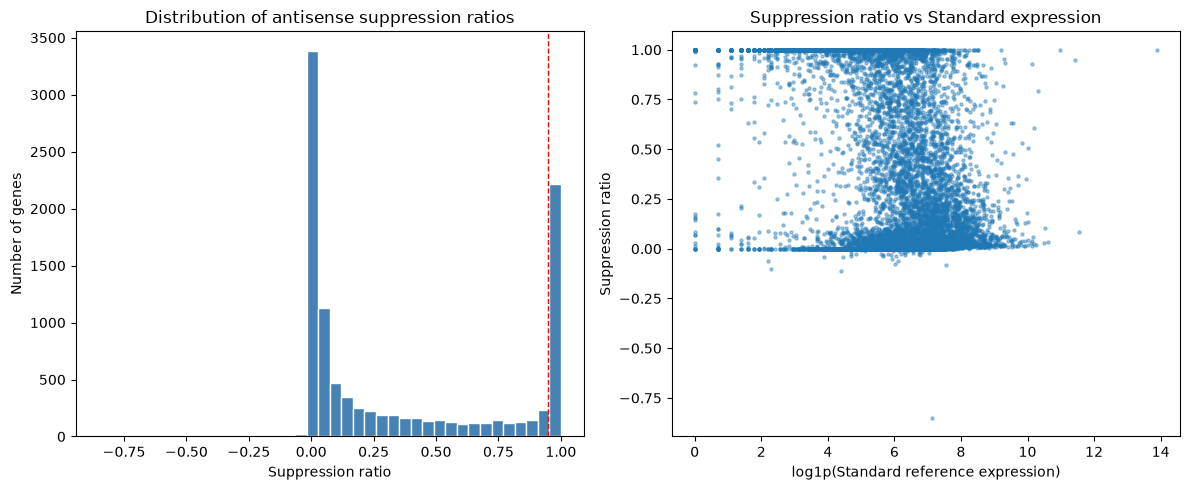

In [21]:
antisense_classes = {'antisense_exonic', 'antisense_intronic'}

aug_antisense_names = [v for v in adatas_raw['SR_Aug'].var_names if parse_discovery_id(v)[1] in antisense_classes]
dis_antisense_set = set(adatas_raw['SR_Dis'].var_names)
shared_antisense = [v for v in aug_antisense_names if v in dis_antisense_set]

print(f"Shared antisense peaks between Aug and Dis: {len(shared_antisense):,}")

aug_as_counts = np.asarray(adatas_raw['SR_Aug'][:, shared_antisense].X.sum(axis=0)).ravel()
dis_as_counts = np.asarray(adatas_raw['SR_Dis'][:, shared_antisense].X.sum(axis=0)).ravel()
contexts = [parse_discovery_id(v)[0] for v in shared_antisense]

antisense_df = pd.DataFrame({'peak': shared_antisense, 'gene_context': contexts,
                              'aug_count': aug_as_counts, 'dis_count': dis_as_counts})

gene_level_suppression = antisense_df.groupby('gene_context')[['aug_count', 'dis_count']].sum().reset_index()
gene_level_suppression['suppression_ratio'] = 1 - (
    gene_level_suppression['aug_count'] / gene_level_suppression['dis_count'].replace(0, np.nan)
)

std_totals_series = pd.Series(np.asarray(adatas_raw['SR_Std'].X.sum(axis=0)).ravel(), index=adatas_raw['SR_Std'].var_names)
gene_level_suppression['std_expr'] = gene_level_suppression['gene_context'].map(std_totals_series)

n_fully_suppressed = (gene_level_suppression['suppression_ratio'] > 0.95).sum()
print(f"Genes with antisense peaks ~fully suppressed in Aug (ratio > 0.95): "
      f"{n_fully_suppressed:,} / {len(gene_level_suppression):,}")

corr = gene_level_suppression[['std_expr', 'suppression_ratio']].corr().iloc[0, 1]
print(f"Correlation: STD gene expression vs suppression ratio: {corr:.3f}")

print("\nTop 15 most-suppressed genes (by ratio):")
display(gene_level_suppression.sort_values('suppression_ratio', ascending=False).head(15))

#Scatter plot and Histogram
MIN_DIS_COUNT = 10

n_excluded = (gene_level_suppression['dis_count'] < MIN_DIS_COUNT).sum()
print(f"Excluding {n_excluded:,} of {len(gene_level_suppression):,} genes with dis_count < {MIN_DIS_COUNT} "
      f"(ratio numerically unstable at very low counts)")

stable_suppression = gene_level_suppression[gene_level_suppression['dis_count'] >= MIN_DIS_COUNT].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(stable_suppression['suppression_ratio'].clip(lower=-1, upper=1).dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0.95, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Suppression ratio')
axes[0].set_ylabel('Number of genes')
axes[0].set_title('Distribution of antisense suppression ratios')

axes[1].scatter(np.log1p(stable_suppression['std_expr']), stable_suppression['suppression_ratio'].clip(lower=-1, upper=1), s=5, alpha=0.4)
axes[1].set_xlabel('log1p(Standard reference expression)')
axes[1].set_ylabel('Suppression ratio')
axes[1].set_title('Suppression ratio vs Standard expression')

plt.tight_layout()
plt.show()

## Antisense-only, intergenic-only, and intronic-only subclustering

SR Aug antisense-only: 67,654 features
SR Aug intergenic-only: 14,930 features
SR Aug intronic-only (known_gene_intronic): 0 features
SR Dis antisense-only: 67,654 features
SR Dis intergenic-only: 14,930 features
SR Aug antisense-only: 23 clusters (67,654 features)
SR Aug intergenic-only: 26 clusters (14,930 features)
Skipping 'SR Aug intronic-only': contains 0 features.
SR Dis antisense-only: 20 clusters (67,654 features)
SR Dis intergenic-only: 23 clusters (14,930 features)


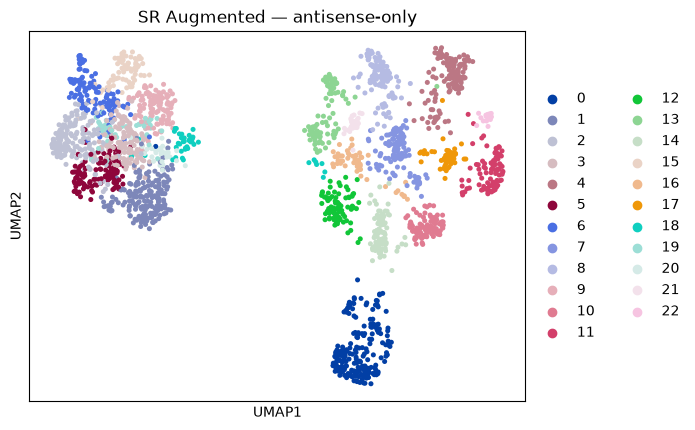

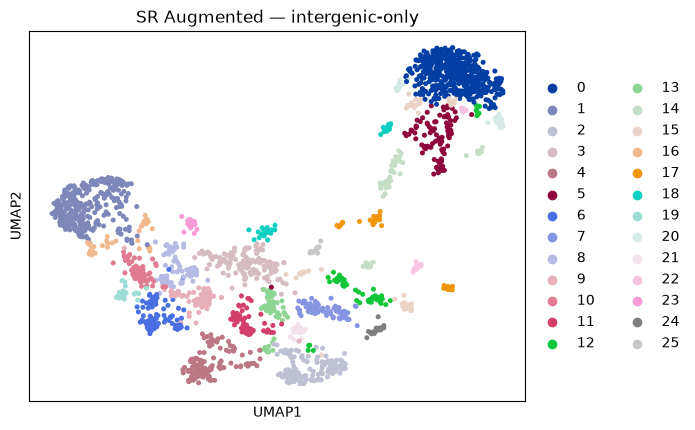

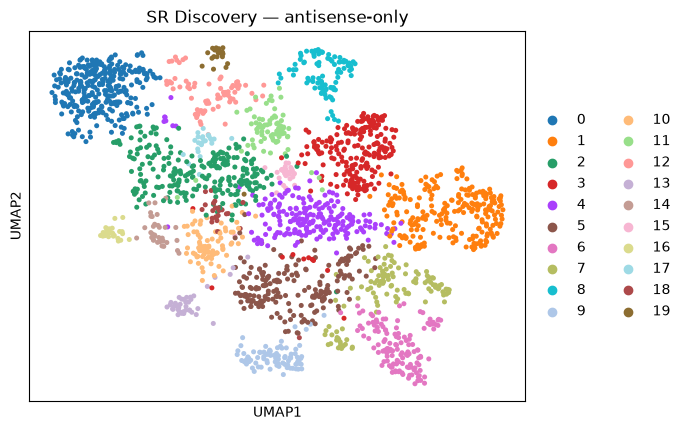

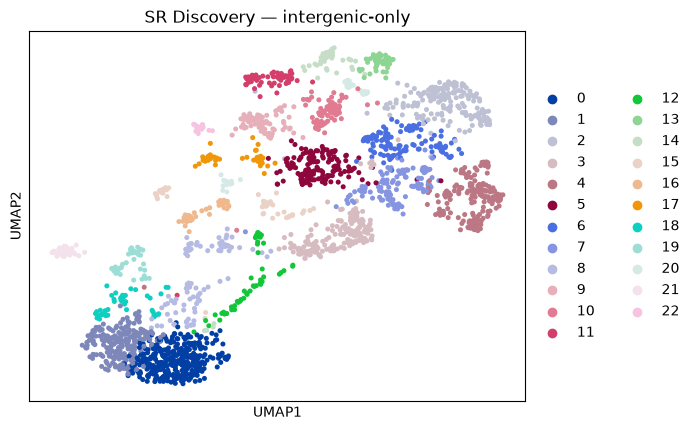

In [22]:
def subset_by_class(adata_raw, classes):
    mask = np.array([parse_discovery_id(v)[1] in classes for v in adata_raw.var_names])
    return adata_raw[:, mask].copy()

sr_aug_antisense = subset_by_class(adatas_raw['SR_Aug'], {'antisense_exonic', 'antisense_intronic'})
sr_aug_intergenic = subset_by_class(adatas_raw['SR_Aug'], {'intergenic'})
sr_aug_intronic = subset_by_class(adatas_raw['SR_Aug'], {'known_gene_intronic'})
sr_dis_antisense = subset_by_class(adatas_raw['SR_Dis'], {'antisense_exonic', 'antisense_intronic'})
sr_dis_intergenic = subset_by_class(adatas_raw['SR_Dis'], {'intergenic'})

print(f"SR Aug antisense-only: {sr_aug_antisense.n_vars:,} features")
print(f"SR Aug intergenic-only: {sr_aug_intergenic.n_vars:,} features")
print(f"SR Aug intronic-only (known_gene_intronic): {sr_aug_intronic.n_vars:,} features")
print(f"SR Dis antisense-only: {sr_dis_antisense.n_vars:,} features")
print(f"SR Dis intergenic-only: {sr_dis_intergenic.n_vars:,} features")


def cluster_subset(adata, resolution=1.0, label=""):
    if adata.n_vars == 0:
        print(f"Skipping '{label}': contains 0 features.")
        return None
    a = adata.copy()
    a.layers['counts'] = a.X.copy()
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)
    n_top = min(2000, a.n_vars)
    n_comps = min(30, a.n_vars - 1, a.n_obs - 1)
    if n_comps < 1:
        print(f"Skipping '{label}': not enough features/cells for PCA.")
        return None
    sc.pp.highly_variable_genes(a, n_top_genes=n_top, flavor='seurat')
    sc.tl.pca(a, svd_solver='arpack', random_state=42, n_comps=n_comps)
    sc.pp.neighbors(a, n_neighbors=15, n_pcs=min(30, n_comps), random_state=42)
    sc.tl.umap(a, random_state=42)
    sc.tl.leiden(a, resolution=resolution, key_added='leiden', random_state=42)
    print(f"{label}: {a.obs['leiden'].nunique()} clusters ({a.n_vars:,} features)")
    return a

sr_aug_antisense_cl = cluster_subset(sr_aug_antisense, label="SR Aug antisense-only")
sr_aug_intergenic_cl = cluster_subset(sr_aug_intergenic, label="SR Aug intergenic-only")
sr_aug_intronic_cl = cluster_subset(sr_aug_intronic, label="SR Aug intronic-only")
sr_dis_antisense_cl = cluster_subset(sr_dis_antisense, label="SR Dis antisense-only")
sr_dis_intergenic_cl = cluster_subset(sr_dis_intergenic, label="SR Dis intergenic-only")

if sr_aug_antisense_cl: sc.pl.umap(sr_aug_antisense_cl, color='leiden', title='SR Augmented — antisense-only')
if sr_aug_intergenic_cl: sc.pl.umap(sr_aug_intergenic_cl, color='leiden', title='SR Augmented — intergenic-only')
if sr_aug_intronic_cl: sc.pl.umap(sr_aug_intronic_cl, color='leiden', title='SR Augmented — intronic-only (known_gene_intronic)')
if sr_dis_antisense_cl: sc.pl.umap(sr_dis_antisense_cl, color='leiden', title='SR Discovery — antisense-only')
if sr_dis_intergenic_cl: sc.pl.umap(sr_dis_intergenic_cl, color='leiden', title='SR Discovery — intergenic-only')

## CellTypist colouring for Augmented's three novel-peak subsets

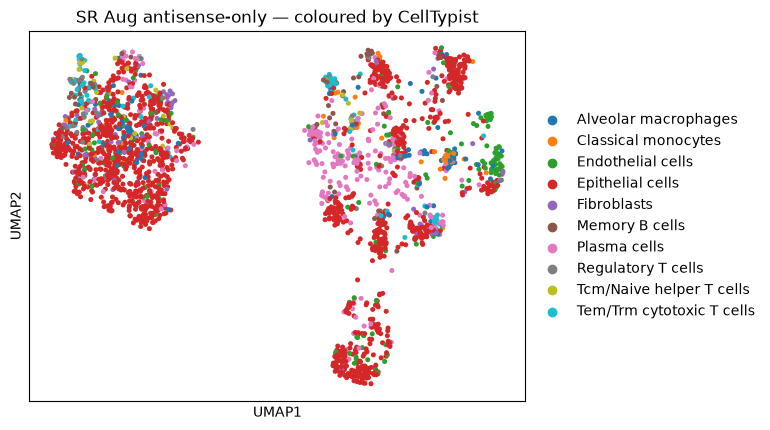

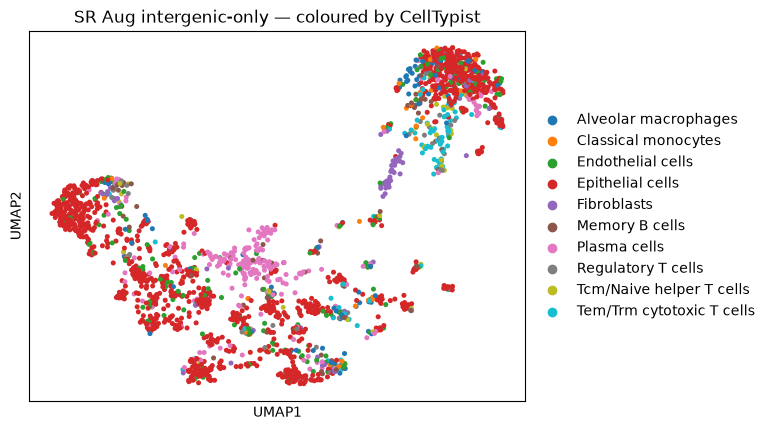

In [23]:
for subset_adata, subset_name in [
    (sr_aug_antisense_cl, 'SR Aug antisense-only'),
    (sr_aug_intergenic_cl, 'SR Aug intergenic-only'),
    (sr_aug_intronic_cl, 'SR Aug intronic-only'),
]:
    if subset_adata is not None:
        subset_adata.obs['celltypist_label'] = adatas['SR_Aug'].obs['celltypist_label'].reindex(subset_adata.obs_names).values
        sc.pl.umap(subset_adata, color='celltypist_label', title=f'{subset_name} — coloured by CellTypist')

## Novel-feature landscape antisense, intergenic, and intronic combined

SR Aug combined (all novel classes): 82,584 features
SR Dis combined (all novel classes): 82,584 features
SR Aug combined: 24 clusters (82,584 features)
SR Dis combined: 19 clusters (82,584 features)


... storing 'dominant_feature_type' as categorical


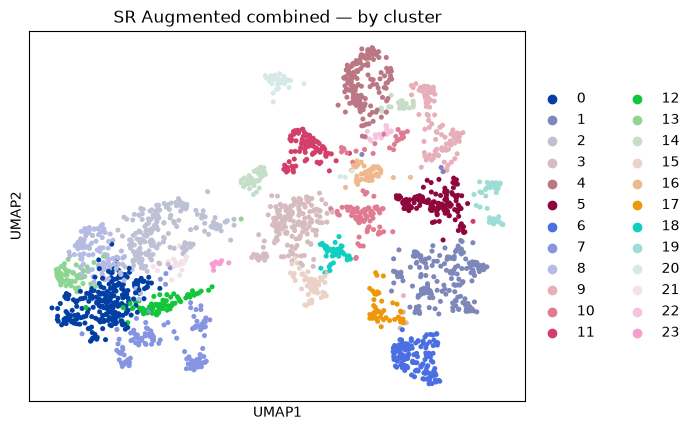

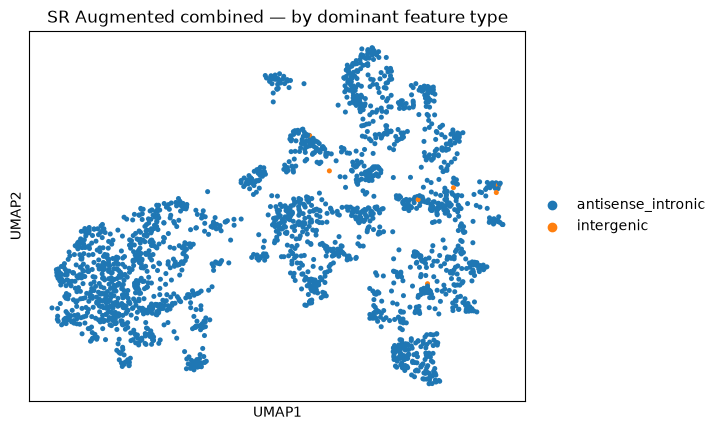

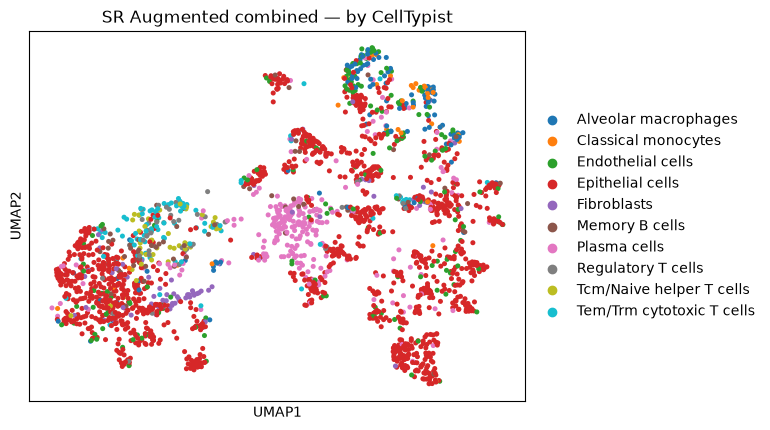

... storing 'dominant_feature_type' as categorical


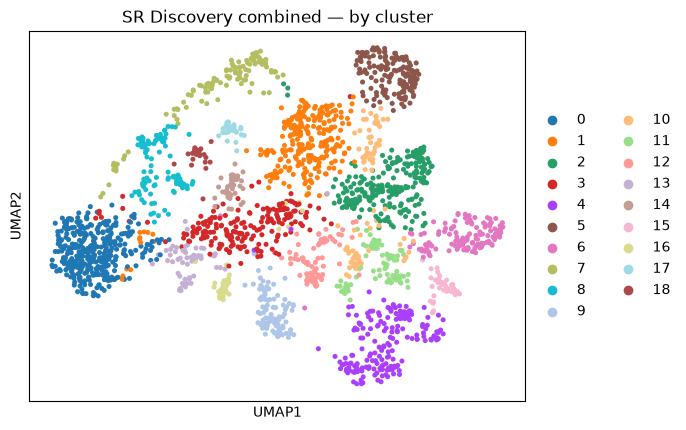

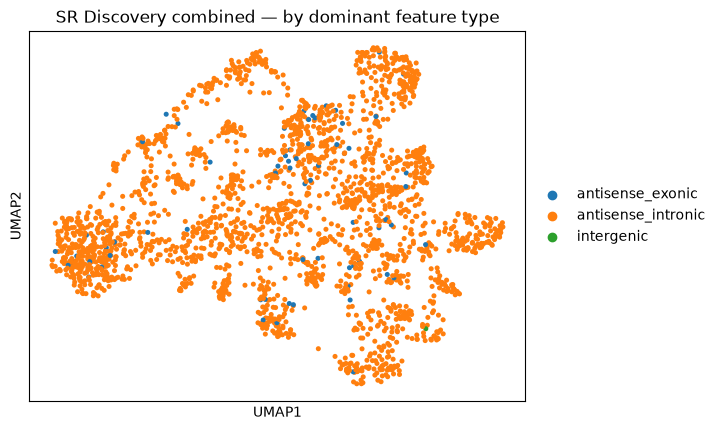

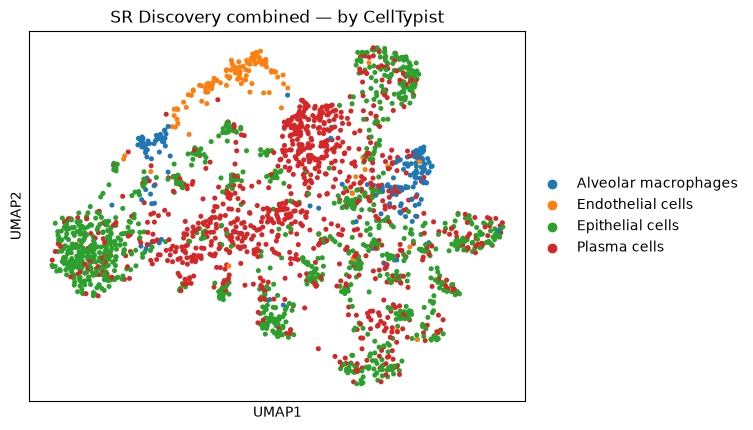

In [24]:
sr_aug_combined = subset_by_class(
    adatas_raw['SR_Aug'], {'antisense_exonic', 'antisense_intronic', 'intergenic', 'known_gene_intronic'}
)
sr_dis_combined = subset_by_class(
    adatas_raw['SR_Dis'], {'antisense_exonic', 'antisense_intronic', 'intergenic'}
)

print(f"SR Aug combined (all novel classes): {sr_aug_combined.n_vars:,} features")
print(f"SR Dis combined (all novel classes): {sr_dis_combined.n_vars:,} features")

sr_aug_combined_cl = cluster_subset(sr_aug_combined, label="SR Aug combined")
sr_dis_combined_cl = cluster_subset(sr_dis_combined, label="SR Dis combined")


def assign_dominant_feature_type(adata_raw_subset, adata_clustered, classes):
    """For each cell, which of the combined classes contributes the most signal —
    a per-cell summary of what kind of novel feature is driving that cell's profile."""
    if adata_clustered is None:
        return
    class_totals = {}
    for cls in classes:
        cls_mask = np.array([parse_discovery_id(v)[1] == cls for v in adata_raw_subset.var_names])
        if cls_mask.sum() == 0:
            class_totals[cls] = np.zeros(adata_raw_subset.n_obs)
            continue
        class_totals[cls] = np.asarray(adata_raw_subset[:, cls_mask].X.sum(axis=1)).ravel()
    totals_df = pd.DataFrame(class_totals, index=adata_raw_subset.obs_names)
    dominant = totals_df.idxmax(axis=1)
    adata_clustered.obs['dominant_feature_type'] = dominant.reindex(adata_clustered.obs_names).values


assign_dominant_feature_type(sr_aug_combined, sr_aug_combined_cl,
                              {'antisense_exonic', 'antisense_intronic', 'intergenic', 'known_gene_intronic'})
assign_dominant_feature_type(sr_dis_combined, sr_dis_combined_cl,
                              {'antisense_exonic', 'antisense_intronic', 'intergenic'})

if sr_aug_combined_cl is not None:
    sc.pl.umap(sr_aug_combined_cl, color='leiden', title='SR Augmented combined — by cluster')
    sc.pl.umap(sr_aug_combined_cl, color='dominant_feature_type', title='SR Augmented combined — by dominant feature type')
    sr_aug_combined_cl.obs['celltypist_label'] = adatas['SR_Aug'].obs['celltypist_label'].reindex(sr_aug_combined_cl.obs_names).values
    sc.pl.umap(sr_aug_combined_cl, color='celltypist_label', title='SR Augmented combined — by CellTypist')

if sr_dis_combined_cl is not None:
    sc.pl.umap(sr_dis_combined_cl, color='leiden', title='SR Discovery combined — by cluster')
    sc.pl.umap(sr_dis_combined_cl, color='dominant_feature_type', title='SR Discovery combined — by dominant feature type')
    sr_dis_combined_cl.obs['celltypist_label'] = adatas['SR_Dis'].obs['celltypist_label'].reindex(sr_dis_combined_cl.obs_names).values
    sc.pl.umap(sr_dis_combined_cl, color='celltypist_label', title='SR Discovery combined — by CellTypist')

## AUG DIS top-marker-peak cross-matching


/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:463: Performanc

Top antisense marker overall (Aug): MFSD4B|antisense_intronic|peak_106619 (cluster 0, score=24.2)


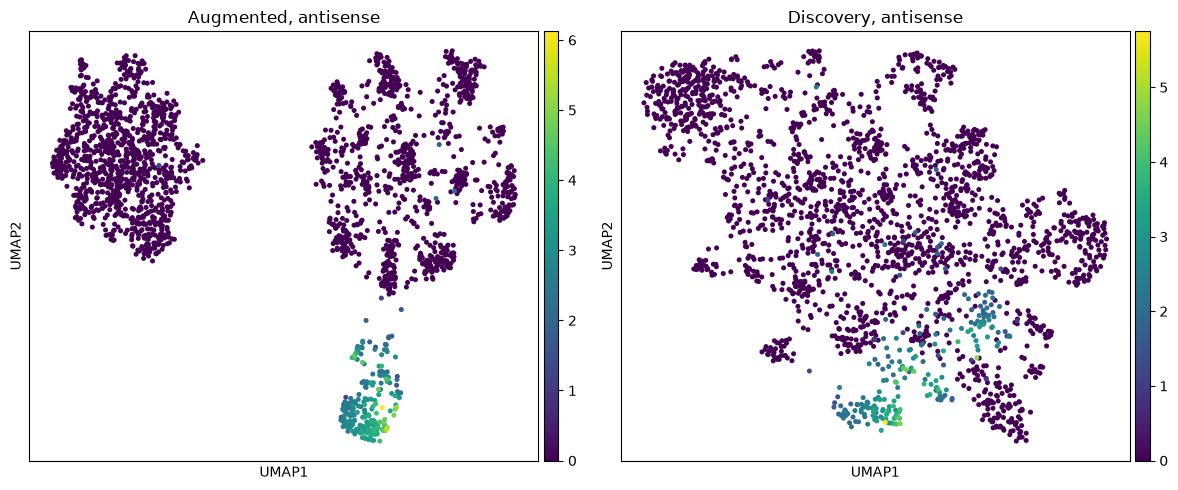

/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:463: Performanc

Top intergenic marker overall (Aug): intergenic|intergenic|peak_58319 (cluster 1, score=22.8)


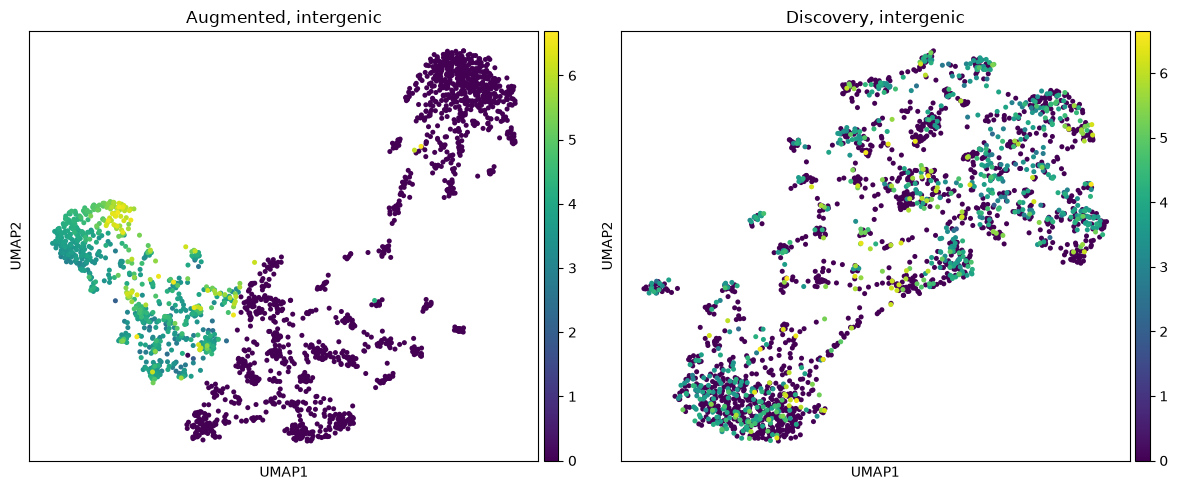

/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/jack/miniforge3/envs/scanpy/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:463: Performanc

Top combined (all novel classes) marker overall (Aug): near:NDRG1:59482bp|intergenic|peak_54380 (cluster 1, score=20.2)


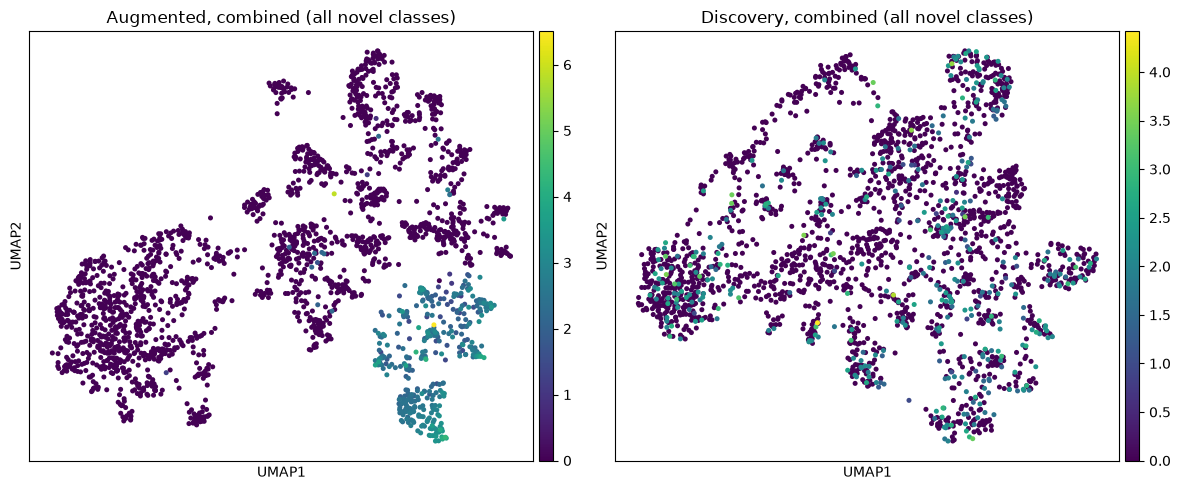

In [25]:
def find_and_compare_top_marker(adata_aug_subset, adata_dis_subset, label):
    sc.tl.rank_genes_groups(adata_aug_subset, groupby='leiden', method='wilcoxon')
    all_markers = pd.concat([
        sc.get.rank_genes_groups_df(adata_aug_subset, group=c).assign(cluster=c)
        for c in adata_aug_subset.obs['leiden'].cat.categories
    ])
    top = all_markers.sort_values('scores', ascending=False).iloc[0]
    print(f"Top {label} marker overall (Aug): {top['names']} (cluster {top['cluster']}, score={top['scores']:.1f})")

    peak_id = parse_discovery_id(top['names'])[2]
    dis_match = [v for v in adata_dis_subset.var_names if parse_discovery_id(v)[2] == peak_id]

    if not dis_match:
        print(f"No matching peak_id found in Dis {label} subset.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sc.pl.umap(adata_aug_subset, color=top['names'], ax=axes[0], show=False, title=f'Augmented, {label}')
    sc.pl.umap(adata_dis_subset, color=dis_match[0], ax=axes[1], show=False, title=f'Discovery, {label}')
    plt.tight_layout()
    plt.show()

if sr_aug_antisense_cl is not None and sr_dis_antisense_cl is not None:
    find_and_compare_top_marker(sr_aug_antisense_cl, sr_dis_antisense_cl, 'antisense')
if sr_aug_intergenic_cl is not None and sr_dis_intergenic_cl is not None:
    find_and_compare_top_marker(sr_aug_intergenic_cl, sr_dis_intergenic_cl, 'intergenic')
if sr_aug_combined_cl is not None and sr_dis_combined_cl is not None:
    find_and_compare_top_marker(sr_aug_combined_cl, sr_dis_combined_cl, 'combined (all novel classes)')

## Volcano plots + STRING export

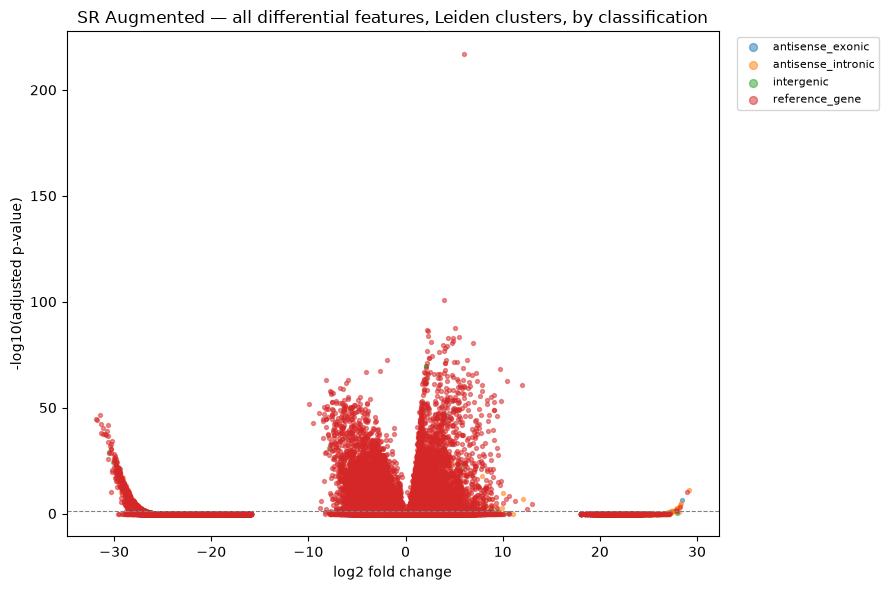

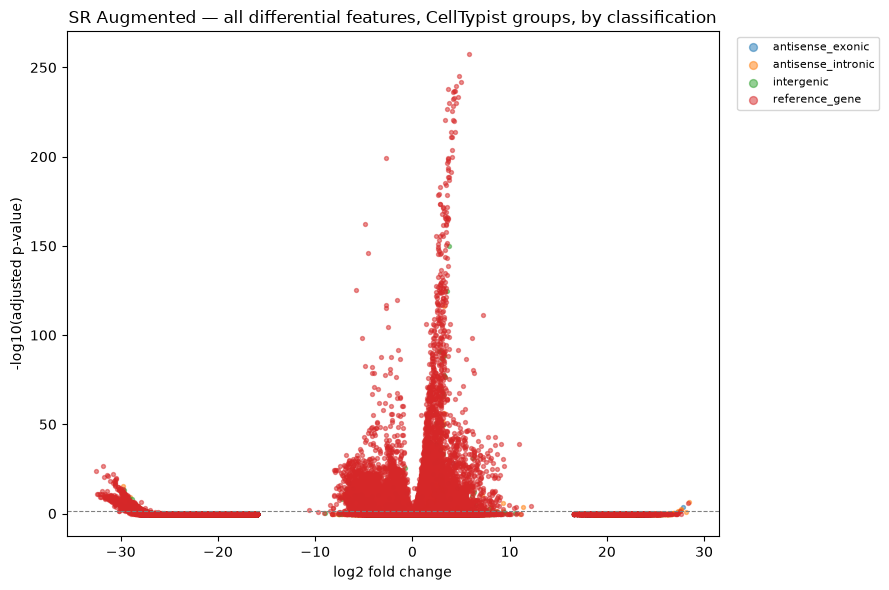

In [26]:
def build_volcano_data(adata, key='rank_genes_groups'):
    groups = list(adata.uns[key]['names'].dtype.names)
    rows = []
    for g in groups:
        names = adata.uns[key]['names'][g]
        lfcs = adata.uns[key]['logfoldchanges'][g]
        padjs = adata.uns[key]['pvals_adj'][g]
        for nm, lfc, padj in zip(names, lfcs, padjs):
            if '|' in nm:
                context, classification, peak_id = parse_discovery_id(nm)
            else:
                context, classification, peak_id = nm, 'reference_gene', None
            rows.append({'group': g, 'feature': nm, 'gene_context': context,
                         'classification': classification, 'log2FC': lfc, 'padj': padj})
    return pd.DataFrame(rows)


def plot_volcano(df, title):
    df = df.copy()
    df['neg_log10_padj'] = -np.log10(df['padj'].replace(0, 1e-300))
    fig, ax = plt.subplots(figsize=(9, 6))
    for cls, group_df in df.groupby('classification'):
        ax.scatter(group_df['log2FC'], group_df['neg_log10_padj'], s=8, alpha=0.5, label=cls)
    ax.axhline(-np.log10(0.05), color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlabel('log2 fold change')
    ax.set_ylabel('-log10(adjusted p-value)')
    ax.set_title(title)
    ax.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


volcano_df_leiden = build_volcano_data(adatas['SR_Aug'], key='rank_genes_groups')
volcano_df_celltype = build_volcano_data(adatas['SR_Aug'], key='rank_genes_groups_celltypist')

plot_volcano(volcano_df_leiden, 'SR Augmented — all differential features, Leiden clusters, by classification')
plot_volcano(volcano_df_celltype, 'SR Augmented — all differential features, CellTypist groups, by classification')

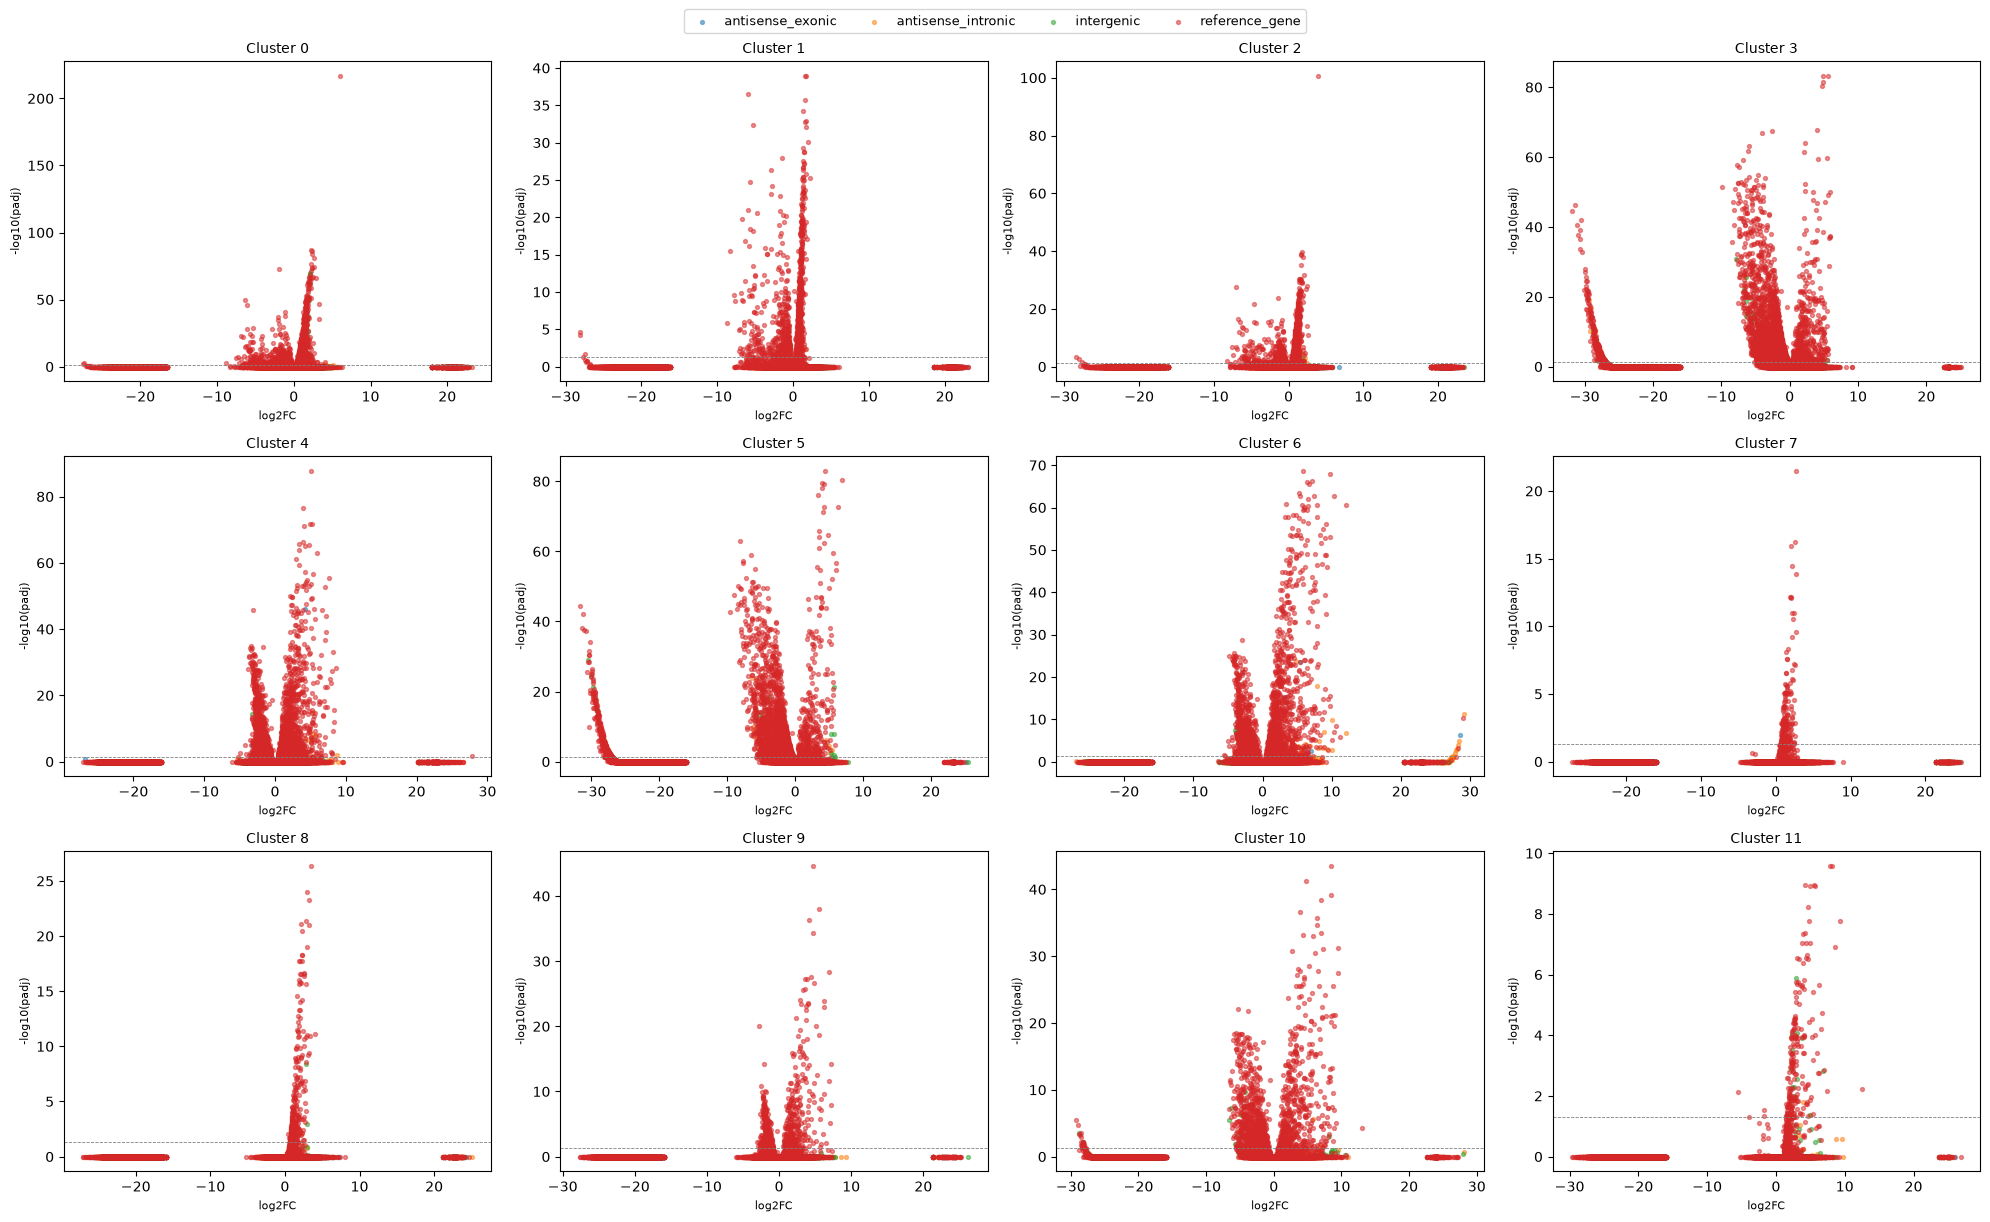

In [27]:
def plot_volcano_per_cluster(adata, key='rank_genes_groups'):
    volcano_df = build_volcano_data(adata, key=key)
    groups = sorted(volcano_df['group'].unique(), key=lambda x: (len(x), x))
    n_cols = 4
    n_rows = int(np.ceil(len(groups) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for ax, group in zip(axes, groups):
        group_df = volcano_df[volcano_df['group'] == group].copy()
        group_df['neg_log10_padj'] = -np.log10(group_df['padj'].replace(0, 1e-300))
        for cls, cls_df in group_df.groupby('classification'):
            ax.scatter(cls_df['log2FC'], cls_df['neg_log10_padj'], s=8, alpha=0.5, label=cls)
        ax.axhline(-np.log10(0.05), color='grey', linestyle='--', linewidth=0.6)
        ax.set_title(f'Cluster {group}', fontsize=10)
        ax.set_xlabel('log2FC', fontsize=8)
        ax.set_ylabel('-log10(padj)', fontsize=8)

    for ax in axes[len(groups):]:
        ax.axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=len(labels), fontsize=9)
    plt.tight_layout()
    plt.show()

plot_volcano_per_cluster(adatas['SR_Aug'], key='rank_genes_groups')

In [28]:
STRING_OUT_DIR = "/mnt/md0/jack-gaa/gaa/analysis/string_export/"
os.makedirs(STRING_OUT_DIR, exist_ok=True)

SIG_PADJ = 0.05
SIG_LOG2FC = 1.0

def clean_gene_symbols(gene_contexts):
    
    return sorted(set(g for g in gene_contexts if g and g != 'intergenic' and not g.startswith('near:')))

sig_leiden = volcano_df_leiden[(volcano_df_leiden['padj'] < SIG_PADJ) & (volcano_df_leiden['log2FC'].abs() >= SIG_LOG2FC)]
sig_celltype = volcano_df_celltype[(volcano_df_celltype['padj'] < SIG_PADJ) & (volcano_df_celltype['log2FC'].abs() >= SIG_LOG2FC)]

genes_leiden = clean_gene_symbols(sig_leiden['gene_context'])
genes_celltype = clean_gene_symbols(sig_celltype['gene_context'])

pd.Series(genes_leiden).to_csv(os.path.join(STRING_OUT_DIR, "sr_aug_novel_genes_leiden_STRING.csv"), index=False, header=False)
pd.Series(genes_celltype).to_csv(os.path.join(STRING_OUT_DIR, "sr_aug_novel_genes_celltype_STRING.csv"), index=False, header=False)

print(f"Leiden-based (all significant, global threshold): {len(genes_leiden)} genes saved for STRING")
print(f"CellTypist-based (all significant, global threshold): {len(genes_celltype)} genes saved for STRING")
print(f"Saved to {STRING_OUT_DIR}")

Leiden-based (all significant, global threshold): 5402 genes saved for STRING
CellTypist-based (all significant, global threshold): 5209 genes saved for STRING
Saved to /mnt/md0/jack-gaa/gaa/analysis/string_export/


## Cluster-based STRING list, corrected to use std_mapped_cluster

In [29]:
valid_groups = [g for g, n in adatas['SR_Aug'].obs['std_mapped_cluster'].value_counts().items() if n >= 2]
excluded = set(adatas['SR_Aug'].obs['std_mapped_cluster'].unique()) - set(valid_groups)
print(f"Excluding std_mapped_cluster group(s) with fewer than 2 cells: {excluded}")

sc.tl.rank_genes_groups(adatas['SR_Aug'], groupby='std_mapped_cluster', groups=valid_groups,
                         method='wilcoxon', key_added='rank_genes_groups_stdmapped')

sr_aug_peak_ranking_stdmapped = build_peak_marker_ranking_table(
    adatas['SR_Aug'], 'SR_Aug', top_n_per_cluster=15, key='rank_genes_groups_stdmapped'
)

def get_top_n_genes_per_cluster(ranking_table, n=15):
    return ranking_table.sort_values('score', ascending=False).groupby('group').head(n)

sr_aug_top_per_cluster = get_top_n_genes_per_cluster(sr_aug_peak_ranking_stdmapped, n=15)
top_per_cluster_genes = clean_gene_symbols(sr_aug_top_per_cluster['gene_context'])

print(f"Top 15 per STD-MAPPED CLUSTER: {len(top_per_cluster_genes)} distinct genes across "
      f"{sr_aug_top_per_cluster['group'].nunique()} clusters")

pd.Series(top_per_cluster_genes).to_csv(
    os.path.join(STRING_OUT_DIR, "sr_aug_novel_genes_top_per_cluster_STRING.csv"), index=False, header=False
)

print("\n--- Copy-paste ready (top per cluster, std_mapped) ---")
print("\n".join(top_per_cluster_genes))

Excluding std_mapped_cluster group(s) with fewer than 2 cells: set()
Top 15 per STD-MAPPED CLUSTER: 138 distinct genes across 11 clusters

--- Copy-paste ready (top per cluster, std_mapped) ---
ADAM28
ADGRL4
AFF3
ANK2
ANKRD36BP2
ANKRD44
ANO2
AOAH
ARHGAP15
ARHGAP24
ARL15
ARPP21
ATG7
B2M
BCL11A
BCL11B
BCL2
BRINP3
CACNA1C
CALCRL
CALD1
CCDC102B
CD38
CD96
CDH12
CDK14
CELF2
COL4A1
COL4A2
COL5A2
COL6A6
CPEB4
CTSB
DANT2
DLC1
DMXL2
DOCK4
DOCK8
EBF1
EGFL7
EGFR
ELL2
ENSG00000227088
ENSG00000229618
ENSG00000251574
ENSG00000254202
ENSG00000285798
ERBB4
ERN1
FAM13A
FBXL7
FBXW7
FCRL5
FLT1
FMNL2
FNDC3A
FRMD4A
FRMD4B
FUT8
FYB1
FYN
GLCCI1
GNAQ
GPC6
GRB10
HLA-B
IFNG-AS1
IGFBP7
IGHG1
IGHG3
IGHG4
IGKC
IKZF3
INSR
ITK
KAZN
KCNIP4
LAMA4
LDB2
LHFPL6
LINC00355
LINC00540
LINC01934
LINC02045
LINC02476
LINC02484
LINC02906
LRFN5
LRRC7
LYN
MBNL1
MTCP1
MYOCOS
NDRG1
NEBL
NIHCOLE
PAX5
PCDH9
PCSK6
PDE1A
PDGFRB
PIM2
PLPP1
PRKCB
PRKCH
PRKG1
PTPRC
QKI
RALGPS2
RBMS3
RIPOR2
ROBO2
RUFY3
SAT1
SEL1L3
SKAP1
SLC4A4
SLC8A1
SLFN12L

## Plateau test, corrected

In [30]:
sr_aug_peak_ranking_cluster_based_deep = build_peak_marker_ranking_table(
    adatas['SR_Aug'], 'SR_Aug', top_n_per_cluster=300, key='rank_genes_groups_stdmapped'
)

for n in [5, 10, 15, 20, 30, 50, 60, 80, 90, 95, 100, 110, 130, 150, 200, 250, 300]:
    test = get_top_n_genes_per_cluster(sr_aug_peak_ranking_cluster_based_deep, n=n)
    genes = clean_gene_symbols(test['gene_context'])
    print(f"Cluster Based, n={n}: {len(genes)} distinct genes")

Cluster Based, n=5: 50 distinct genes
Cluster Based, n=10: 95 distinct genes
Cluster Based, n=15: 138 distinct genes
Cluster Based, n=20: 183 distinct genes
Cluster Based, n=30: 266 distinct genes
Cluster Based, n=50: 430 distinct genes
Cluster Based, n=60: 496 distinct genes
Cluster Based, n=80: 634 distinct genes
Cluster Based, n=90: 700 distinct genes
Cluster Based, n=95: 739 distinct genes
Cluster Based, n=100: 775 distinct genes
Cluster Based, n=110: 844 distinct genes
Cluster Based, n=130: 986 distinct genes
Cluster Based, n=150: 1115 distinct genes
Cluster Based, n=200: 1443 distinct genes
Cluster Based, n=250: 1762 distinct genes
Cluster Based, n=300: 2067 distinct genes


In [31]:
sr_aug_peak_ranking_celltype = build_peak_marker_ranking_table(
    adatas['SR_Aug'], 'SR_Aug', top_n_per_cluster=15, key='rank_genes_groups_celltypist'
)

sr_aug_top_per_celltype = get_top_n_genes_per_cluster(sr_aug_peak_ranking_celltype, n=15)
top_per_celltype_genes = clean_gene_symbols(sr_aug_top_per_celltype['gene_context'])

print(f"Top 15 per CELL TYPE: {len(top_per_celltype_genes)} distinct genes across "
      f"{sr_aug_top_per_celltype['group'].nunique()} cell types")

pd.Series(top_per_celltype_genes).to_csv(
    os.path.join(STRING_OUT_DIR, "sr_aug_novel_genes_top_per_celltype_STRING.csv"), index=False, header=False
)

print("\n--- Copy-paste ready (top per cell type) ---")
print("\n".join(top_per_celltype_genes))

print(f"\nCompare against the cluster-based version: "
      f"{len(top_per_celltype_genes)} (cell-type) vs {len(top_per_cluster_genes)} (cluster) distinct genes.")

Top 15 per CELL TYPE: 124 distinct genes across 10 cell types

--- Copy-paste ready (top per cell type) ---
ADAM28
ADAMTS9
ADGRL4
AFF3
ANKRD36BP2
ANKRD44
AOAH
ARHGAP15
ARHGAP24
ARHGAP29
ARL15
ATG7
B2M
BCL11A
BCL11B
CACNA1C
CALD1
CBLB
CCDC102B
CD74
CD86
CD96
CDK14
CELF2
COL23A1
COL4A1
COL4A2
COL5A2
CPEB4
CTSB
DAPK1
DLC1
DMXL2
DNAH11
DOCK10
DOCK2
DOCK4
DOCK8
DYSF
EBF1
ELL2
ENSG00000229618
ENSG00000284418
ERN1
ETS1
ETV6
FAM13A
FBXL7
FBXW7
FCRL5
FGD2
FLT1
FMNL2
FNDC3A
FRMD4B
FUT8
FYB1
FYN
GAPDH
GLUL
GNAQ
HLA-A
HLA-B
HLA-DRA
IFNG-AS1
IGFBP7
IGHG1
IGHG3
IGKC
IKZF1
INSR
ITGAE
KCNIP4
LAMA4
LDB2
LHFPL6
LRRC7
LYN
MAGI1
MAP3K5
MBNL1
MTCP1
NDRG1
NIHCOLE
NLGN1
PARP8
PCSK6
PDGFRB
PHACTR2
PLPP1
PLPP3
PRKCB
PRKCH
PSAP
PTPRC
PTPRK
QKI
RAB31
RALGPS2
RBMS3
RIPOR2
SAT1
SKAP1
SLC8A1
SLFN12L
SLIT2
SPRY1
SRGN
ST6GAL1
SYNPO2
TANC1
TCF4
TENM3
TENT5C
TFEC
THEMIS
TOX
VEGFA
WDFY4
XBP1
ZCCHC7
ZEB2
ZFP36L2
ZFPM2

Compare against the cluster-based version: 124 (cell-type) vs 138 (cluster) distinct genes.


## Plateau test

In [32]:
sr_aug_peak_ranking_cell_type_based_deep = build_peak_marker_ranking_table(
    adatas['SR_Aug'], 'SR_Aug', top_n_per_cluster=300, key='rank_genes_groups_celltypist'
)

for n in [5, 10, 15, 20, 30, 50, 60, 80, 90, 95, 100, 110, 130, 150, 200, 250, 300]:
    test = get_top_n_genes_per_cluster(sr_aug_peak_ranking_cell_type_based_deep, n=n)
    genes = clean_gene_symbols(test['gene_context'])
    print(f"Cell Type Based, n={n}: {len(genes)} distinct genes")

Cell Type Based, n=5: 44 distinct genes
Cell Type Based, n=10: 84 distinct genes
Cell Type Based, n=15: 124 distinct genes
Cell Type Based, n=20: 166 distinct genes
Cell Type Based, n=30: 242 distinct genes
Cell Type Based, n=50: 392 distinct genes
Cell Type Based, n=60: 456 distinct genes
Cell Type Based, n=80: 581 distinct genes
Cell Type Based, n=90: 650 distinct genes
Cell Type Based, n=95: 678 distinct genes
Cell Type Based, n=100: 710 distinct genes
Cell Type Based, n=110: 776 distinct genes
Cell Type Based, n=130: 894 distinct genes
Cell Type Based, n=150: 1012 distinct genes
Cell Type Based, n=200: 1289 distinct genes
Cell Type Based, n=250: 1566 distinct genes
Cell Type Based, n=300: 1827 distinct genes


## Top novel non-antisense markers for Endothelial and Fibroblasts

In [33]:
CLUSTERS_OF_INTEREST_SR = {'Endothelial': 6, 'Fibroblasts': 9}

NON_ANTISENSE_NOVEL = {'intergenic', 'extended_exon', 'proximal_novel_exon'}

def top_novel_non_antisense_markers(deep_ranking_table, cluster_number, n=10):
    """Top-n Augmented markers for one std_mapped_cluster, restricted to
    non-antisense novel classes. Needs a table built with top_n_per_cluster
    large enough that these classes aren't crowded out by antisense entries
    at the same locus (300 here, same depth as the n=15 plateau test above).
    Uses the cluster-based deep table (grouped by std_mapped_cluster), not the
    cell-type-based one, since CellTypist labels can span more than one cluster."""
    subset = deep_ranking_table[
        (deep_ranking_table['group'].astype(str) == str(cluster_number)) &
        (deep_ranking_table['classification'].isin(NON_ANTISENSE_NOVEL))
    ].sort_values('score', ascending=False)
    return subset.head(n)

print(f"=== SR Aug cluster {CLUSTERS_OF_INTEREST_SR['Endothelial']} (Endothelial): top non-antisense novel markers ===")
display(top_novel_non_antisense_markers(sr_aug_peak_ranking_cluster_based_deep, CLUSTERS_OF_INTEREST_SR['Endothelial']))

print(f"\n=== SR Aug cluster {CLUSTERS_OF_INTEREST_SR['Fibroblasts']} (Fibroblasts): top non-antisense novel markers ===")
display(top_novel_non_antisense_markers(sr_aug_peak_ranking_cluster_based_deep, CLUSTERS_OF_INTEREST_SR['Fibroblasts']))


=== SR Aug cluster 6 (Endothelial): top non-antisense novel markers ===


,condition,group,feature,gene_context,classification,peak_id,score,log2FC,padj



=== SR Aug cluster 9 (Fibroblasts): top non-antisense novel markers ===


,condition,group,feature,gene_context,classification,peak_id,score,log2FC,padj


## SR came back empty for both clusters

In [34]:
sr_all_novel_300 = sr_aug_peak_ranking_cluster_based_deep[
    sr_aug_peak_ranking_cluster_based_deep['classification'].isin(NON_ANTISENSE_NOVEL)
].sort_values('score', ascending=False)

print(f"Non-antisense novel markers across ALL SR Aug clusters (depth 300/cluster): {len(sr_all_novel_300)}")
if len(sr_all_novel_300):
    print("\nBreakdown by cluster:")
    display(sr_all_novel_300['group'].value_counts())
    print("\nTop 20 overall:")
    display(sr_all_novel_300.head(20))


sr_aug_peak_ranking_endo_fib_verydeep = build_peak_marker_ranking_table(
    adatas['SR_Aug'], 'SR_Aug', top_n_per_cluster=5000, key='rank_genes_groups_stdmapped'
)

for cl, label in [(6, 'Endothelial'), (9, 'Fibroblasts')]:
    cluster_full = sr_aug_peak_ranking_endo_fib_verydeep[
        sr_aug_peak_ranking_endo_fib_verydeep['group'].astype(str) == str(cl)
    ].reset_index(drop=True)
    deep_hits = top_novel_non_antisense_markers(sr_aug_peak_ranking_endo_fib_verydeep, cl, n=10)
    print(f"\n=== SR Aug cluster {cl} ({label}) at depth 5000: {len(deep_hits)} non-antisense novel markers ===")
    if len(deep_hits):
        for _, row in deep_hits.iterrows():
            rank = cluster_full.index[cluster_full['feature'] == row['feature']][0] + 1
            print(f"  {row['feature']}: rank {rank} of {len(cluster_full)}, score={row['score']:.2f}")
    display(deep_hits)


Non-antisense novel markers across ALL SR Aug clusters (depth 300/cluster): 43

Breakdown by cluster:


group
12    18
1     17
4      3
7      2
0      1
10     1
8      1
Name: count, dtype: int64


Top 20 overall:


,condition,group,feature,gene_context,classification,peak_id,score,log2FC,padj
43,SR_Aug,1,intergenic|intergenic|peak_58386,intergenic,intergenic,peak_58386,18.244236,2.133727,2.322118e-70
44,SR_Aug,1,near:ENSG00000229370:5472bp|intergenic|peak_86329,near:ENSG00000229370:5472bp,intergenic,peak_86329,18.212196,2.081615,3.850449e-70
89,SR_Aug,1,intergenic|intergenic|peak_58383,intergenic,intergenic,peak_58383,17.227848,2.140104,7.957236e-63
184,SR_Aug,1,near:ENSG00000229370:5901bp|intergenic|peak_86328,near:ENSG00000229370:5901bp,intergenic,peak_86328,15.807220,1.836971,9.087473e-53
212,SR_Aug,1,intergenic|intergenic|peak_58375,intergenic,intergenic,peak_58375,15.419834,1.984440,3.104881e-50
434,SR_Aug,1,intergenic|intergenic|peak_58377,intergenic,intergenic,peak_58377,13.512706,1.916274,1.733463e-38
443,SR_Aug,1,near:ENSG00000229370:8052bp|intergenic|peak_86322,near:ENSG00000229370:8052bp,intergenic,peak_86322,13.422930,1.713401,5.661659e-38
460,SR_Aug,1,near:ENSG00000229370:6136bp|intergenic|peak_86327,near:ENSG00000229370:6136bp,intergenic,peak_86327,13.299294,1.639139,2.803775e-37
495,SR_Aug,1,near:POU5F1:4504bp|intergenic|peak_105804,near:POU5F1:4504bp,intergenic,peak_105804,13.102393,1.553070,3.514936e-36
521,SR_Aug,1,near:ENSG00000229370:18018bp|intergenic|peak_8...,near:ENSG00000229370:18018bp,intergenic,peak_86301,12.940530,1.666919,2.729755e-35



=== SR Aug cluster 6 (Endothelial) at depth 5000: 10 non-antisense novel markers ===
  near:IVNS1ABP:45bp|intergenic|peak_62722: rank 1103 of 5000, score=3.83
  near:ENSG00000285801:847bp|intergenic|peak_105652: rank 1389 of 5000, score=3.15
  near:ENSG00000235146:35983bp|intergenic|peak_260: rank 1409 of 5000, score=3.12
  near:MT-ND1:2265bp|intergenic|peak_56388: rank 1541 of 5000, score=2.88
  near:MT-ND1:222bp|intergenic|peak_56393: rank 1574 of 5000, score=2.83
  near:ENSG00000254987:96419bp|intergenic|peak_69477: rank 1880 of 5000, score=2.44
  near:MT-ND1:1000bp|intergenic|peak_56392: rank 2110 of 5000, score=2.18
  near:ENSG00000232140:19453bp|intergenic|peak_29471: rank 2123 of 5000, score=2.17
  near:SPRY1:4326bp|intergenic|peak_40973: rank 2315 of 5000, score=1.99
  near:ITPRIP:122bp|intergenic|peak_66839: rank 2335 of 5000, score=1.97


,condition,group,feature,gene_context,classification,peak_id,score,log2FC,padj
7381,SR_Aug,6,near:IVNS1ABP:45bp|intergenic|peak_62722,near:IVNS1ABP:45bp,intergenic,peak_62722,3.832438,3.786211,0.008878
10070,SR_Aug,6,near:ENSG00000285801:847bp|intergenic|peak_105652,near:ENSG00000285801:847bp,intergenic,peak_105652,3.154352,3.470014,0.087771
10218,SR_Aug,6,near:ENSG00000235146:35983bp|intergenic|peak_260,near:ENSG00000235146:35983bp,intergenic,peak_260,3.124554,0.743870,0.095787
11625,SR_Aug,6,near:MT-ND1:2265bp|intergenic|peak_56388,near:MT-ND1:2265bp,intergenic,peak_56388,2.877129,0.471514,0.195164
11897,SR_Aug,6,near:MT-ND1:222bp|intergenic|peak_56393,near:MT-ND1:222bp,intergenic,peak_56393,2.830243,0.469213,0.220967
15068,SR_Aug,6,near:ENSG00000254987:96419bp|intergenic|peak_6...,near:ENSG00000254987:96419bp,intergenic,peak_69477,2.444098,6.440994,0.573056
17798,SR_Aug,6,near:MT-ND1:1000bp|intergenic|peak_56392,near:MT-ND1:1000bp,intergenic,peak_56392,2.184251,0.338227,1.000000
17936,SR_Aug,6,near:ENSG00000232140:19453bp|intergenic|peak_2...,near:ENSG00000232140:19453bp,intergenic,peak_29471,2.173266,26.935144,1.000000
20285,SR_Aug,6,near:SPRY1:4326bp|intergenic|peak_40973,near:SPRY1:4326bp,intergenic,peak_40973,1.994841,7.345544,1.000000
20571,SR_Aug,6,near:ITPRIP:122bp|intergenic|peak_66839,near:ITPRIP:122bp,intergenic,peak_66839,1.972870,5.115388,1.000000



=== SR Aug cluster 9 (Fibroblasts) at depth 5000: 10 non-antisense novel markers ===
  near:ENSG00000264705:18386bp|intergenic|peak_24961: rank 346 of 5000, score=4.54
  near:CCDC102B:21431bp|intergenic|peak_24943: rank 562 of 5000, score=3.22
  near:ENSG00000264705:51093bp|intergenic|peak_24957: rank 563 of 5000, score=3.22
  near:CCDC102B:22099bp|intergenic|peak_24944: rank 595 of 5000, score=3.04
  near:ENSG00000264705:58789bp|intergenic|peak_24954: rank 599 of 5000, score=3.03
  near:ENSG00000264705:40883bp|intergenic|peak_24958: rank 602 of 5000, score=3.02
  near:CCDC102B:23453bp|intergenic|peak_24946: rank 647 of 5000, score=2.83
  near:CCDC102B:3497bp|intergenic|peak_84197: rank 650 of 5000, score=2.81
  near:CCDC102B:73404bp|intergenic|peak_24950: rank 689 of 5000, score=2.66
  near:CCDC102B:60394bp|intergenic|peak_24949: rank 694 of 5000, score=2.66


,condition,group,feature,gene_context,classification,peak_id,score,log2FC,padj
5641,SR_Aug,9,near:ENSG00000264705:18386bp|intergenic|peak_2...,near:ENSG00000264705:18386bp,intergenic,peak_24961,4.539246,8.091214,0.000842
9741,SR_Aug,9,near:CCDC102B:21431bp|intergenic|peak_24943,near:CCDC102B:21431bp,intergenic,peak_24943,3.221818,8.902908,0.104801
9769,SR_Aug,9,near:ENSG00000264705:51093bp|intergenic|peak_2...,near:ENSG00000264705:51093bp,intergenic,peak_24957,3.216718,8.632847,0.106393
10697,SR_Aug,9,near:CCDC102B:22099bp|intergenic|peak_24944,near:CCDC102B:22099bp,intergenic,peak_24944,3.036825,9.405854,0.180182
10765,SR_Aug,9,near:ENSG00000264705:58789bp|intergenic|peak_2...,near:ENSG00000264705:58789bp,intergenic,peak_24954,3.026279,8.473193,0.185381
10819,SR_Aug,9,near:ENSG00000264705:40883bp|intergenic|peak_2...,near:ENSG00000264705:40883bp,intergenic,peak_24958,3.015041,8.473212,0.191272
11902,SR_Aug,9,near:CCDC102B:23453bp|intergenic|peak_24946,near:CCDC102B:23453bp,intergenic,peak_24946,2.829875,8.398679,0.314218
11999,SR_Aug,9,near:CCDC102B:3497bp|intergenic|peak_84197,near:CCDC102B:3497bp,intergenic,peak_84197,2.813364,7.262132,0.327534
13101,SR_Aug,9,near:CCDC102B:73404bp|intergenic|peak_24950,near:CCDC102B:73404bp,intergenic,peak_24950,2.662517,27.966608,0.479069
13155,SR_Aug,9,near:CCDC102B:60394bp|intergenic|peak_24949,near:CCDC102B:60394bp,intergenic,peak_24949,2.656811,10.565127,0.485152


## Reclassifying near-boundary intergenic peaks as proximal_novel_exon

In [35]:
import re

PROXIMAL_DISTANCE_THRESHOLD_BP = 2000

def reclassify_proximal_intergenic(df, threshold=PROXIMAL_DISTANCE_THRESHOLD_BP,
                                     gene_context_col='gene_context',
                                     classification_col='classification'):
    """Returns a copy of df with 'intergenic' rows reclassified to
    'proximal_novel_exon' when their near:GENE:Xbp distance is within
    `threshold` bp of the gene boundary, on either side. Leaves every
    other row, and every other column, untouched. Prints a before/after
    count so the effect is visible immediately."""
    def parse_distance(ctx):
        m = re.match(r'near:[^:]+:(\d+)bp', str(ctx))
        return int(m.group(1)) if m else None

    out = df.copy()
    distances = out[gene_context_col].apply(parse_distance)
    reclass_mask = (
        (out[classification_col] == 'intergenic') &
        distances.notna() &
        (distances <= threshold)
    )
    n_before = (out[classification_col] == 'intergenic').sum()
    out.loc[reclass_mask, classification_col] = 'proximal_novel_exon'
    n_after = (out[classification_col] == 'intergenic').sum()
    print(f"Reclassified {reclass_mask.sum()} of {n_before} intergenic rows to "
          f"proximal_novel_exon (<= {threshold}bp from the nearest gene). "
          f"{n_after} remain genuinely intergenic.")
    return out


sr_aug_peak_ranking_cluster_based_deep_v2 = reclassify_proximal_intergenic(
    sr_aug_peak_ranking_cluster_based_deep
)


Reclassified 9 of 43 intergenic rows to proximal_novel_exon (<= 2000bp from the nearest gene). 34 remain genuinely intergenic.


## Negative-control cluster, identified via CellTypist diversity

In [36]:
diversity_by_stdcluster = adatas['SR_Aug'].obs.groupby('std_mapped_cluster')['celltypist_label'].nunique().sort_values(ascending=False)
print("Distinct CellTypist labels per std_mapped_cluster (highest = least separated):")
display(diversity_by_stdcluster)

CONTROL_CLUSTER = diversity_by_stdcluster.index[0]
print(f"\nSelected negative-control cluster: {CONTROL_CLUSTER}")

sr_control_top = get_top_n_genes_per_cluster(sr_aug_peak_ranking_stdmapped, n=15)
sr_control_top = sr_control_top[sr_control_top['group'] == CONTROL_CLUSTER]
control_genes = clean_gene_symbols(sr_control_top['gene_context'])

print(f"Control cluster {CONTROL_CLUSTER}: {len(control_genes)} genes")

pd.Series(control_genes).to_csv(
    os.path.join(STRING_OUT_DIR, "sr_aug_novel_genes_control_cluster_STRING.csv"), index=False, header=False
)

print("\n--- Copy-paste ready (negative control cluster) ---")
print("\n".join(control_genes))

Distinct CellTypist labels per std_mapped_cluster (highest = least separated):


std_mapped_cluster
2     3
4     3
3     3
8     3
0     2
1     2
9     2
10    2
6     1
12    1
7     1
5     0
11    0
Name: celltypist_label, dtype: int64


Selected negative-control cluster: 2
Control cluster 2: 15 genes

--- Copy-paste ready (negative control cluster) ---
ANKRD44
ARHGAP15
B2M
CD96
CELF2
DOCK8
FYN
HLA-B
IGKC
LINC01934
MBNL1
PRKCH
PTPRC
SKAP1
TOX


In [37]:
def investigate_cluster_split(adata, cluster_a, cluster_b, groupby='leiden'):
    mask = adata.obs[groupby].isin([cluster_a, cluster_b])
    sub = adata[mask].copy()
    sc.tl.rank_genes_groups(sub, groupby=groupby, groups=[cluster_b], reference=cluster_a, method='wilcoxon')
    markers = sc.get.rank_genes_groups_df(sub, group=cluster_b)
    markers['is_peak'] = markers['names'].str.contains(r'\|')
    print(f"Top 20 markers distinguishing cluster {cluster_b} from {cluster_a}:")
    display(markers.head(20)[['names', 'logfoldchanges', 'pvals_adj', 'scores', 'is_peak']])
    print(f"\nOf top 20, {markers.head(20)['is_peak'].sum()} are GAA peaks")
    return markers

## Single-gene case study

In [38]:
def gene_case_study(gene_name, conditions=SR_CONDITIONS, dis_classes=None):
    if dis_classes is None:
        dis_classes = COLLAPSE_CLASSES

    fig, axes = plt.subplots(1, len(conditions), figsize=(5 * len(conditions), 4), sharey=True)
    for ax, name in zip(axes, conditions):
        adata = adatas[name]
        if name == 'SR_Dis':
            matches = [v for v in adata.var_names
                       if v.split('|')[0] == gene_name and v.split('|')[1] in dis_classes]
        else:
            matches = [gene_name] if gene_name in adata.var_names else []

        if not matches:
            ax.set_title(f'{name}\n(not present)')
            ax.set_xticks([])
            continue

        expr = (np.asarray(adata[:, matches].X.sum(axis=1)).ravel() if len(matches) > 1
                else np.asarray(adata[:, matches[0]].X.todense()).ravel())
        ax.violinplot(expr, showmedians=True)
        ax.set_title(f'{name}' + (f' ({len(matches)} peaks)' if len(matches) > 1 else ''))
        ax.set_xticks([])
    fig.suptitle(f'{gene_name} expression across conditions')
    plt.tight_layout()
    plt.show()

## SR Augmented vs Discovery

In [39]:
def load_audit_coordinates_igv(audit_path):
    audit = pd.read_csv(audit_path, sep='\t')
    cols = ['peak_id', 'chromosome', 'start', 'end', 'strand', 'ambiguous_multigene']
    return audit[cols].drop_duplicates(subset='peak_id')

sr_audit_lookup = load_audit_coordinates_igv("/mnt/md0/jack-gaa/gaa/final9/SRR21492166_augmentation_audit.tsv")
print(f"Loaded {len(sr_audit_lookup):,} audit entries for coordinate lookup")

for name in ['SR_Aug', 'SR_Dis']:
    adatas[name].obs['std_mapped_cluster'] = adatas[name].obs['std_mapped_cluster'].astype(str)
    sc.tl.rank_genes_groups(adatas[name], groupby='std_mapped_cluster', method='wilcoxon',
                             key_added='rank_genes_groups_stdmapped')

print(f"Computed one-vs-rest markers grouped by std_mapped_cluster for SR Aug/Dis")
print(f"Aug std_mapped_cluster values: {sorted(adatas['SR_Aug'].obs['std_mapped_cluster'].unique(), key=int)}")
print(f"Dis std_mapped_cluster values: {sorted(adatas['SR_Dis'].obs['std_mapped_cluster'].unique(), key=int)}")


def compare_aug_vs_dis_markers(cluster_label, adata_aug, adata_dis, audit_lookup=None, padj_threshold=0.05):
    """For a given std_mapped_cluster label, finds genes that are significant,
    POSITIVELY ENRICHED one-vs-rest markers in Discovery but absent from
    Augmented's own positively-enriched marker list for the SAME population
    (matched via std_mapped_cluster, not raw Leiden number). Depleted genes
    (negative score) are excluded on both sides — this is about what marks a
    cluster, not what it lacks."""

    aug_df = sc.get.rank_genes_groups_df(adata_aug, group=cluster_label, key='rank_genes_groups_stdmapped')
    dis_df = sc.get.rank_genes_groups_df(adata_dis, group=cluster_label, key='rank_genes_groups_stdmapped')

    aug_sig_genes = set(aug_df.loc[(aug_df['pvals_adj'] < padj_threshold) & (aug_df['scores'] > 0), 'names'])

    dis_sig = dis_df[(dis_df['pvals_adj'] < padj_threshold) & (dis_df['scores'] > 0)].copy()
    dis_sig[['gene_context', 'classification', 'peak_id']] = dis_sig['names'].apply(
        lambda nm: pd.Series(parse_discovery_id(nm)) if '|' in nm else pd.Series([nm, 'reference_gene', None])
    )

    dis_sig = dis_sig[dis_sig['gene_context'].notna()
                       & (dis_sig['gene_context'] != 'intergenic')
                       & (~dis_sig['gene_context'].str.startswith('near:', na=False))]

    dis_only = dis_sig[~dis_sig['gene_context'].isin(aug_sig_genes)].copy()
    dis_only = dis_only.sort_values('scores', ascending=False)

    if audit_lookup is not None:
        dis_only = dis_only.merge(audit_lookup, on='peak_id', how='left')
        dis_only['locus'] = (
            dis_only['chromosome'] + ':' + dis_only['start'].astype('Int64').astype(str) +
            '-' + dis_only['end'].astype('Int64').astype(str) + ' (' + dis_only['strand'] + ')'
        )

    print(f"Cluster {cluster_label}: {len(aug_sig_genes):,} positively-enriched Aug markers, "
          f"{len(dis_sig):,} positively-enriched Dis markers with resolvable gene symbols, "
          f"{len(dis_only):,} present in Dis but NOT in Aug's enriched list")

    return dis_only


# Endothelial cells
CLUSTER_OF_INTEREST = '6'
sr_endothelial_igv_candidates = compare_aug_vs_dis_markers(
    CLUSTER_OF_INTEREST, adatas['SR_Aug'], adatas['SR_Dis'], audit_lookup=sr_audit_lookup
)
display_cols = ['gene_context', 'classification', 'peak_id', 'locus', 'scores', 'logfoldchanges', 'pvals_adj']
display(sr_endothelial_igv_candidates[[c for c in display_cols if c in sr_endothelial_igv_candidates.columns]].head(30))

IGV_PREP_DIR = "/mnt/md0/jack-gaa/gaa/analysis/igv_candidates/"
os.makedirs(IGV_PREP_DIR, exist_ok=True)
sr_endothelial_igv_candidates.to_csv(
    os.path.join(IGV_PREP_DIR, f"sr_aug_vs_dis_cluster{CLUSTER_OF_INTEREST}_igv_candidates.csv"), index=False
)
print(f"Saved to {IGV_PREP_DIR}")


# Fibroblast cells
CLUSTER_OF_INTEREST = '9'
sr_fibroblast_igv_candidates = compare_aug_vs_dis_markers(
    CLUSTER_OF_INTEREST, adatas['SR_Aug'], adatas['SR_Dis'], audit_lookup=sr_audit_lookup
)
display(sr_fibroblast_igv_candidates[[c for c in display_cols if c in sr_fibroblast_igv_candidates.columns]].head(30))

sr_fibroblast_igv_candidates.to_csv(
    os.path.join(IGV_PREP_DIR, f"sr_aug_vs_dis_cluster{CLUSTER_OF_INTEREST}_igv_candidates.csv"), index=False
)
print(f"Saved to {IGV_PREP_DIR}")

... storing 'std_mapped_cluster' as categorical


Loaded 117,490 audit entries for coordinate lookup


... storing 'std_mapped_cluster' as categorical


Computed one-vs-rest markers grouped by std_mapped_cluster for SR Aug/Dis
Aug std_mapped_cluster values: ['0', '1', '2', '3', '4', '6', '7', '8', '9', '10', '12']
Dis std_mapped_cluster values: ['0', '1', '2', '3', '4', '6', '9']
Cluster 6: 1,306 positively-enriched Aug markers, 274 positively-enriched Dis markers with resolvable gene symbols, 13 present in Dis but NOT in Aug's enriched list


,gene_context,classification,peak_id,locus,scores,logfoldchanges,pvals_adj
0,TALAM1,antisense_exonic,peak_9960,chr11:65502743-65502842 (+),7.138676,0.544729,1.735594e-09
1,KIF5C,antisense_intronic,peak_88957,chr2:148881749-148881819 (-),6.431450,1.306211,1.530909e-07
2,LDLRAD2,antisense_exonic,peak_59225,chr1:21822352-21822451 (-),5.863498,5.864536,4.160030e-06
3,TALAM1,antisense_exonic,peak_9954,chr11:65499495-65499619 (+),5.642756,0.406166,1.384634e-05
4,ENSG00000284633,antisense_intronic,peak_93864,chr22:39244912-39244979 (-),5.551855,5.948824,2.259125e-05
5,ENSG00000226963,antisense_exonic,peak_30216,chr2:172428301-172428395 (+),5.231375,1.971123,1.156031e-04
6,ENSG00000251661,antisense_intronic,peak_67471,chr11:319794-319908 (-),4.915239,1.226620,5.288501e-04
7,MTREX,antisense_exonic,peak_102355,chr5:55424978-55425116 (-),4.705879,5.346394,1.368594e-03
8,HOXD-AS2,antisense_intronic,peak_30328,chr2:176124691-176124805 (+),4.397156,5.559820,4.720204e-03
9,ENSG00000271380,antisense_exonic,peak_61923,chr1:154962421-154962534 (-),3.963909,2.792561,2.454051e-02


Saved to /mnt/md0/jack-gaa/gaa/analysis/igv_candidates/
Cluster 9: 513 positively-enriched Aug markers, 33 positively-enriched Dis markers with resolvable gene symbols, 1 present in Dis but NOT in Aug's enriched list


,gene_context,classification,peak_id,locus,scores,logfoldchanges,pvals_adj
0,NR4A1AS,antisense_exonic,peak_12297,chr12:52059282-52059374 (+),6.215201,4.72327,0.000004


Saved to /mnt/md0/jack-gaa/gaa/analysis/igv_candidates/


In [40]:
def build_string_gene_detail_table(ranking_subset, gene_list):
    """For every gene going into a STRING list, shows every underlying row that
    made it differential — peak, classification, score — tagged by whether that
    specific entry is novel (GAA-specific, only antisense/intergenic classes stay
    separate under Augmented) or reference-annotated (everything else, merged
    into the gene's own normal counts, indistinguishable from ordinary expression)."""
    NOVEL_CLASSES = {'antisense_exonic', 'antisense_intronic', 'intergenic'}

    detail = ranking_subset[ranking_subset['gene_context'].isin(gene_list)].copy()
    detail['origin'] = detail['classification'].apply(
        lambda c: 'novel (GAA-specific)' if c in NOVEL_CLASSES else 'reference-annotated'
    )
    detail = detail.sort_values(['gene_context', 'score'], ascending=[True, False])
    return detail[['gene_context', 'origin', 'classification', 'peak_id', 'group', 'score', 'log2FC', 'padj']]

sr_aug_string_detail_celltype = build_string_gene_detail_table(sr_aug_top_per_celltype, top_per_celltype_genes)

n_novel_genes = sr_aug_string_detail_celltype[
    sr_aug_string_detail_celltype['origin'] == 'novel (GAA-specific)'
]['gene_context'].nunique()

print(f"Detail table: {len(sr_aug_string_detail_celltype)} rows covering "
      f"{sr_aug_string_detail_celltype['gene_context'].nunique()} genes")
print(f"Genes with at least one novel-attributable entry: {n_novel_genes}")
display(sr_aug_string_detail_celltype)

sr_aug_string_detail_celltype.to_csv(
    os.path.join(STRING_OUT_DIR, "sr_aug_string_gene_detail_per_celltype.csv"), index=False
)

Detail table: 150 rows covering 124 genes
Genes with at least one novel-attributable entry: 0


,gene_context,origin,classification,peak_id,group,score,log2FC,padj
91,ADAM28,reference-annotated,reference_gene,None,Memory B cells,11.714479,4.923065,2.170302e-27
45,ADAMTS9,reference-annotated,reference_gene,None,Endothelial cells,14.866363,4.759372,9.434634e-46
46,ADGRL4,reference-annotated,reference_gene,None,Endothelial cells,14.754949,6.218215,4.331176e-45
74,AFF3,reference-annotated,reference_gene,None,Memory B cells,12.979662,6.070861,6.446638e-34
15,ANKRD36BP2,reference-annotated,reference_gene,None,Plasma cells,23.014742,7.231971,4.021499e-112
...,...,...,...,...,...,...,...,...
21,XBP1,reference-annotated,reference_gene,None,Plasma cells,20.857048,4.650293,2.277390e-92
100,ZCCHC7,reference-annotated,reference_gene,None,Memory B cells,10.955516,2.740476,6.314105e-24
31,ZEB2,reference-annotated,reference_gene,None,Alveolar macrophages,16.142590,4.189809,7.759397e-54
143,ZFP36L2,reference-annotated,reference_gene,None,Tcm/Naive helper T cells,7.978573,4.281242,8.543003e-12


In [41]:
print(sr_aug_peak_ranking[sr_aug_peak_ranking['gene_context'].isin(top_per_cluster_genes)]['score'].min())

6.7398353


In [42]:
sr_endothelial_cluster_genes = clean_gene_symbols(
    sr_aug_top_per_cluster[sr_aug_top_per_cluster['group'] == '6']['gene_context']
)
print(f"SR Endothelial (cluster 6): {len(sr_endothelial_cluster_genes)} genes")
print("\n".join(sr_endothelial_cluster_genes))

sr_fibroblast_cluster_genes = clean_gene_symbols(
    sr_aug_top_per_cluster[sr_aug_top_per_cluster['group'] == '9']['gene_context']
)
print(f"SR Fibroblasts (cluster 9): {len(sr_fibroblast_cluster_genes)} genes")
print("\n".join(sr_fibroblast_cluster_genes))

SR Endothelial (cluster 6): 15 genes
ADGRL4
ANO2
ARL15
CALCRL
EGFL7
FBXL7
FLT1
GRB10
INSR
LAMA4
LDB2
PLPP1
SPARCL1
SPRY1
TCF4
SR Fibroblasts (cluster 9): 15 genes
CACNA1C
CALD1
CCDC102B
COL4A1
COL4A2
COL5A2
DLC1
EBF1
IGFBP7
LAMA4
LHFPL6
PDGFRB
RBMS3
SYNPO2
ZFPM2


In [43]:
SR_CLUSTERS = {'Endothelial': 6, 'Fibroblasts': 9}

for label, cl in SR_CLUSTERS.items():
    for n in (15, 50):
        source = sr_aug_peak_ranking_stdmapped if n == 15 else sr_aug_peak_ranking_cluster_based_deep
        top = get_top_n_genes_per_cluster(source, n=n)
        top = top[top['group'] == str(cl)]
        genes = clean_gene_symbols(top['gene_context'])
        print(f"\n=== SR {label} (cluster {cl}), top {n}: {len(genes)} genes ===")
        print("\n".join(genes))
        fname = f"sr_aug_{label.lower()}_cluster{cl}_top{n}_STRING.csv"
        pd.Series(genes).to_csv(os.path.join(STRING_OUT_DIR, fname), index=False, header=False)
        print(f"Saved to {fname}")


=== SR Endothelial (cluster 6), top 15: 15 genes ===
ADGRL4
ANO2
ARL15
CALCRL
EGFL7
FBXL7
FLT1
GRB10
INSR
LAMA4
LDB2
PLPP1
SPARCL1
SPRY1
TCF4
Saved to sr_aug_endothelial_cluster6_top15_STRING.csv

=== SR Endothelial (cluster 6), top 50: 50 genes ===
ADAMTS9
ADGRF5
ADGRL4
ANGPT2
ANO2
ARHGAP29
ARL15
CALCRL
CDH13
COL4A2
DOCK4
DOCK9
DYSF
EGFL7
ENSG00000289873
ERG
ESM1
FBXL7
FLT1
GRB10
HECW2
HSPG2
INSR
IVNS1ABP
KCNQ1
LAMA4
LDB2
MAGI1
NOTCH4
NRP1
PECAM1
PITPNC1
PLPP1
PLPP3
PLVAP
PLXNA2
PREX2
PTPRK
RAPGEF4
RASAL2
RASGRF2
RASGRP3
RHOJ
SIPA1L2
SPARCL1
SPRY1
STC1
TANC1
TCF4
VWF
Saved to sr_aug_endothelial_cluster6_top50_STRING.csv

=== SR Fibroblasts (cluster 9), top 15: 15 genes ===
CACNA1C
CALD1
CCDC102B
COL4A1
COL4A2
COL5A2
DLC1
EBF1
IGFBP7
LAMA4
LHFPL6
PDGFRB
RBMS3
SYNPO2
ZFPM2
Saved to sr_aug_fibroblasts_cluster9_top15_STRING.csv

=== SR Fibroblasts (cluster 9), top 50: 50 genes ===
ADAMTS12
CACNA1C
CACNA2D1
CALD1
CARMN
CCDC102B
COL1A2
COL3A1
COL4A1
COL4A2
COL5A2
COL6A2
CRISPLD2
DLC1
EBF1


In [44]:
import requests, time
import numpy as np

STRING_API_URL = "https://string-db.org/api"
CALLER_IDENTITY = "jack_gaa_thesis"

def get_ppi_enrichment(genes, species=9606):
    params = {"identifiers": "%0d".join(genes), "species": species, "caller_identity": CALLER_IDENTITY}
    resp = requests.post(f"{STRING_API_URL}/json/ppi_enrichment", data=params)
    resp.raise_for_status()
    data = resp.json()
    return data[0] if data else None

def run_all_clusters(ranking_table_n15, ranking_table_deep, modality_label):
    rows = []
    clusters = sorted(ranking_table_n15['group'].unique(), key=lambda x: int(x))
    for cl in clusters:
        for n in (15, 50):
            source = ranking_table_n15 if n == 15 else ranking_table_deep
            top = get_top_n_genes_per_cluster(source, n=n)
            top = top[top['group'] == cl]
            genes = clean_gene_symbols(top['gene_context'])
            if len(genes) < 2:
                print(f"{modality_label} cluster {cl}, n={n}: skipped, fewer than 2 genes")
                continue
            try:
                result = get_ppi_enrichment(genes)
            except requests.RequestException as e:
                print(f"{modality_label} cluster {cl}, n={n}: request failed ({e})")
                time.sleep(1)
                continue
            time.sleep(1)
            if result is None:
                print(f"{modality_label} cluster {cl}, n={n}: no STRING result returned")
                continue
            rows.append({'modality': modality_label, 'cluster': cl, 'n': n,
                          'n_genes_submitted': len(genes),
                          'number_of_nodes': result.get('number_of_nodes'),
                          'number_of_edges': result.get('number_of_edges'),
                          'average_node_degree': result.get('average_node_degree'),
                          'local_clustering_coefficient': result.get('local_clustering_coefficient'),
                          'expected_number_of_edges': result.get('expected_number_of_edges'),
                          'p_value': float(result.get('p_value'))})
            print(f"{modality_label} cluster {cl}, n={n}: p={result.get('p_value')}")
    return pd.DataFrame(rows)

def summarize(df, targets, n):
    subset = df[df['n'] == n].copy()
    subset['is_target'] = subset['cluster'].astype(int).isin(targets)
    subset = subset.sort_values('p_value').reset_index(drop=True)
    subset['rank'] = subset.index + 1
    print(f"\nn={n}, {len(subset)} clusters tested:")
    print(subset[['cluster', 'is_target', 'p_value', 'rank']].to_string(index=False))
    print(f"Target clusters' ranks: {subset[subset['is_target']]['rank'].tolist()} of {len(subset)}")

SR_TARGETS = {6, 9}  # Endothelial, Fibroblasts

sr_all_clusters_string = run_all_clusters(
    sr_aug_peak_ranking_stdmapped, sr_aug_peak_ranking_cluster_based_deep, 'SR')
sr_all_clusters_string.to_csv(os.path.join(STRING_OUT_DIR, "sr_all_clusters_ppi_enrichment.csv"), index=False)
display(sr_all_clusters_string.sort_values(['n', 'p_value']))

for n in (15, 50):
    summarize(sr_all_clusters_string, SR_TARGETS, n)

SR cluster 0, n=15: p=0.2358
SR cluster 0, n=50: p=0.05
SR cluster 1, n=15: p=0.0016
SR cluster 1, n=50: p=9.74e-05
SR cluster 2, n=15: p=2.01e-06
SR cluster 2, n=50: p=0.0
SR cluster 3, n=15: p=0.0215
SR cluster 3, n=50: p=6.13e-08
SR cluster 4, n=15: p=0.0755
SR cluster 4, n=50: p=5.55e-16
SR cluster 6, n=15: p=0.0206
SR cluster 6, n=50: p=0.0
SR cluster 7, n=15: p=0.0043
SR cluster 7, n=50: p=0.0
SR cluster 8, n=15: p=3.92e-11
SR cluster 8, n=50: p=0.0
SR cluster 9, n=15: p=1.55e-15
SR cluster 9, n=50: p=0.0
SR cluster 10, n=15: p=0.007
SR cluster 10, n=50: p=0.0
SR cluster 12, n=15: p=0.0101
SR cluster 12, n=50: p=0.1552


,modality,cluster,n,n_genes_submitted,number_of_nodes,number_of_edges,average_node_degree,local_clustering_coefficient,expected_number_of_edges,p_value
16,SR,9,15,15,15,17,2.27,0.427,1,1.550000e-15
14,SR,8,15,15,14,14,2.00,0.502,1,3.920000e-11
4,SR,2,15,15,13,11,1.69,0.631,2,2.010000e-06
2,SR,1,15,13,9,2,0.44,0.222,0,1.600000e-03
12,SR,7,15,15,10,4,0.80,0.400,1,4.300000e-03
18,SR,10,15,15,15,5,0.67,0.200,1,7.000000e-03
20,SR,12,15,15,11,2,0.36,0.364,0,1.010000e-02
10,SR,6,15,15,15,3,0.40,0.267,1,2.060000e-02
6,SR,3,15,15,15,5,0.67,0.267,2,2.150000e-02
8,SR,4,15,15,10,2,0.40,0.400,0,7.550000e-02



n=15, 11 clusters tested:
cluster  is_target      p_value  rank
      9       True 1.550000e-15     1
      8      False 3.920000e-11     2
      2      False 2.010000e-06     3
      1      False 1.600000e-03     4
      7      False 4.300000e-03     5
     10      False 7.000000e-03     6
     12      False 1.010000e-02     7
      6       True 2.060000e-02     8
      3      False 2.150000e-02     9
      4      False 7.550000e-02    10
      0      False 2.358000e-01    11
Target clusters' ranks: [1, 8] of 11

n=50, 11 clusters tested:
cluster  is_target      p_value  rank
      2      False 0.000000e+00     1
      8      False 0.000000e+00     2
      7      False 0.000000e+00     3
      6       True 0.000000e+00     4
     10      False 0.000000e+00     5
      9       True 0.000000e+00     6
      4      False 5.550000e-16     7
      3      False 6.130000e-08     8
      1      False 9.740000e-05     9
      0      False 5.000000e-02    10
     12      False 1.552000e-01    

SR Aug antisense-only: 67,654 features synced.
SR Aug intergenic-only: 14,930 features synced.
SR Aug intronic-only: 0 features synced.
SR Dis antisense-only: 67,654 features synced.
SR Dis intergenic-only: 14,930 features synced.
SR Aug antisense-only: 23 sub-clusters calculated.


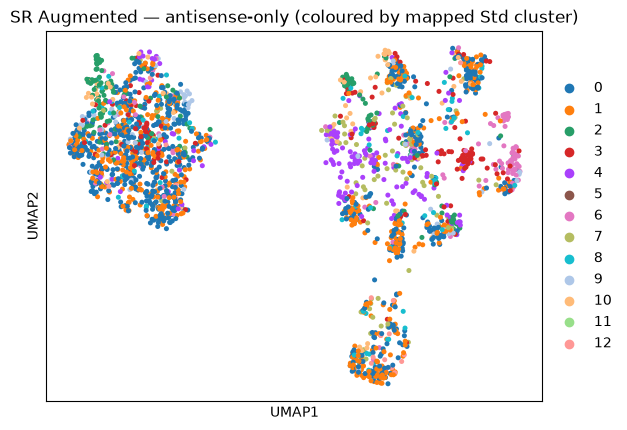

SR Aug intergenic-only: 26 sub-clusters calculated.


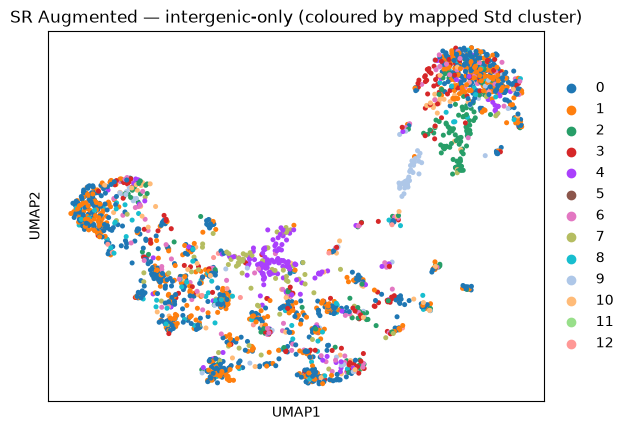

Skipping 'SR Aug intronic-only': contains 0 features.
SR Dis antisense-only: 20 sub-clusters calculated.


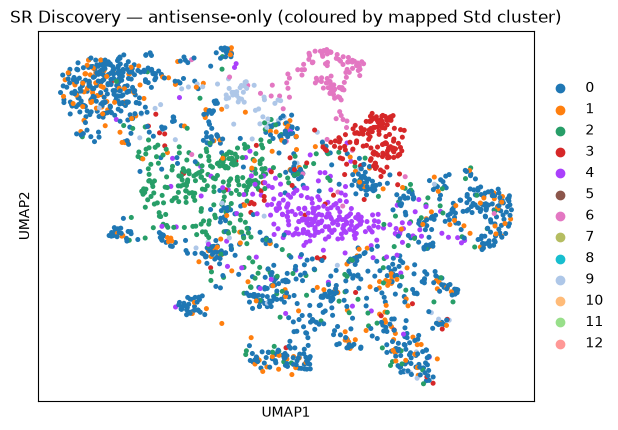

SR Dis intergenic-only: 23 sub-clusters calculated.


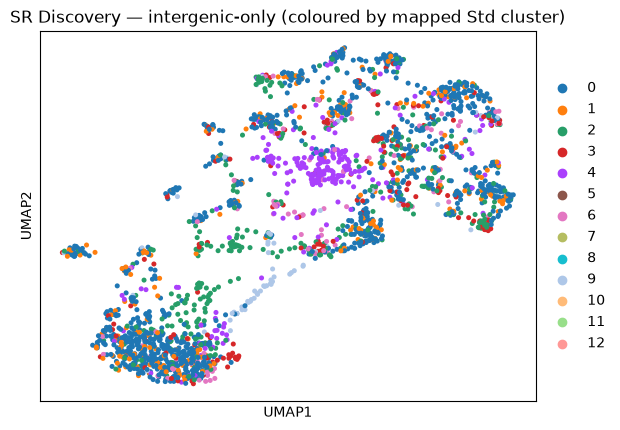

In [45]:
import numpy as np
import pandas as pd
import scanpy as sc

def subset_by_class(adata_raw, classes):
    """Subsets an AnnData object based on parsed classes from variable names."""
    parsed_classes = [parse_discovery_id(v)[1] for v in adata_raw.var_names]
    mask = np.isin(parsed_classes, list(classes))
    return adata_raw[:, mask].copy()


subset_configs = {
    "SR Aug antisense-only": ("SR_Aug", {"antisense_exonic", "antisense_intronic"}),
    "SR Aug intergenic-only": ("SR_Aug", {"intergenic"}),
    "SR Aug intronic-only": ("SR_Aug", {"known_gene_intronic"}),
    "SR Dis antisense-only": ("SR_Dis", {"antisense_exonic", "antisense_intronic"}),
    "SR Dis intergenic-only": ("SR_Dis", {"intergenic"}),
}

shared_categories = sorted(df_congruence['Std'].astype(str).unique(), key=int)

subsets = {}
for label, (dataset_key, classes) in subset_configs.items():
    adata_sub = subset_by_class(adatas_raw[dataset_key], classes)
    
    
    parent_obs = adatas[dataset_key].obs
    if 'std_mapped_cluster' in parent_obs.columns:
        adata_sub.obs['std_mapped_cluster'] = parent_obs.loc[adata_sub.obs_names, 'std_mapped_cluster']
        
        adata_sub.obs['std_mapped_cluster'] = pd.Categorical(
            adata_sub.obs['std_mapped_cluster'].astype(str), 
            categories=shared_categories
        )
        
        if 'std_mapped_cluster_colors' in adatas[dataset_key].uns:
            adata_sub.uns['std_mapped_cluster_colors'] = adatas[dataset_key].uns['std_mapped_cluster_colors']
            
    subsets[label] = adata_sub
    print(f"{label}: {adata_sub.n_vars:,} features synced.")

def cluster_subset(adata, resolution=1.0, label=""):
    """Runs standard Scanpy clustering and embedding pipeline on a subset."""
    if adata.n_vars == 0:
        print(f"Skipping '{label}': contains 0 features.")
        return None

    a = adata.copy()
    a.layers['counts'] = a.X.copy()

    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)

    n_top = min(2000, a.n_vars)
    n_comps = min(30, a.n_vars - 1, a.n_obs - 1)

    if n_comps < 1:
        print(f"Skipping '{label}': not enough features/cells for PCA.")
        return None

    sc.pp.highly_variable_genes(a, n_top_genes=n_top, flavor='seurat')
    sc.tl.pca(a, svd_solver='arpack', random_state=42, n_comps=n_comps)
    sc.pp.neighbors(a, n_neighbors=15, n_pcs=min(30, n_comps), random_state=42)
    sc.tl.umap(a, random_state=42)

    sc.tl.leiden(a, resolution=resolution, key_added='leiden', random_state=42)
    print(f"{label}: {a.obs['leiden'].nunique()} sub-clusters calculated.")

    return a

for label, adata_subset in subsets.items():
    clustered_adata = cluster_subset(adata_subset, resolution=1.0, label=label)

    if clustered_adata is not None:
        display_title = label.replace("SR Aug", "SR Augmented —").replace("SR Dis", "SR Discovery —")
        if "known_gene_intronic" in label:
            display_title += " (known_gene_intronic)"
            
        sc.pl.umap(
            clustered_adata, 
            color='std_mapped_cluster', 
            title=f"{display_title} (coloured by mapped Std cluster)"
        )
        



SR Augmented — intergenic-only: 14,930 features synced.
SR Augmented — intergenic-only: 26 sub-clusters calculated.


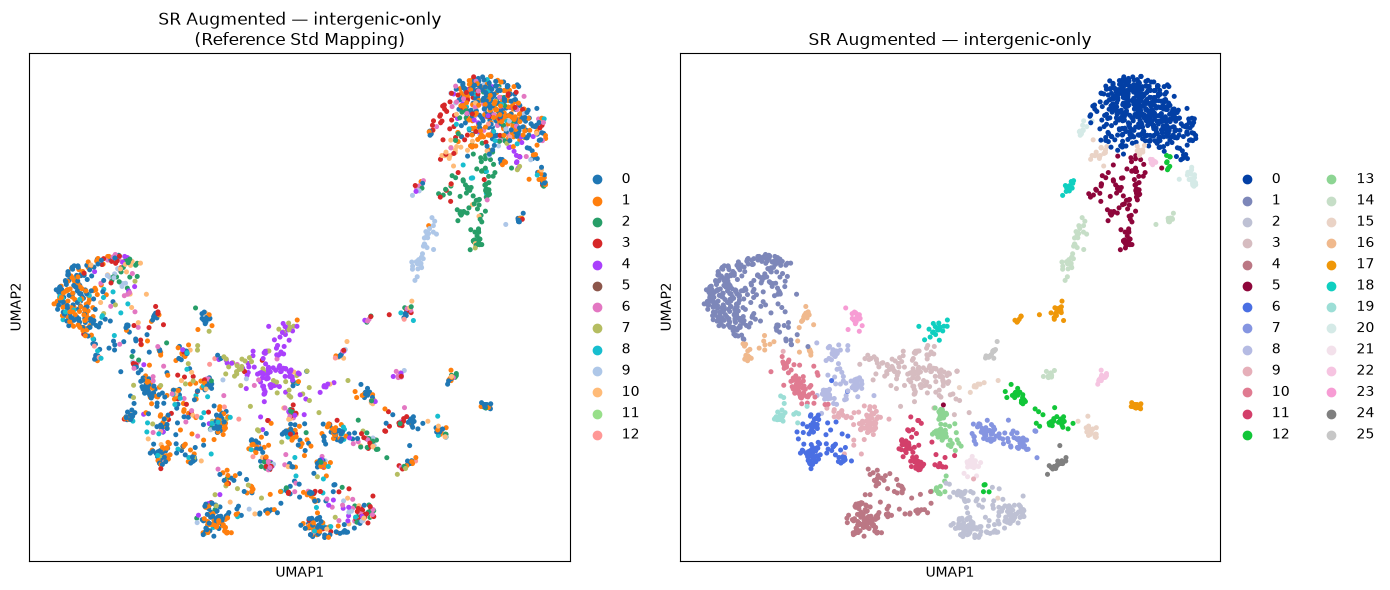

In [46]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

def subset_by_class(adata_raw, classes):
    """Subsets an AnnData object based on parsed classes from variable names."""
    parsed_classes = [parse_discovery_id(v)[1] for v in adata_raw.var_names]
    mask = np.isin(parsed_classes, list(classes))
    return adata_raw[:, mask].copy()

dataset_key = "SR_Aug" 
target_classes = {"intergenic"}
display_title = "SR Augmented — intergenic-only"

shared_categories = sorted(df_congruence['Std'].astype(str).unique(), key=int)

adata_sub = subset_by_class(adatas_raw[dataset_key], target_classes)

parent_obs = adatas[dataset_key].obs
if 'std_mapped_cluster' in parent_obs.columns:
    adata_sub.obs['std_mapped_cluster'] = parent_obs.loc[adata_sub.obs_names, 'std_mapped_cluster']
    adata_sub.obs['std_mapped_cluster'] = pd.Categorical(
        adata_sub.obs['std_mapped_cluster'].astype(str), 
        categories=shared_categories
    )
    
    if 'std_mapped_cluster_colors' in adatas[dataset_key].uns:
        adata_sub.uns['std_mapped_cluster_colors'] = adatas[dataset_key].uns['std_mapped_cluster_colors']

print(f"{display_title}: {adata_sub.n_vars:,} features synced.")

def cluster_subset(adata, resolution=1.0, label=""):
    """Runs standard Scanpy clustering and embedding pipeline on a subset."""
    if adata.n_vars == 0:
        print(f"Skipping '{label}': contains 0 features.")
        return None

    a = adata.copy()
    a.layers['counts'] = a.X.copy()

    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)

    n_top = min(2000, a.n_vars)
    n_comps = min(30, a.n_vars - 1, a.n_obs - 1)

    if n_comps < 1:
        print(f"Skipping '{label}': not enough features/cells for PCA.")
        return None

    sc.pp.highly_variable_genes(a, n_top_genes=n_top, flavor='seurat')
    sc.tl.pca(a, svd_solver='arpack', random_state=42, n_comps=n_comps)
    sc.pp.neighbors(a, n_neighbors=15, n_pcs=min(30, n_comps), random_state=42)
    sc.tl.umap(a, random_state=42)

    # Calculate local subset-specific clusters
    sc.tl.leiden(a, resolution=resolution, key_added='leiden', random_state=42)
    print(f"{label}: {a.obs['leiden'].nunique()} sub-clusters calculated.")

    return a

clustered_adata = cluster_subset(adata_sub, resolution=1.0, label=display_title)

if clustered_adata is not None:
    # Create side-by-side plot layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    sc.pl.umap(
        clustered_adata, 
        color='std_mapped_cluster', 
        title=f"{display_title}\n(Reference Std Mapping)",
        ax=axes[0],
        show=False
    )
    
    sc.pl.umap(
        clustered_adata, 
        color='leiden', 
        title=f"{display_title}",
        ax=axes[1],
        show=False
    )
    
    plt.tight_layout()
    plt.show()


SR Augmented — intergenic-only: 14,930 features synced.
SR Augmented — intergenic-only: 17 sub-clusters calculated.


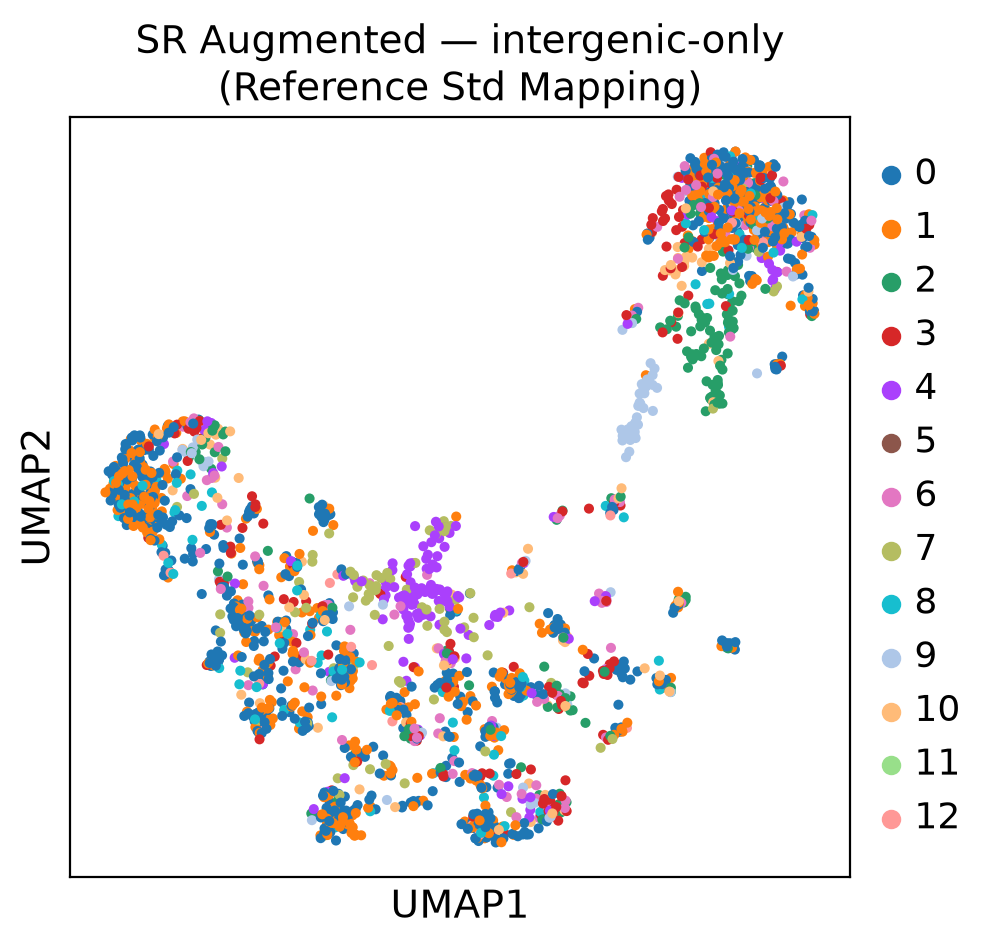

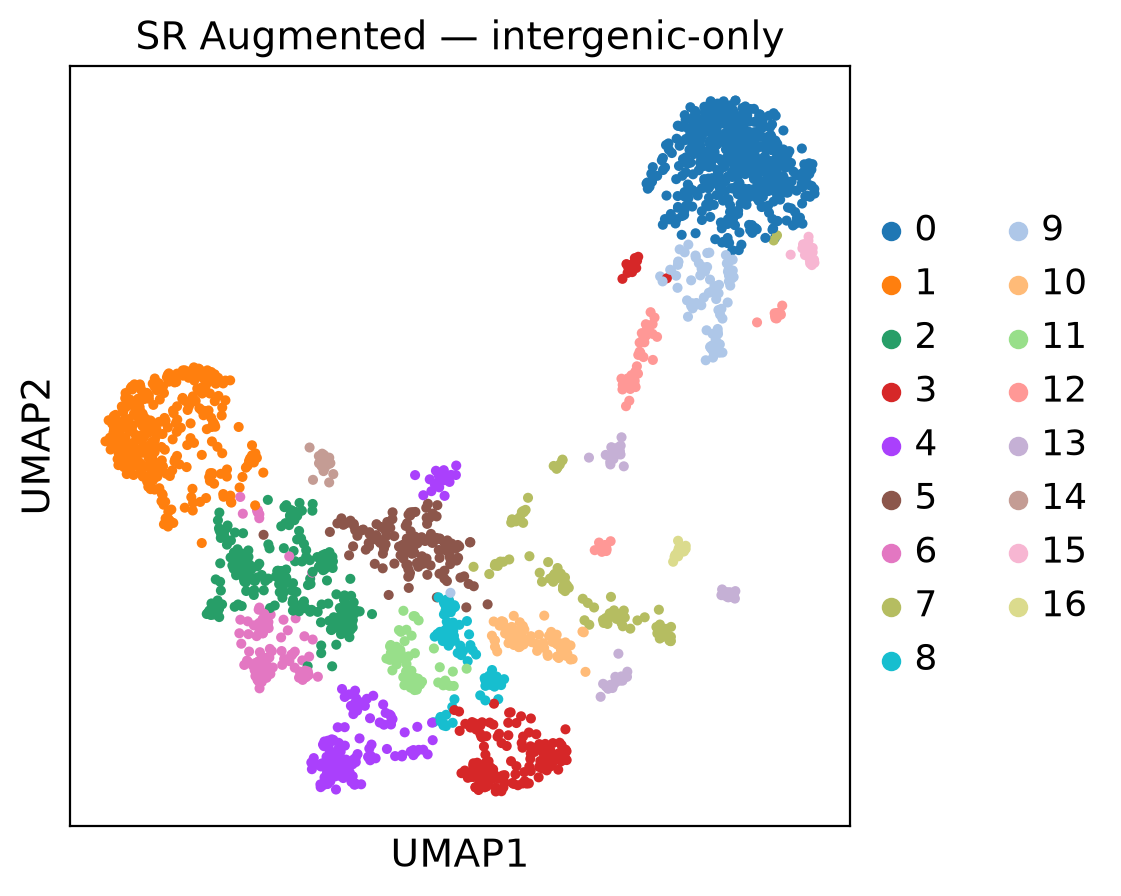

In [54]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.set_figure_params(figsize=(5, 5), frameon=True, dpi=100)

def subset_by_class(adata_raw, classes):
    """Subsets an AnnData object based on parsed classes from variable names."""
    # RESTORED: [1] indexing to extract the parsed class string from the tuple
    parsed_classes = [parse_discovery_id(v)[1] for v in adata_raw.var_names]
    mask = np.isin(parsed_classes, list(classes))
    return adata_raw[:, mask].copy()


dataset_key = "SR_Aug" 
target_classes = {"intergenic"}
display_title = "SR Augmented — intergenic-only"

shared_categories = sorted(df_congruence['Std'].astype(str).unique(), key=int)


adata_sub = subset_by_class(adatas_raw[dataset_key], target_classes)

parent_obs = adatas[dataset_key].obs
if 'std_mapped_cluster' in parent_obs.columns:
    adata_sub.obs['std_mapped_cluster'] = parent_obs.loc[adata_sub.obs_names, 'std_mapped_cluster']
    adata_sub.obs['std_mapped_cluster'] = pd.Categorical(
        adata_sub.obs['std_mapped_cluster'].astype(str), 
        categories=shared_categories
    )
    
  
    if 'std_mapped_cluster_colors' in adatas[dataset_key].uns:
        adata_sub.uns['std_mapped_cluster_colors'] = adatas[dataset_key].uns['std_mapped_cluster_colors']

print(f"{display_title}: {adata_sub.n_vars:,} features synced.")


def cluster_subset(adata, resolution=1.0, label=""):
    """Runs standard Scanpy clustering and embedding pipeline on a subset."""
    if adata.n_vars == 0:
        print(f"Skipping '{label}': contains 0 features.")
        return None

    a = adata.copy()
    a.layers['counts'] = a.X.copy()

    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)

    n_top = min(2000, a.n_vars)
    n_comps = min(30, a.n_vars - 1, a.n_obs - 1)

    if n_comps < 1:
        print(f"Skipping '{label}': not enough features/cells for PCA.")
        return None

    sc.pp.highly_variable_genes(a, n_top_genes=n_top, flavor='seurat')
    sc.tl.pca(a, svd_solver='arpack', random_state=42, n_comps=n_comps)
    sc.pp.neighbors(a, n_neighbors=15, n_pcs=min(30, n_comps), random_state=42)
    sc.tl.umap(a, random_state=42)

    
    sc.tl.leiden(a, resolution=resolution, key_added='leiden', random_state=42)
    print(f"{label}: {a.obs['leiden'].nunique()} sub-clusters calculated.")

    return a


clustered_adata = cluster_subset(adata_sub, resolution=0.5, label=display_title)

if clustered_adata is not None:
    
    sc.pl.umap(
        clustered_adata, 
        color='std_mapped_cluster', 
        title=f"{display_title}\n(Reference Std Mapping)",
        show=True
    )
    
    
    sc.pl.umap(
        clustered_adata, 
        color='leiden', 
        title=f"{display_title}",
        show=True
    )


... storing 'Highlight_Target' as categorical


Confirmed: Keyword 'peak_312805' not found in SR dataset. Creating control negative map.


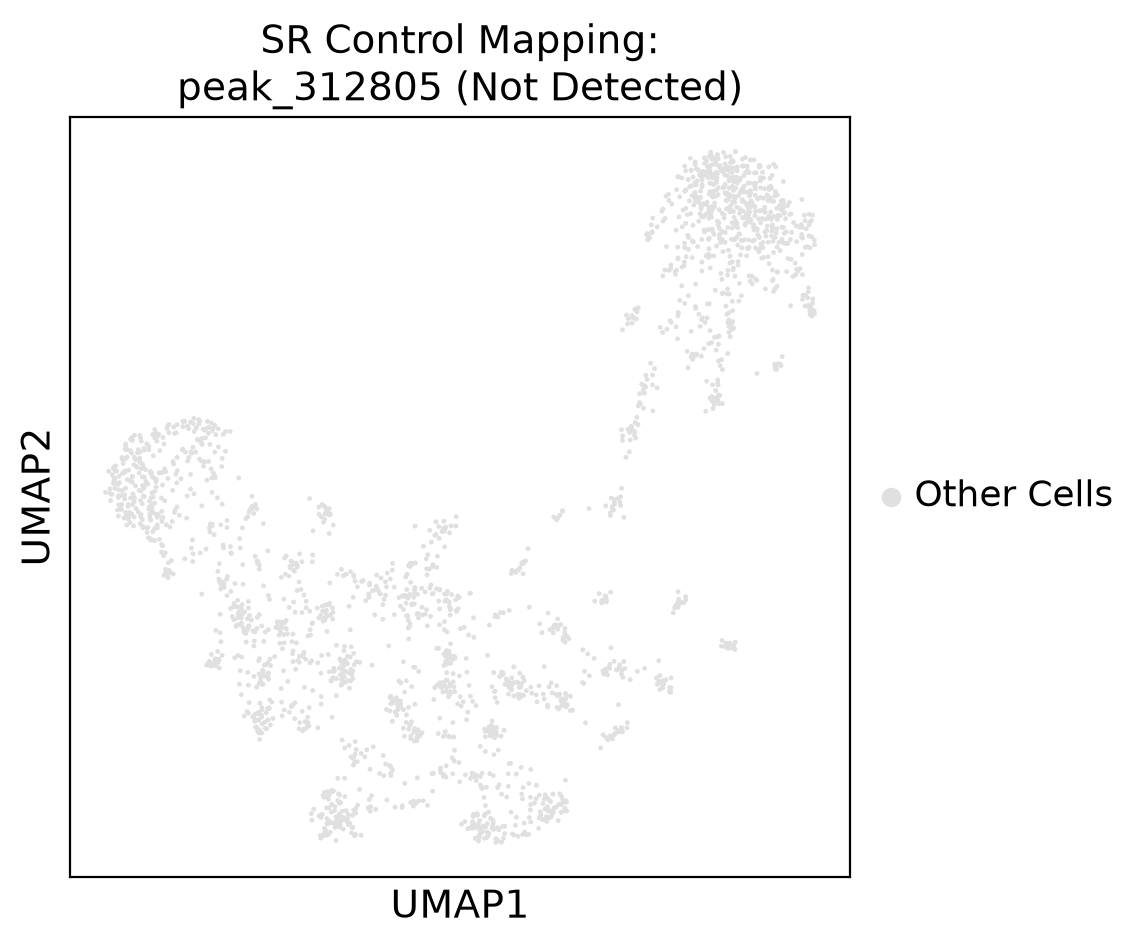

In [55]:

search_keyword = 'peak_312805'


matching_features = [v for v in clustered_adata.var_names if search_keyword in str(v)]

if len(matching_features) > 0:
    target_peak = matching_features[0]
    print(f"Unexpected Find: Found exact match in SR data: '{target_peak}'")
    
    # Extract data matrix values safely
    expression_values = clustered_adata[:, target_peak].X
    if hasattr(expression_values, "toarray"):
        expression_values = expression_values.toarray().flatten()
    else:
        expression_values = np.asarray(expression_values).flatten()
        
    clustered_adata.obs['Highlight_Target'] = np.where(
        expression_values > 0, 
        'Expressing Cells', 
        'Other Cells'
    )
else:
    
    print(f"Confirmed: Keyword '{search_keyword}' not found in SR dataset. Creating control negative map.")
    clustered_adata.obs['Highlight_Target'] = 'Other Cells'


sc.pl.umap(
    clustered_adata,
    color='Highlight_Target',
    title=f'SR Control Mapping:\n{search_keyword} (Not Detected)',
    palette={'Other Cells': '#e0e0e0', 'Expressing Cells': '#e60000'},
    size=12,
    show=True
)
